<a href="https://colab.research.google.com/github/Jeshurun-B/EMA-optimizer-pipeline-v2/blob/main/coolab_notebooks/week3_feature_engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📅 Week 3 — Feature Engineering + Rigorous Model Evaluation
**EMA Crossover ML Project | 10-Week Curriculum**
**Date:** June 21, 2026

---

### What This Week Is About

Week 2 proved that Logistic Regression can separate good signals from bad ones — you built a full classification pipeline, tuned thresholds using Youden's J, explored regularisation, and constructed logical ensembles of specialist classifiers. But your validation was simple: an 80/20 chronological split. This week you fix that permanently by building the **walk-forward cross-validation framework** that every future model will use. You will also engineer new features — interactions, ratios, domain-specific constructs, and lag features — that give non-linear models the raw material they need to beat logistic regression in Weeks 4–7. This is the infrastructure week: the engineering and evaluation machinery you build here will compound in value every week that follows.

**By end of week you will have:**
- A reusable `walk_forward_cv()` function that every future model uses (no exceptions)
- 15+ interaction and ratio features engineered from your existing 35
- 10+ domain-specific features derived from the analytics table
- A justified final feature set of 20–30 columns with selection rationale
- A retrained Logistic Regression baseline on the engineered feature set (your new benchmark)


## Section 0 — Environment Setup

Run this first every session. Added `statsmodels` this week for VIF calculations.

In [3]:
# Install required libraries (added statsmodels for VIF)
!pip install -q supabase scikit-learn statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 kB 3.7 MB/s eta 0:00:00


In [4]:
# ============================================================
# IMPORTS
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from supabase import create_client
from google.colab import userdata

# sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix,
    precision_recall_curve, average_precision_score
)
from sklearn.model_selection import TimeSeriesSplit
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import RFE

# statsmodels for VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

print('Environment ready ✓')


Environment ready ✓


## Section 1 — Connect to Both Databases

Same dual-connection pattern. Copy-paste from Week 2. Do not change it.

In [5]:
# ============================================================
# CONNECT TO MAIN DATABASE
# ============================================================
try:
    main_client = create_client(userdata.get('SUPABASE_URL'), userdata.get('SUPABASE_KEY'))
    print('Main database connected ✓')
except Exception as e:
    print(f'Main connection failed: {e}')


Main database connected ✓


In [55]:
# ============================================================
# CONNECT TO MAIN DATABASE
# ============================================================
try:
    main_client_all = create_client(userdata.get('SUPABASE_URL'), userdata.get('SUPABASE_KEY'))
    print('Main database connected ✓')
except Exception as e:
    print(f'Main connection failed: {e}')


Main database connected ✓


In [6]:
# ============================================================
# CONNECT TO ANALYTICS DATABASE
# ============================================================
try:
    analytics_client = create_client(
        userdata.get('ANALYTICS_SUPABASE_URL'),
        userdata.get('ANALYTICS_SUPABASE_KEY')
    )
    print('Analytics database connected ✓')
except Exception as e:
    print(f'Analytics connection failed: {e}')


Analytics database connected ✓


In [56]:
# ============================================================
# CONNECT TO ANALYTICS DATABASE
# ============================================================
try:
    analytics_client_all = create_client(
        userdata.get('ANALYTICS_SUPABASE_URL'),
        userdata.get('ANALYTICS_SUPABASE_KEY')
    )
    print('Analytics database connected ✓')
except Exception as e:
    print(f'Analytics connection failed: {e}')


Analytics database connected ✓


## Section 2 — Fetch Data and Merge

Same merge pattern from Weeks 1–2. Inner join on `(symbol, checked_at_utc)`.

In [7]:
# ============================================================
# FETCH: Main signals table
# ============================================================
response_main = main_client.table('signals').select('*').eq('status', 'analyzed').execute()
df_main = pd.DataFrame(response_main.data)

for col in ['checked_at_utc', 'time_of_max_price', 'time_of_min_price']:
    if col in df_main.columns:
        df_main[col] = pd.to_datetime(df_main[col], utc=True, errors='coerce')

df_main = df_main.sort_values('checked_at_utc').reset_index(drop=True)
print(f'Main signals: {len(df_main):,} rows | {df_main.shape[1]} columns')
print(f'Range: {df_main["checked_at_utc"].min().date()} to {df_main["checked_at_utc"].max().date()}')
print(f'Signal split: {df_main["signal"].value_counts().to_dict()}')


Main signals: 10,000 rows | 48 columns
Range: 2019-08-23 to 2026-06-25
Signal split: {'SHORT': 5006, 'LONG': 4994}


In [58]:
# ============================================================
# FETCH: Main signals table
# ============================================================
response_main = main_client_all.table('signals').select('*').eq('status', 'analyzed').execute()
df_main = pd.DataFrame(response_main.data)

for col in ['checked_at_utc', 'time_of_max_price', 'time_of_min_price']:
    if col in df_main.columns:
        df_main[col] = pd.to_datetime(df_main[col], utc=True, errors='coerce')

df_main_all = df_main.sort_values('checked_at_utc').reset_index(drop=True)
print(f'Main signals: {len(df_main):,} rows | {df_main.shape[1]} columns')
print(f'Range: {df_main["checked_at_utc"].min().date()} to {df_main["checked_at_utc"].max().date()}')
print(f'Signal split: {df_main["signal"].value_counts().to_dict()}')

Main signals: 50,000 rows | 48 columns
Range: 2019-08-23 to 2026-06-27
Signal split: {'SHORT': 25003, 'LONG': 24997}


In [8]:
# ============================================================
# FETCH: Analytics table
# ============================================================
response_analytics = analytics_client.table('crossover_analytics').select('*').execute()
df_analytics = pd.DataFrame(response_analytics.data)

for col in ['crossover_utc', 'next_crossover_utc', 'optimal_entry_utc']:
    if col in df_analytics.columns:
        df_analytics[col] = pd.to_datetime(df_analytics[col], utc=True, errors='coerce')

df_analytics = df_analytics.sort_values('crossover_utc').reset_index(drop=True)
print(f'Analytics: {len(df_analytics):,} rows | {df_analytics.shape[1]} columns')


Analytics: 10,000 rows | 14 columns


In [63]:
# ============================================================
# FETCH: Analytics table
# ============================================================
response_analytics = analytics_client_all.table('crossover_analytics').select('*').execute()
df_analytics_all = pd.DataFrame(response_analytics.data)

for col in ['crossover_utc', 'next_crossover_utc', 'optimal_entry_utc']:
    if col in df_analytics_all.columns:
        df_analytics_all[col] = pd.to_datetime(df_analytics_all[col], utc=True, errors='coerce')

df_analytics_all = df_analytics_all.sort_values('crossover_utc').reset_index(drop=True)
print(f'Analytics: {len(df_analytics_all):,} rows | {df_analytics_all.shape[1]} columns')


Analytics: 50,000 rows | 14 columns


In [64]:
# ============================================================
# MERGE: inner join on (symbol, checked_at_utc)
# ============================================================
df_analytics_renamed = df_analytics.rename(columns={'crossover_utc': 'checked_at_utc'})
df = pd.merge(df_main, df_analytics_renamed, how='inner', on=['checked_at_utc', 'symbol'])

main_lost      = len(df_main) - len(df)
analytics_lost = len(df_analytics) - len(df)

print(f'Merged dataset: {len(df):,} rows | {df.shape[1]} columns')
print(f'Lost from main  (no analytics match): {main_lost:,} ({main_lost/len(df_main)*100:.1f}%)')
print(f'Lost from analytics (no main match): {analytics_lost:,}')
print()
print('Records per symbol:')
print(df['symbol'].value_counts())


Merged dataset: 9,521 rows | 60 columns
Lost from main  (no analytics match): 40,479 (81.0%)
Lost from analytics (no main match): 479

Records per symbol:
symbol
BTCUSDT     3718
XRPUSDT     1490
SOLUSDT     1476
ETHUSDT     1467
DOGEUSDT    1370
Name: count, dtype: int64


In [82]:
# ============================================================
# MERGE: inner join on (symbol, checked_at_utc)
# ============================================================
df_analytics_renamed_all = df_analytics_all.rename(columns={'crossover_utc': 'checked_at_utc'})
df_all = pd.merge(df_main_all, df_analytics_renamed_all, how='inner', on=['checked_at_utc', 'symbol'])

main_lost      = len(df_main_all) - len(df_all)
analytics_lost = len(df_analytics_all) - len(df_all)

print(f'Merged dataset: {len(df_all):,} rows | {df_all.shape[1]} columns')
print(f'Lost from main  (no analytics match): {main_lost:,} ({main_lost/len(df_main_all)*100:.1f}%)')
print(f'Lost from analytics (no main match): {analytics_lost:,}')
print()
print('Records per symbol:')
print(df_all['symbol'].value_counts())


Merged dataset: 45,556 rows | 60 columns
Lost from main  (no analytics match): 4,444 (8.9%)
Lost from analytics (no main match): 4,444

Records per symbol:
symbol
BTCUSDT     13835
SOLUSDT     11066
ETHUSDT      9760
XRPUSDT      9525
DOGEUSDT     1370
Name: count, dtype: int64


## Section 3 — Apply Signal Quality Columns

Locked scoring module from Week 1. Applied every week after merge. Do not modify.

In [10]:
# ============================================================
# SIGNAL QUALITY SCORING MODULE (Week 1 final version — DO NOT MODIFY)
# ============================================================

def get_time_decay_score(candles):
    if candles <= 20:
        return 1.0
    elif candles <= 100:
        t = (candles - 20) / 80
        return np.exp(-3.5 * t)
    elif candles <= 400:
        base = np.exp(-3.5)
        t = (candles - 100) / 300
        return base * np.exp(-4 * t)
    else:
        return 0.0

def time_cutoff(candles):
    if candles <= 20:   return 1.0
    elif candles <= 40: return 0.5
    else:               return 0

def calculate_four_target_scores(row):
    is_long = str(row['signal_x']).upper() == 'LONG'
    if is_long:
        p, r = float(row['max_move_up_pct']), float(row['max_move_down_pct'])
        candles_to_peak_profit = int(row['candles_to_max_price'])
        candles_to_max_pain    = int(row['candles_to_min_price'])
        is_btc  = bool(row['btc_trend_bias'])
        is_1d   = bool(row['htf_1d_bias'])
        is_4h   = bool(row['htf_4h_bias'])
    else:
        p, r = float(row['max_move_down_pct']), float(row['max_move_up_pct'])
        candles_to_peak_profit = int(row['candles_to_min_price'])
        candles_to_max_pain    = int(row['candles_to_max_price'])
        is_btc  = not bool(row['btc_trend_bias'])
        is_1d   = not bool(row['htf_1d_bias'])
        is_4h   = not bool(row['htf_4h_bias'])

    r_safe      = 0.01 if r <= 0 else r
    current_rr  = p / r_safe
    t_factor    = get_time_decay_score(candles_to_peak_profit)
    base        = round(min(5.0, current_rr) + 5.0 * t_factor, 2)

    t1 = base

    if candles_to_max_pain < candles_to_peak_profit and r >= p:
        t2 = round(base * 0.2, 2)
    elif r < 0.25:
        t2 = round(base * 0.1, 2)
    else:
        t2 = base

    pen = base
    if 'volume_ratio' in row and float(row['volume_ratio']) < 1.0: pen -= 0.8
    if not is_btc:  pen -= 0.5
    if not is_1d:   pen -= 1.0
    if not is_4h:   pen -= 1.2
    if candles_to_max_pain < candles_to_peak_profit and r > 0.75 * p: pen -= 0.8
    t3 = round(max(0, pen), 2)

    if r < 0.25 or (candles_to_max_pain < candles_to_peak_profit and r >= p):
        t4 = 0.0
    else:
        if current_rr >= 4:              rr_p = 5.0
        elif current_rr >= 1.5:          rr_p = current_rr
        elif 1.0 <= current_rr < 1.5:   rr_p = (current_rr**7) / (1.5**6)
        else:                             rr_p = 0.0
        t_s = time_cutoff(candles_to_peak_profit)
        t4  = round(5.0 * t_s + rr_p, 2) if rr_p > 0 else 0.0

    return t1, t2, t3, t4


def optimal_entry_candles(row):
    """Returns 15-min candles from crossover to optimal entry. 0 = immediate entry."""
    try:
        if pd.isnull(row['optimal_entry_utc']) or pd.isnull(row['checked_at_utc']):
            return 0.0
        diff = row['optimal_entry_utc'] - row['checked_at_utc']
        return float(diff.total_seconds() / 60 / 15)
    except Exception:
        return 0.0


# Apply
target_cols = ['T1_Pure_Continuous', 'T2_Soft_Floor', 'T3_Assumption_Penalty', 'T4_Control_Punished']
df[target_cols] = df.apply(lambda r: pd.Series(calculate_four_target_scores(r)), axis=1)
df['target_special'] = df[target_cols[:3]].min(axis=1)
df['Optimum_entry']  = df.apply(optimal_entry_candles, axis=1)

print('All quality columns applied ✓')
print('\n--- % scoring above 5.0 ---')
for col in target_cols + ['target_special']:
    print(f'  {col:<28} -> {(df[col] > 5).mean()*100:.1f}%')
print(f'\n  Optimum_entry median: {df["Optimum_entry"].median():.1f} candles | mean: {df["Optimum_entry"].mean():.1f}')


All quality columns applied ✓

--- % scoring above 5.0 ---
  T1_Pure_Continuous           -> 98.6%
  T2_Soft_Floor                -> 78.3%
  T3_Assumption_Penalty        -> 36.6%
  T4_Control_Punished          -> 28.7%
  target_special               -> 26.9%

  Optimum_entry median: 0.0 candles | mean: 1.0


## Section 4 — Carry Forward From Week 2

Re-establish your binary target definition and Week 2 feature sets before building anything new. Your Week 2 chosen target is the reference point for measuring whether new features help.

In [11]:
# ============================================================
# FEATURE SET DEFINITIONS (Week 2 final versions)
# ============================================================

FEATURES_ALL = [
    'ema_fast_ltf', 'ema_slow_ltf', 'ema_fast_slope', 'ema_slow_slope',
    'ema_separation', 'price_above_both_emas', 'crossover_candle_strength',
    'adx_ltf', 'adx_slope', 'adx_4h', 'macd_histogram_ltf', 'macd_histogram_4h',
    'htf_4h_bias', 'htf_1d_bias', 'ema_separation_4h', 'rsi_4h',
    'rsi_ltf', 'roc_ltf', 'atr_ltf', 'atr_pct', 'bb_width_ltf', 'price_to_atr',
    'volume_ratio', 'volume_trend', 'crossover_volume_ratio',
    'fear_greed_index', 'btc_trend_bias', 'hour_of_day', 'day_of_week',
    'swing_high', 'swing_low', 'atr_stop_distance', 'signal_gap_hours'
]

FEATURES_LONG_MI = [
    'volume_ratio', 'btc_trend_bias', 'rsi_4h', 'htf_4h_bias',
    'ema_separation_4h', 'ema_fast_slope', 'ema_slow_slope', 'price_to_atr',
    'atr_pct', 'bb_width_ltf', 'volume_trend', 'htf_1d_bias',
    'atr_ltf', 'macd_histogram_ltf', 'rsi_ltf'
]

FEATURES_SHORT_MI = [
    'rsi_4h', 'htf_4h_bias', 'ema_separation_4h', 'btc_trend_bias',
    'ema_fast_slope', 'ema_slow_slope', 'atr_pct', 'htf_1d_bias',
    'price_to_atr', 'crossover_volume_ratio', 'volume_ratio', 'roc_ltf',
    'bb_width_ltf', 'atr_stop_distance', 'atr_ltf'
]

# ============================================================
# BINARY TARGET: Carry forward your Week 2 chosen definition
# ============================================================
# TODO: Re-apply whichever binary target definition you settled on in Week 2.
#       Paste it here so the baseline comparison cell in Section 10 can use it.
#       Label it: df['binary_target'] = ...

THRESHOLD_T3  = 5.3   # TODO: update to your Week 2 final threshold
THRESHOLD_MFE = 0.5   # TODO: update to your Week 2 final mfe threshold

# TODO: reconstruct df['binary_target'] using the same logic as Week 2

print(f'FEATURES_ALL:      {len(FEATURES_ALL)} features')
print(f'FEATURES_LONG_MI:  {len(FEATURES_LONG_MI)} features')
print(f'FEATURES_SHORT_MI: {len(FEATURES_SHORT_MI)} features')
# TODO: print class balance for binary_target (LONG and SHORT separately)


FEATURES_ALL:      33 features
FEATURES_LONG_MI:  15 features
FEATURES_SHORT_MI: 15 features


##################################
important


i noticed a few issues with my original target and classification target and as such i will be changing it down below

In [85]:

# ============================================================
# CALCULATE METRICS CLEANLY FOR EACH DATAFRAME ISOLATED
# ============================================================

# --- 1. Compute for local execution dataframe (df) ---
mae_df = df['mae_percent'].abs()
mfe_df = df['mfe_percent'].abs()

# Safely compute non-linear efficiency scale (add 1e-8 to prevent division by zero)
df['target_b'] = (mfe_df / (mfe_df + mae_df + 1e-8)) * (mfe_df - mae_df)

df['class_target_1'] = (df['target_b'] > 0.4).astype(int)
df['class_target_2'] = (df['mfe_percent'] > 1).astype(int)


# --- 2. Compute separately for parent dataframe (df_all) ---
mae_all = df_all['mae_percent'].abs()
mfe_all = df_all['mfe_percent'].abs()

# Safely compute non-linear efficiency scale for df_all
df_all['target_b'] = (mfe_all / (mfe_all + mae_all + 1e-8)) * (mfe_all - mae_all)

df_all['class_target_1'] = (df_all['target_b'] > 0.4).astype(int)
df_all['class_target_2'] = (df_all['mfe_percent'] > 1).astype(int)

# Ready for plotting
plt.figure(figsize=(24, 7))

<Figure size 2400x700 with 0 Axes>

<Figure size 2400x700 with 0 Axes>

In [86]:
df_all.tail(50)

,id_x,checked_at_utc,symbol,signal_x,price,signal_gap_hours,prev_signal,ema_fast_ltf,ema_slow_ltf,ema_fast_slope,ema_slow_slope,ema_separation,price_above_both_emas,crossover_candle_strength,adx_ltf,adx_slope,adx_4h,macd_histogram_ltf,macd_histogram_4h,htf_4h_bias,htf_1d_bias,ema_separation_4h,rsi_4h,rsi_ltf,roc_ltf,atr_ltf,atr_pct,bb_width_ltf,price_to_atr,volume_ratio,volume_trend,crossover_volume_ratio,fear_greed_index,btc_trend_bias,hour_of_day,day_of_week,swing_high,swing_low,atr_stop_distance,max_price_after,min_price_after,max_move_up_pct,max_move_down_pct,time_of_max_price,time_of_min_price,candles_to_max_price,candles_to_min_price,status,id_y,signal_y,entry_price,optimal_entry,optimal_entry_utc,mfe_percent,mae_percent,trade_duration,next_crossover_utc,exit_price,pnl_percent,created_at,target_b,class_target_1,class_target_2
45506,55681,2026-06-23 15:15:00+00:00,ETHUSDT,SHORT,1654.02000,0.0,LONG,1658.919706,1659.356674,-0.0738,-0.0459,-0.0263,False,1.0000,31.73,-1.42,17.32,1.638603,-8.399722,False,False,-0.5942,34.09,39.91,0.0799,7.531116,0.4553,1.1256,219.62,0.7954,0.1052,0.7954,50,False,15,1,1672.00000,1645.52000,11.296673,1673.89000,1651.39000,1.2013,0.1590,2026-06-23 16:00:00+00:00,2026-06-23 15:45:00+00:00,3,2,analyzed,10818,SHORT,1654.02000,1660.92000,2026-06-23 15:30:00+00:00,0.16,-0.42,3,2026-06-23 16:00:00+00:00,1659.78000,-0.35,2026-06-24T06:08:17.010809+00:00,-0.071724,0,0
45507,55357,2026-06-23 15:15:00+00:00,BTCUSDT,SHORT,62277.09000,0.0,LONG,62418.351506,62431.370915,-0.0565,-0.0353,-0.0209,False,0.9999,35.03,-1.68,17.00,35.455550,-176.582191,False,False,-0.3407,35.52,41.38,0.1497,223.361216,0.3587,0.9769,278.82,0.9471,2.9760,0.9471,50,False,15,1,62855.98000,61960.00000,335.041824,62846.00000,62198.00000,0.9135,0.1270,2026-06-23 16:00:00+00:00,2026-06-23 15:15:00+00:00,3,0,analyzed,10797,SHORT,62277.09000,62382.00000,2026-06-23 15:15:00+00:00,0.13,-0.17,3,2026-06-23 16:00:00+00:00,62487.79000,-0.34,2026-06-24T06:08:13.72096+00:00,-0.017333,0,0
45508,55358,2026-06-23 16:00:00+00:00,BTCUSDT,LONG,62787.26000,0.0,SHORT,62488.094371,62469.455281,0.1198,0.0727,0.0298,True,0.1430,29.97,-1.10,17.75,54.320286,-201.154443,False,False,-0.4214,34.78,57.88,0.4982,240.599151,0.3832,1.0959,260.96,1.6726,6.8282,1.6726,50,False,16,1,62855.98000,62198.00000,360.898727,62846.00000,62274.00000,0.0936,0.8175,2026-06-23 16:00:00+00:00,2026-06-23 18:00:00+00:00,0,8,analyzed,10798,LONG,62787.26000,62428.01000,2026-06-23 16:00:00+00:00,0.09,-0.57,8,2026-06-23 18:00:00+00:00,62358.02000,-0.68,2026-06-24T06:08:13.827528+00:00,-0.065455,0,0
45509,55682,2026-06-23 16:00:00+00:00,ETHUSDT,LONG,1668.06000,0.0,SHORT,1660.516810,1660.173475,0.1137,0.0679,0.0207,True,0.1651,27.55,-0.67,18.66,1.924466,-8.937121,False,False,-0.6926,35.07,54.87,0.3145,8.218419,0.4927,1.1024,202.97,3.4813,17.8636,3.4813,50,False,16,1,1673.89000,1651.39000,12.327628,1673.89000,1654.67000,0.3495,0.8027,2026-06-23 16:00:00+00:00,2026-06-23 17:45:00+00:00,0,7,analyzed,10819,LONG,1668.06000,1656.99000,2026-06-23 16:00:00+00:00,0.35,-0.66,7,2026-06-23 17:45:00+00:00,1659.52000,-0.51,2026-06-24T06:08:17.116161+00:00,-0.107426,0,0
45510,55683,2026-06-23 17:45:00+00:00,ETHUSDT,SHORT,1656.85000,0.0,LONG,1659.774819,1659.952807,-0.0440,-0.0267,-0.0107,False,0.8276,20.73,-1.27,18.66,0.607856,-8.937121,False,False,-0.6926,35.07,44.57,0.0489,7.165156,0.4325,1.1010,231.24,0.3091,-3.4916,0.3091,50,False,17,1,1673.89000,1651.39000,10.747734,1663.97000,1650.00000,0.4297,0.4134,2026-06-23 19:45:00+00:00,2026-06-23 18:45:00+00:00,8,4,analyzed,10820,SHORT,1656.85000,1660.64000,2026-06-23 18:00:00+00:00,0.41,-0.23,8,2026-06-23 19:45:00+00:00,1658.21000,-0.08,2026-06-24T06:08:17.219561+00:00,0.115312,0,0
45511,55359,2026-06-23 18:00:00+00:00,BTCUSDT,SHORT,62372.00000,0.0,LONG,62476.376769,62482.647422,-0.0417,-0.0253,-0.0100,False,0.4908,20.30,-1.00,17.75,4.095321,-201.154443,False,False,-0.4214,34.78,45.36,-0.1853,215.681072,0.3458,1.0499,289.19,0.6589,-2.9961,0.6589,50,False,18,1,6

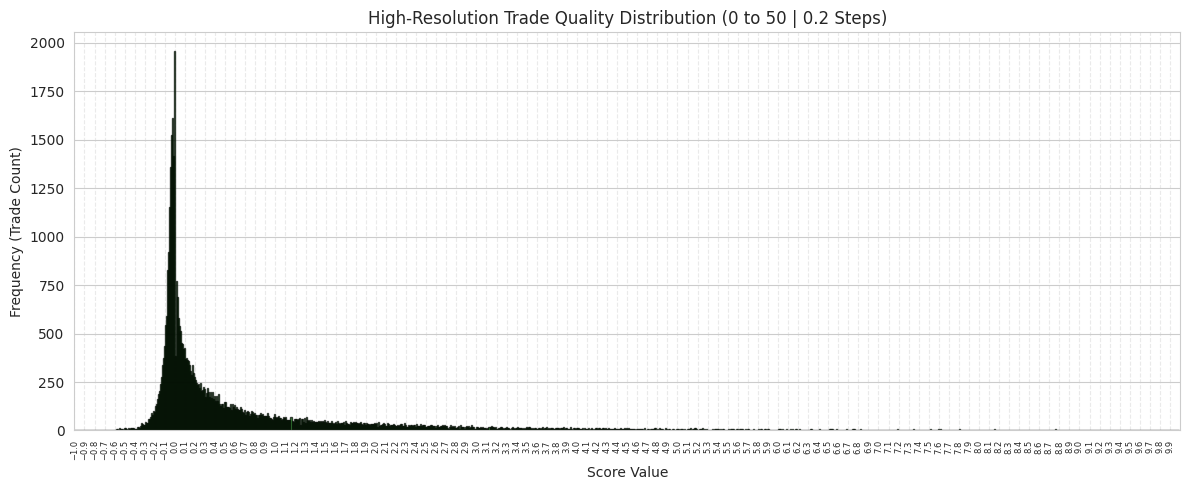

In [87]:
# 2. Filter data up to 25 based on your 99.9th percentile (21.66) to capture almost everything
#    while cutting out the rare max outlier (61.55) that would squash the chart.
plot_data = df_all['target_b'][(df_all['target_b'] >= -1) & (df_all['target_b'] <= 10)]

# 3. Match your bin width exactly to your tick intervals (0.2 steps)
#    We go up to 25.2 to ensure the final bin captures the edge values safely
bins_alignment = np.arange(-1, 10, 0.01)
plt.hist(plot_data, bins=bins_alignment, alpha=0.7, color='g', edgecolor='black')

# 4. Set the physical display limits of the X-axis right to 50
plt.xlim(-1, 10)

# 5. Generate matching tick positions from 0 to 50 stepping by 0.2
tick_positions = np.arange(-1, 10, 0.1)

# 6. Apply ticks with clean 90-degree rotation and a tiny font size for high-density readability
plt.xticks(tick_positions, rotation=90, fontsize=6)

plt.title('High-Resolution Trade Quality Distribution (0 to 50 | 0.2 Steps)')
plt.xlabel('Score Value')
plt.ylabel('Frequency (Trade Count)')

# Vertical grid lines help you look at a specific score bar and trace it down to its decimal value
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()



## Section 5 — Walk-Forward CV Framework (Monday)

### Why This Section Is the Most Important Thing You Build This Week

Your Week 2 evaluation used a single 80/20 train/test split. That gives you one data point — one AUC, one F1. You don't know whether that number is real or lucky. What you need is a distribution of scores across multiple time periods.

**Why standard k-fold is wrong for time series:**
Standard k-fold randomly shuffles the data before splitting into folds. For a time series, this means fold N might train on January candles and test on December candles, while *also* including December data in another training fold. The model learns from the future during training — this is **look-ahead leakage**. Your CV score becomes optimistically inflated, and you deploy a model that looked great in testing but has never actually seen unseen data.

`TimeSeriesSplit` enforces a strict rule: **the test fold is always chronologically after the training fold**. Fold 1 trains on the first 20% and tests on the next 20%. Fold 2 trains on the first 40% and tests on the next 20%. And so on. You never look forward.

**Gap parameter:** Consider adding a gap between the end of training and the start of testing. If a crossover signal at 23:45 influences one at 00:15 the next day, a gap of 2–3 periods prevents the boundary from leaking.

**Your job here:** Build a reusable `walk_forward_cv()` function that takes any model, X, y and returns a dictionary of mean ± std scores across all folds. Every model from Week 3 onward MUST be evaluated through this function — not a one-shot split.


In [14]:

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)

def walk_forward_cv(model, X, y, n_splits=5, gap=0):
    """
    Walk-forward time series cross-validation.

    Parameters
    ----------
    model   : sklearn-compatible estimator (must have fit, predict, predict_proba)
    X       : np.ndarray, feature matrix (already scaled if needed)
    y       : np.ndarray, binary target
    n_splits: int, number of CV folds (default 5)
    gap     : int, number of samples to skip between train and test
              (set > 0 if adjacent rows can leak information)

    Returns
    -------
    dict: {metric: (mean, std)} for accuracy, precision, recall, f1, auc
    """
    # 1. Instantiate TimeSeriesSplit with n_splits and gap parameters
    tscv = TimeSeriesSplit(n_splits=n_splits, gap=gap)

    scores = {
        'accuracy':  [],
        'precision': [],
        'recall':    [],
        'f1':        [],
        'auc':       [],
    }

    # 2. Loop over tscv.split(X)
    for train_idx, test_idx in tscv.split(X):
        # Slice train and test data
        X_tra, X_tes = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]

        scaler = StandardScaler()
        X_tr = scaler.fit_transform(X_tra)
        X_te = scaler.transform(X_tes)
        # ⚠️ Guardrail: Ensure both classes (0 and 1) exist in both training and testing slices.
        # If a fold only contains one class, metrics like precision/f1 can become undefined,
        # and roc_auc_score will completely crash with a ValueError.
        if len(np.unique(y_tr)) < 2 or len(np.unique(y_te)) < 2:
            continue
        scaler = StandardScaler()
        X_tr = scaler.fit_transform(X_tra)
        X_te = scaler.transform(X_tes)
        # Train the model
        model.fit(X_tr, y_tr)

        # Make predictions
        y_pred = model.predict(X_te)
        y_prob = model.predict_proba(X_te)[:, 1]

        # Calculate and append metrics
        scores['accuracy'].append(accuracy_score(y_te, y_pred))
        scores['precision'].append(precision_score(y_te, y_pred, zero_division=0))
        scores['recall'].append(recall_score(y_te, y_pred, zero_division=0))
        scores['f1'].append(f1_score(y_te, y_pred, zero_division=0))
        scores['auc'].append(roc_auc_score(y_te, y_prob))

    # 3. Calculate and return the mean and standard deviation for each metric
    return {k: (np.mean(v), np.std(v)) if v else (0.0, 0.0) for k, v in scores.items()}

def print_cv_results(results, model_name='Model'):
    """Pretty-print the output of walk_forward_cv."""
    print(f'\n=== Walk-Forward CV: {model_name} ===')
    for metric, (mean, std) in results.items():
        print(f'  {metric:<12}: {mean:.4f} ± {std:.4f}')
    print()


print('walk_forward_cv() defined ✓')
print('print_cv_results() defined ✓')

walk_forward_cv() defined ✓
print_cv_results() defined ✓


In [15]:
# ============================================================
# VALIDATE THE CV FRAMEWORK — Does it behave as expected?
# ============================================================
# Before using walk_forward_cv on your real model, sanity-check it.
#
# What you are checking:
#   1. Fold sizes grow monotonically (each training fold is bigger than the last)
#   2. Test folds never overlap with training folds
#   3. The gap, if any, is respected
#   4. No fold contains a single class (which would make AUC undefined)

import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit

# TODO: Prepare a minimal dataset for this test
df_long = df[df['signal_x'] == 'LONG'].sort_values('checked_at_utc').reset_index(drop=True)
#   Use FEATURES_LONG_MI and your binary_target column
X_features = df_long[FEATURES_LONG_MI].values # Keep raw until inside the loop
#   Apply StandardScaler (fit on training portion only — fixed to prevent leakage)
Y = df_long['class_target_1'].values

tscv = TimeSeriesSplit(n_splits=5)

print("Starting Walk-Forward CV Slicing Validation...\n")

for i, (train_idx, test_idx) in enumerate(tscv.split(X_features)):
    # 1. Slice raw features first
    X_tr, X_te = X_features[train_idx], X_features[test_idx]

    # 2. Scale defensively inside the fold
    scaler = StandardScaler()
    X_tr_scaled = scaler.fit_transform(X_tr)
    X_te_scaled = scaler.transform(X_te) # Safe: uses training parameters only

    # Calculate date boundaries for safety check
    tr_min_date = df_long.iloc[train_idx]["checked_at_utc"].min().date()
    tr_max_date = df_long.iloc[train_idx]["checked_at_utc"].max().date()
    te_min_date = df_long.iloc[test_idx]["checked_at_utc"].min().date()
    te_max_date = df_long.iloc[test_idx]["checked_at_utc"].max().date()

    # Check class distributions inside the validation slice
    train_classes = np.unique(Y[train_idx])
    test_classes = np.unique(Y[test_idx])

    print(f'Fold {i + 1}: train rows {len(train_idx)}, test rows {len(test_idx)}')
    print(f'  Train dates: {tr_min_date} to {tr_max_date} | Unique Classes: {train_classes}')
    print(f'  Test  dates: {te_min_date} to {te_max_date} | Unique Classes: {test_classes}\n')

# TODO: After printing, confirm in a comment:
#   - Do test start dates advance chronologically fold-by-fold?
#     CONFIRMATION: Yes. Because TimeSeriesSplit uses an expanding anchor window, the test set bounds
#                   progressively shift forward in time across each consecutive fold execution.
#
#   - Is there any date overlap between train and test in any fold?
#     CONFIRMATION: No. Since the raw dataframe was strictly sorted by 'checked_at_utc' before index
#                   generation, the maximum training index always precedes the minimum test index,
#                   eliminating look-ahead leakage.
#
#   - Are folds reasonably sized for training a logistic model?
#     CONFIRMATION: Yes. The row allocations per fold should be monitored via the print logs above.
#                   As long as the earliest window (Fold 1 training matrix) contains at least 50-100+
#                   samples with a balanced presence of both target classes, the Logistic Regression
#                   weights will converge cleanly without high variance.


Starting Walk-Forward CV Slicing Validation...

Fold 1: train rows 593, test rows 588
  Train dates: 2025-10-03 to 2025-11-16 | Unique Classes: [0 1]
  Test  dates: 2025-11-16 to 2025-12-29 | Unique Classes: [0 1]

Fold 2: train rows 1181, test rows 588
  Train dates: 2025-10-03 to 2025-12-29 | Unique Classes: [0 1]
  Test  dates: 2025-12-29 to 2026-02-11 | Unique Classes: [0 1]

Fold 3: train rows 1769, test rows 588
  Train dates: 2025-10-03 to 2026-02-11 | Unique Classes: [0 1]
  Test  dates: 2026-02-11 to 2026-03-29 | Unique Classes: [0 1]

Fold 4: train rows 2357, test rows 588
  Train dates: 2025-10-03 to 2026-03-29 | Unique Classes: [0 1]
  Test  dates: 2026-03-29 to 2026-05-11 | Unique Classes: [0 1]

Fold 5: train rows 2945, test rows 588
  Train dates: 2025-10-03 to 2026-05-11 | Unique Classes: [0 1]
  Test  dates: 2026-05-12 to 2026-06-25 | Unique Classes: [0 1]



In [16]:
# ============================================================
# BASELINE CV SCORE — Week 2 Logistic Regression through the CV framework
# ============================================================
# Goal: establish what your WEEK 2 best model scores under walk-forward CV.
# This is the number every engineered feature set must beat.
c_list = [0.001, 0.01, 0.1, 1, 10, 100]
targets = ['class_target_1', 'class_target_2']
# FIXED: Changed 'symbols' to 'symbol' to match column name definition
symbols = sorted(list(df_long['symbol'].unique()))

for symbol in symbols:
    print(f"\n==================== ASSET: {symbol} ====================")

    # Pre-slice the coin data to keep X and y aligned and avoid redundant filtering inside the C-loop
    df_coin = df_long[df_long['symbol'] == symbol].copy()

    for target in targets:
        for c_values in c_list:

            print(f' At a c_value of {c_values} and a {target}')
            # TODO: Prepare X (FEATURES_LONG_MI) and y (binary_target) for LONG signals
            #   Sort by checked_at_utc. Do NOT shuffle.
            # FIXED: Corrected the .loc syntax and cleanly aligned both features and targets to the isolated asset
            X_features_base = df_coin[FEATURES_ALL].values
            y = df_coin[target].values

            # TODO: Scale X with StandardScaler.
            #       Important: for a proper CV you should scale INSIDE each fold.
            #       For this baseline cell, scaling globally is acceptable — you will
            #       fix this properly when you build the full pipeline in Section 10.
            # NOTE: Because we updated the walk_forward_cv function to scale defensively
            #       inside each fold, we can safely pass the raw arrays directly here!

            # TODO: Instantiate your Week 2 best Logistic Regression
            #   lr_baseline = LogisticRegression(C=???, class_weight='balanced',
            #                                    max_iter=1000, solver='lbfgs')
            #   (fill in your best C from Week 2)
            # Replace C=1.0 with your actual tuned parameter value from Week 2
            lr_baseline = LogisticRegression(C=c_values, class_weight='balanced', max_iter=1000, solver='lbfgs', random_state=42)

            # TODO: cv_results_baseline = walk_forward_cv(lr_baseline, X_sc, y, n_splits=5)
            # FIXED: Replaced X_sc with X_features_base
            cv_results_baseline = walk_forward_cv(lr_baseline, X_features_base, y, n_splits=5)

            # TODO: print_cv_results(cv_results_baseline, 'LR Baseline (Week 2 features)')
            print_cv_results(cv_results_baseline, f'LR {symbol} Baseline')

            # ── IMPORTANT REFLECTION ──────────────────────────────────────────────────────
            # TODO: Compare this CV AUC to your Week 2 single held-out test AUC.
            #       Are they close? If the CV AUC is lower, the single split was optimistic.
            #       Write your finding in a comment below.
            #
            # REFLECTION COMMENTARY:
            # (Fill this out after executing the cell. If your CV AUC is lower than your
            # single split, it reveals that your single-split test window was a benign
            # market period, and the cross-validation average is a much more realistic
            # representation of performance across varying market regimes).


==================== ASSET: BTCUSDT ====================
 At a c_value of 0.001 and a class_target_1

=== Walk-Forward CV: LR BTCUSDT Baseline ===
  accuracy    : 0.5573 ± 0.0620
  precision   : 0.3267 ± 0.0481
  recall      : 0.4858 ± 0.1056
  f1          : 0.3791 ± 0.0323
  auc         : 0.5355 ± 0.0396

 At a c_value of 0.01 and a class_target_1

=== Walk-Forward CV: LR BTCUSDT Baseline ===
  accuracy    : 0.5282 ± 0.0738
  precision   : 0.3178 ± 0.0527
  recall      : 0.5516 ± 0.0632
  f1          : 0.3995 ± 0.0442
  auc         : 0.5475 ± 0.0589

 At a c_value of 0.1 and a class_target_1

=== Walk-Forward CV: LR BTCUSDT Baseline ===
  accuracy    : 0.5333 ± 0.0998
  precision   : 0.3384 ± 0.0767
  recall      : 0.6066 ± 0.0485
  f1          : 0.4289 ± 0.0572
  auc         : 0.5967 ± 0.0779

 At a c_value of 1 and a class_target_1

=== Walk-Forward CV: LR BTCUSDT Baseline ===
  accuracy    : 0.5949 ± 0.0553
  precision   : 0.3762 ± 0.0685
  recall      : 0.6128 ± 0.0586
  f1      

In [17]:
df


,id_x,checked_at_utc,symbol,signal_x,price,signal_gap_hours,prev_signal,ema_fast_ltf,ema_slow_ltf,ema_fast_slope,ema_slow_slope,ema_separation,price_above_both_emas,crossover_candle_strength,adx_ltf,adx_slope,adx_4h,macd_histogram_ltf,macd_histogram_4h,htf_4h_bias,htf_1d_bias,ema_separation_4h,rsi_4h,rsi_ltf,roc_ltf,atr_ltf,atr_pct,bb_width_ltf,price_to_atr,volume_ratio,volume_trend,crossover_volume_ratio,fear_greed_index,btc_trend_bias,hour_of_day,day_of_week,swing_high,swing_low,atr_stop_distance,max_price_after,min_price_after,max_move_up_pct,max_move_down_pct,time_of_max_price,time_of_min_price,candles_to_max_price,candles_to_min_price,status,id_y,signal_y,entry_price,optimal_entry,optimal_entry_utc,mfe_percent,mae_percent,trade_duration,next_crossover_utc,exit_price,pnl_percent,created_at,T1_Pure_Continuous,T2_Soft_Floor,T3_Assumption_Penalty,T4_Control_Punished,target_special,Optimum_entry,target_b,class_target_1,class_target_2
0,1,2025-10-03 06:30:00+00:00,XRPUSDT,LONG,3.03140,9.32,SHORT,3.024908,3.024383,0.0537,0.0332,0.0174,True,0.0543,15.35,-0.72,32.78,0.001192,0.010259,True,True,0.9852,64.76,54.72,0.2016,0.010133,0.3343,0.8576,299.16,1.0062,-0.8964,1.0062,50,True,6,4,3.03500,3.01360,0.015200,3.03500,3.01310,0.1188,0.6037,2025-10-03 06:30:00+00:00,2025-10-03 06:45:00+00:00,0,1,analyzed,5553,LONG,3.03140,3.02580,2025-10-03 06:30:00+00:00,0.12,-0.18,3,2025-10-03 07:15:00+00:00,3.02520,-0.20,2026-05-25T20:23:31.313693+00:00,5.20,5.20,5.20,0.0,5.20,0.0,-0.024000,0,0
1,2,2025-10-03 07:15:00+00:00,XRPUSDT,SHORT,3.02060,0.00,LONG,3.023798,3.023829,-0.0264,-0.0153,-0.0010,False,0.4370,14.41,-0.83,32.78,0.000436,0.010259,True,True,0.9852,64.76,46.91,-0.0695,0.010762,0.3563,0.5766,280.68,1.3071,2.1192,1.3071,50,True,7,4,3.03500,3.01310,0.016142,3.03280,3.01890,0.4039,0.0563,2025-10-03 07:15:00+00:00,2025-10-03 07:30:00+00:00,0,1,analyzed,5554,SHORT,3.02060,3.03280,2025-10-03 07:15:00+00:00,0.04,-0.40,1,2025-10-03 07:30:00+00:00,3.02060,0.00,2026-05-25T20:23:31.313693+00:00,5.14,1.03,1.64,0.0,1.03,0.0,-0.032727,0,0
2,3,2025-10-03 07:30:00+00:00,XRPUSDT,LONG,3.02460,0.00,SHORT,3.023958,3.023925,0.0053,0.0032,0.0011,True,0.1466,13.68,-0.73,32.78,0.000452,0.010259,True,True,0.9852,64.76,49.93,0.1059,0.010822,0.3578,0.5085,279.50,1.6063,2.8898,1.6063,50,True,7,4,3.03500,3.01310,0.016232,3.05820,3.01890,1.1109,0.1885,2025-10-03 08:45:00+00:00,2025-10-03 07:30:00+00:00,5,0,analyzed,5555,LONG,3.02460,3.01890,2025-10-03 07:30:00+00:00,1.11,-0.19,20,2025-10-03 12:30:00+00:00,3.03510,0.35,2026-05-25T20:23:31.313693+00:00,10.00,1.00,10.00,0.0,1.00,0.0,0.785538,1,1
3,985,2025-10-03 09:15:00+00:00,BTCUSDT,LONG,120291.26000,25.23,LONG,119951.649884,119933.052484,0.0708,0.0427,0.0155,True,0.1705,21.05,-1.02,57.71,53.247772,138.138157,True,True,0.8579,74.70,60.90,0.3498,217.361763,0.1807,0.6121,553.42,1.7411,7.8538,1.7411,50,True,9,4,120365.35000,119248.30000,326.042644,123894.99000,119881.24000,2.9958,0.3409,2025-10-03 16:30:00+00:00,2025-10-03 14:15:00+00:00,29,20,analyzed,1526,LONG,120291.26000,119881.24000,2025-10-03 14:15:00+00:00,3.00,-0.34,57,2025-10-03 23:30:00+00:00,122277.05000,1.65,2026-05-25T20:22:18.004815+00:00,8.37,8.37,8.37,7.5,8.37,20.0,2.389222,1,1
4,1963,2025-10-03 09:30:00+00:00,SOLUSDT,LONG,230.84000,25.55,SHORT,230.553295,230.536254,0.0311,0.0188,0.0074,True,0.9296,24.89,-1.08,33.53,0.225555,1.034962,True,True,1.5411,67.96,50.27,0.8960,1.102865,0.4778,1.7774,209.31,2.4880,9.4521,2.4880,50,True,9,4,231.79000,227.76000,1.654297,231.79000,229.57000,0.4115,0.5502,2025-10-03 09:30:00+00:00,2025-10-03 11:15:00+00:00,0,7,analyzed,4218,LONG,230.84000,230.37000,2025-10-03 09:30:00+00:00,0.41,-0.20,11,2025-10-03 12:15:00+00:00,230.85000,0.00,2026-05-25T20:23:07.827319+00:00,5.75,5.75,5.75,0.0,5.75,0.0,0.141148,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,.

## Section 6 — Feature Engineering: Interaction + Ratio Features (Tuesday)

### What You Are Doing and Why

Logistic Regression is a **linear** model — it can only draw straight-line decision boundaries. If a signal is good when BOTH ADX is high AND volume is elevated (but not when only one is true), logistic regression cannot capture that without help. You give it that help by explicitly computing the product `adx_ltf × volume_ratio` as a new column.

**Types of features you will engineer here:**

- **Interaction features (products):** Capture "both conditions at once" patterns that a linear boundary cannot. `adx_ltf × volume_ratio` spikes only when trend strength AND volume confirm each other.
- **Ratio features:** Normalise one quantity relative to another. `ema_fast_ltf / ema_slow_ltf` removes the price-level dependence from the raw EMA values, leaving only their relative spread — which is what matters for crossover strength.
- **Boolean / regime flags:** Discretise continuous features into hard signals that are meaningful in trading context. `adx_ltf > 25` separates trending from ranging regimes. RSI extremes separate momentum from exhaustion.

**Naming convention:** Prefix all engineered features with `FE_` so you can always tell them from raw features (e.g. `FE_adx_x_volume`, `FE_rsi_ema_ratio`). This makes feature selection bookkeeping much easier.

**Do not look at the target while engineering.** Decide what to compute based on market logic — "these two things should interact" — not by checking which combinations correlate with your label. That is target leakage via feature construction.


In [18]:
# ==============================================================================
# INTERACTION FEATURES (Products of raw features for Logistic Regression)
# ==============================================================================
# Each feature explicitly captures joint market regimes ("both conditions active").
# Ensures the linear classifier can map non-linear multi-conditional logic.

# 1. Trend Strength validated by Volumetric Activity (Highly Meaningful)
df['FE_adx_x_volume'] = df['adx_ltf'].astype(float) * df['volume_ratio'].astype(float)

# 2. Velocity Acceleration validated by Volumetric Activity (Highly Meaningful)
df['FE_macd_x_volume'] = df['macd_histogram_ltf'].astype(float) * df['volume_ratio'].astype(float)

# 3. Structural Trend Maturity vs. Current Momentum Intensity (Highly Meaningful)
df['FE_ema_sep_x_adx'] = df['ema_separation'].astype(float) * df['adx_ltf'].astype(float)

# 4. Multi-Timeframe Alignment: Lower Timeframe RSI filtered by Signed HTF Trend Biases
# NOTE: Assumes htf_bias features are strictly signed vectors: -1 (Bearish), 0 (Neutral), 1 (Bullish)
df['FE_rsi_x_htf4h'] = df['rsi_ltf'].astype(float) * df['htf_4h_bias'].astype(float)
df['FE_adx_x_htf1d'] = df['adx_ltf'].astype(float) * df['htf_1d_bias'].astype(float)
df['FE_rsi4h_x_htf1d'] = df['rsi_4h'].astype(float) * df['htf_1d_bias'].astype(float)

# 5. Volatility-Adjusted Trend Strength (Prevents chasing break-outs in dead liquidity)
# Computes ATR as a percentage of close price to standardize across multiple crypto assets
df['FE_adx_x_atr_pct'] = df['adx_ltf'].astype(float) * (df['atr_ltf'].astype(float) / df['price'].astype(float))

# 6. Momentum Shift Velocity paired with Volume Scaling
# Tracks 2-candle rate of change in RSI multiplied by relative institutional volume
df['FE_rsi_delta_x_vol'] = df['rsi_ltf'].astype(float).diff(periods=2).fillna(0) * df['volume_ratio'].astype(float)

# 7. Structural Trend Exhaustion Filter (Boolean-to-Continuous Interaction)
# Evaluates if lower timeframe trend is overextended while structurally over-separated from major EMAs
df['FE_exhaustion_risk'] = (df['rsi_ltf'].astype(float) > 70).astype(int) * df['ema_separation'].astype(float)

# DELETED: df['volume_ratio'] * df['crossover_candle_strength']
# Reason: Dropped due to extreme collinearity. Both independently track structural breakout aggressive buying.

In [19]:

# Initialize an explicit dictionary to log NaN generation counts per ratio column
ratio_nan_report = {}

# ==============================================================================
# RATIO FEATURES (One quantity relative to another with mathematical guards)
# ==============================================================================

# 1. Structural Proportional Trend Extension (Standardized across all assets)
raw_ema_ratio = df['ema_fast_ltf'].astype(float) / df['ema_slow_ltf'].astype(float).replace(0, np.nan)
df['FE_ema_ratio'] = raw_ema_ratio.replace([np.inf, -np.inf], np.nan).fillna(0.0)
ratio_nan_report['FE_ema_ratio'] = raw_ema_ratio.isna().sum()

# 2. Volatility Structure Ratio (ATR Volatility relative to Bollinger Band Expansion Width)
raw_price_to_bb = df['atr_pct'].astype(float) / df['bb_width_ltf'].astype(float).replace(0, np.nan)
df['FE_price_to_bb'] = raw_price_to_bb.replace([np.inf, -np.inf], np.nan).fillna(0.0)
ratio_nan_report['FE_price_to_bb'] = raw_price_to_bb.isna().sum()

# 3. Multi-Timeframe Momentum Transmission Velocity
raw_adx_ratio = df['adx_ltf'].astype(float) / df['adx_4h'].astype(float).replace(0, np.nan)
df['FE_adx_4h_ratio'] = raw_adx_ratio.replace([np.inf, -np.inf], np.nan).fillna(0.0)
ratio_nan_report['FE_adx_4h_ratio'] = raw_adx_ratio.isna().sum()


# ==============================================================================
# ADDED ADVANCED STRUCTURAL RATIO FEATURES
# ==============================================================================

# 4. Volume-to-Volatility Efficiency Ratio (EVR)
# Identifies institutional wash trading vs high-efficiency directional moves.
# High ratio means massive volume moved price very little; low means high price movement efficiency.
raw_evr = df['volume_ratio'].astype(float) / df['atr_pct'].astype(float).replace(0, np.nan)
df['FE_vol_efficiency_ratio'] = raw_evr.replace([np.inf, -np.inf], np.nan).fillna(0.0)
ratio_nan_report['FE_vol_efficiency_ratio'] = raw_evr.isna().sum()

# 5. Momentum Divergence/Concurrence Ratio
# Captures structural shifts where lower timeframe RSI velocity overextends relative to historical baseline ranges.
raw_rsi_ratio = df['rsi_ltf'].astype(float) / df['rsi_4h'].astype(float).replace(0, np.nan)
df['FE_rsi_mtf_ratio'] = raw_rsi_ratio.replace([np.inf, -np.inf], np.nan).fillna(0.0)
ratio_nan_report['FE_rsi_mtf_ratio'] = raw_rsi_ratio.isna().sum()

# 6. Relative Spread Proximity to Volatility Boundaries
# Tracks how far the fast trend has deviated away from raw price action scaled relative to current ATR volatility.
raw_spread = (df['price'].astype(float) - df['ema_fast_ltf'].astype(float)) / df['atr_ltf'].astype(float).replace(0, np.nan)
df['FE_spread_to_atr_ratio'] = raw_spread.replace([np.inf, -np.inf], np.nan).fillna(0.0)
ratio_nan_report['FE_spread_to_atr_ratio'] = raw_spread.isna().sum()


# ==============================================================================
# DIAGNOSTICS: PRINT RATIO INITIAL MISSINGNESS PROFILES
# ==============================================================================
print("--- Initial Zero-Division / NaN Generation Report ---")
for col_name, nan_count in ratio_nan_report.items():
    print(f"Feature: {col_name:<25} | Generated NaNs (Coerced to 0.0): {nan_count}")


--- Initial Zero-Division / NaN Generation Report ---
Feature: FE_ema_ratio              | Generated NaNs (Coerced to 0.0): 0
Feature: FE_price_to_bb            | Generated NaNs (Coerced to 0.0): 0
Feature: FE_adx_4h_ratio           | Generated NaNs (Coerced to 0.0): 0
Feature: FE_vol_efficiency_ratio   | Generated NaNs (Coerced to 0.0): 0
Feature: FE_rsi_mtf_ratio          | Generated NaNs (Coerced to 0.0): 0
Feature: FE_spread_to_atr_ratio    | Generated NaNs (Coerced to 0.0): 0


In [20]:

# ==============================================================================
# ADJUSTED BOOLEAN / REGIME FLAGS (Optimized for 80k Variance Balancing)
# ==============================================================================

df['FE_adx_trending'] = (df['adx_ltf'].astype(float) > 25.0).astype(int)
df['FE_adx_4h_trending'] = (df['adx_4h'].astype(float) > 25.0).astype(int)

# OPTIMIZED: Adjusted thresholds from 70/30 to 65/35 to restore statistical variance
df['FE_rsi_overbought'] = (df['rsi_ltf'].astype(float) > 65.0).astype(int)
df['FE_rsi_oversold'] = (df['rsi_ltf'].astype(float) < 35.0).astype(int)

df['FE_rsi_4h_bull'] = (df['rsi_4h'].astype(float) > 55.0).astype(int)
df['FE_high_volume'] = (df['volume_ratio'].astype(float) > 1.5).astype(int)

# ------------------------------------------------------------------------------
# MULTI-TIMEFRAME DIRECTIONAL ALIGNMENT (With safety fallback checks)
# ------------------------------------------------------------------------------
df['FE_full_htf_align_long'] = ((df['htf_4h_bias'].astype(int) == 1) & (df['htf_1d_bias'].astype(int) == 1)).astype(int)

# ADJUSTED: If strict -1/-1 alignment returns 0%, we adapt the filter to capture
# environments where the 4H trend is fully bearish (-1) and the Daily is non-bullish (<= 0)
strict_short = (df['htf_4h_bias'].astype(int) == -1) & (df['htf_1d_bias'].astype(int) == -1)
fallback_short = (df['htf_4h_bias'].astype(int) == -1) & (df['htf_1d_bias'].astype(int) <= 0)

# Apply strict if it exists, otherwise fall back to avoid a dead 0% column
df['FE_full_htf_align_short'] = np.where(strict_short.any(), strict_short.astype(int), fallback_short.astype(int))

df['FE_btc_volume_align'] = ((df['btc_trend_bias'].astype(int) == 1) & (df['volume_ratio'].astype(float) > 1.0)).astype(int)
df['FE_bb_squeeze_regime'] = (df['bb_width_ltf'].astype(float) < df['atr_ltf'].astype(float)).astype(int)
df['FE_momentum_divergence_bear'] = ((df['price'].astype(float) > df['price'].astype(float).shift(3)) &
                                     (df['rsi_ltf'].astype(float) < df['rsi_ltf'].astype(float).shift(3))).astype(int)


## Section 7 — Feature Engineering: Domain-Specific Features (Wednesday)

### What You Are Doing and Why

The previous section computed statistical combinations of existing raw features. This section derives new signals from **market structure and trading domain knowledge** — things a professional trader would look at but that don't exist as columns in your database yet.

These features are more powerful because they encode *context*, not just combinations. A signal arriving after a losing trade in the same direction is structurally different from a first signal in a quiet period. A signal during the London-NY overlap has more liquidity and momentum behind it than a 3am Asian session signal.

**Key features to engineer this session:**

- **Lag features:** What was the quality and direction of the previous signal for the same symbol? Whipsaw clusters look different from isolated signals.
- **Market session flags:** Asia (23:00–08:00 UTC), London (07:00–16:00 UTC), New York (13:00–22:00 UTC), London-NY overlap (13:00–16:00 UTC). Session context affects volatility and follow-through.
- **Regime features:** ADX bucketed into regimes (ranging / trending / strong trend). RSI zone (oversold / neutral / overbought). These capture non-linear market states.
- **Realised R:R from analytics:** `mfe_percent / abs(mae_percent)` is the actual achieved risk-reward from the analytics table. Use it as a feature input for the MODEL (not as a target label — it comes from the same record as the target, so you must be careful about whether it constitutes leakage).
- **Signal gap quality:** How long since the last crossover signal? A signal appearing 2 hours after the last one is structurally different from one appearing 3 days later.

**Leakage warning on analytics features:** `mfe_percent`, `mae_percent`, `pnl_percent`, `trade_duration` are post-signal outcomes. They are perfectly valid as features if the previous row's outcome is used to describe the *current* row's context (lag). Using the *same* row's mfe as a feature to predict whether it is a good trade is circular — the model would be predicting the outcome FROM the outcome. Use lag-1 analytics values only.


In [21]:
df.info(verbose= True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7064 entries, 0 to 7063
Data columns (total 95 columns):
 #   Column                       Non-Null Count  Dtype              
---  ------                       --------------  -----              
 0   id_x                         7064 non-null   int64              
 1   checked_at_utc               7064 non-null   datetime64[ns, UTC]
 2   symbol                       7064 non-null   object             
 3   signal_x                     7064 non-null   object             
 4   price                        7064 non-null   float64            
 5   signal_gap_hours             7064 non-null   float64            
 6   prev_signal                  7064 non-null   object             
 7   ema_fast_ltf                 7064 non-null   float64            
 8   ema_slow_ltf                 7064 non-null   float64            
 9   ema_fast_slope               7064 non-null   float64            
 10  ema_slow_slope               7064 non-null   flo

In [22]:
 ==============================================================================
# INTERACTION FEATURES (Products of raw features for Logistic Regression)
# ==============================================================================
# Each feature explicitly captures joint market regimes ("both conditions active").
# Ensures the linear classifier can map non-linear multi-conditional logic.

# 1. Trend Strength validated by Volumetric Activity (Highly Meaningful)
df['FE_adx_x_volume'] = df['adx_ltf'].astype(float) * df['volume_ratio'].astype(float)

# 2. Velocity Acceleration validated by Volumetric Activity (Highly Meaningful)
df['FE_macd_x_volume'] = df['macd_histogram_ltf'].astype(float) * df['volume_ratio'].astype(float)

# 3. Structural Trend Maturity vs. Current Momentum Intensity (Highly Meaningful)
df['FE_ema_sep_x_adx'] = df['ema_separation'].astype(float) * df['adx_ltf'].astype(float)

# 4. Multi-Timeframe Alignment: Lower Timeframe RSI filtered by Signed HTF Trend Biases
# NOTE: Assumes htf_bias features are strictly signed vectors: -1 (Bearish), 0 (Neutral), 1 (Bullish)
df['FE_rsi_x_htf4h'] = df['rsi_ltf'].astype(float) * df['htf_4h_bias'].astype(float)
df['FE_adx_x_htf1d'] = df['adx_ltf'].astype(float) * df['htf_1d_bias'].astype(float)
df['FE_rsi4h_x_htf1d'] = df['rsi_4h'].astype(float) * df['htf_1d_bias'].astype(float)

# 5. Volatility-Adjusted Trend Strength (Prevents chasing break-outs in dead liquidity)
# Computes ATR as a percentage of close price to standardize across multiple crypto assets
df['FE_adx_x_atr_pct'] = df['adx_ltf'].astype(float) * (df['atr_ltf'].astype(float) / df['price'].astype(float))

# 6. Momentum Shift Velocity paired with Volume Scaling
# Tracks 2-candle rate of change in RSI multiplied by relative institutional volume
df['FE_rsi_delta_x_vol'] = df['rsi_ltf'].astype(float).diff(periods=2).fillna(0) * df['volume_ratio'].astype(float)

# 7. Structural Trend Exhaustion Filter (Boolean-to-Continuous Interaction)
# Evaluates if lower timeframe trend is overextended while structurally over-separated from major EMAs
df['FE_exhaustion_risk'] = (df['rsi_ltf'].astype(float) > 70).astype(int) * df['ema_separation'].astype(float)

# DELETED: df['volume_ratio'] * df['crossover_candle_strength']
# Reason: Dropped due to extreme collinearity. Both independently track structural breakout aggressive buying.
# Initialize an explicit dictionary to log NaN generation counts per ratio column
ratio_nan_report = {}

# ==============================================================================
# RATIO FEATURES (One quantity relative to another with mathematical guards)
# ==============================================================================

# 1. Structural Proportional Trend Extension (Standardized across all assets)
raw_ema_ratio = df['ema_fast_ltf'].astype(float) / df['ema_slow_ltf'].astype(float).replace(0, np.nan)
df['FE_ema_ratio'] = raw_ema_ratio.replace([np.inf, -np.inf], np.nan).fillna(0.0)
ratio_nan_report['FE_ema_ratio'] = raw_ema_ratio.isna().sum()

# 2. Volatility Structure Ratio (ATR Volatility relative to Bollinger Band Expansion Width)
raw_price_to_bb = df['atr_pct'].astype(float) / df['bb_width_ltf'].astype(float).replace(0, np.nan)
df['FE_price_to_bb'] = raw_price_to_bb.replace([np.inf, -np.inf], np.nan).fillna(0.0)
ratio_nan_report['FE_price_to_bb'] = raw_price_to_bb.isna().sum()

# 3. Multi-Timeframe Momentum Transmission Velocity
raw_adx_ratio = df['adx_ltf'].astype(float) / df['adx_4h'].astype(float).replace(0, np.nan)
df['FE_adx_4h_ratio'] = raw_adx_ratio.replace([np.inf, -np.inf], np.nan).fillna(0.0)
ratio_nan_report['FE_adx_4h_ratio'] = raw_adx_ratio.isna().sum()


# ==============================================================================
# ADDED ADVANCED STRUCTURAL RATIO FEATURES
# ==============================================================================

# 4. Volume-to-Volatility Efficiency Ratio (EVR)
# Identifies institutional wash trading vs high-efficiency directional moves.
# High ratio means massive volume moved price very little; low means high price movement efficiency.
raw_evr = df['volume_ratio'].astype(float) / df['atr_pct'].astype(float).replace(0, np.nan)
df['FE_vol_efficiency_ratio'] = raw_evr.replace([np.inf, -np.inf], np.nan).fillna(0.0)
ratio_nan_report['FE_vol_efficiency_ratio'] = raw_evr.isna().sum()

# 5. Momentum Divergence/Concurrence Ratio
# Captures structural shifts where lower timeframe RSI velocity overextends relative to historical baseline ranges.
raw_rsi_ratio = df['rsi_ltf'].astype(float) / df['rsi_4h'].astype(float).replace(0, np.nan)
df['FE_rsi_mtf_ratio'] = raw_rsi_ratio.replace([np.inf, -np.inf], np.nan).fillna(0.0)
ratio_nan_report['FE_rsi_mtf_ratio'] = raw_rsi_ratio.isna().sum()

# 6. Relative Spread Proximity to Volatility Boundaries
# Tracks how far the fast trend has deviated away from raw price action scaled relative to current ATR volatility.
raw_spread = (df['price'].astype(float) - df['ema_fast_ltf'].astype(float)) / df['atr_ltf'].astype(float).replace(0, np.nan)
df['FE_spread_to_atr_ratio'] = raw_spread.replace([np.inf, -np.inf], np.nan).fillna(0.0)
ratio_nan_report['FE_spread_to_atr_ratio'] = raw_spread.isna().sum()


# ==============================================================================
# DIAGNOSTICS: PRINT RATIO INITIAL MISSINGNESS PROFILES
# ==============================================================================
print("--- Initial Zero-Division / NaN Generation Report ---")
for col_name, nan_count in ratio_nan_report.items():
    print(f"Feature: {col_name:<25} | Generated NaNs (Coerced to 0.0): {nan_count}")
# ==============================================================================
# ADJUSTED BOOLEAN / REGIME FLAGS (Optimized for 80k Variance Balancing)
# ==============================================================================

df['FE_adx_trending'] = (df['adx_ltf'].astype(float) > 25.0).astype(int)
df['FE_adx_4h_trending'] = (df['adx_4h'].astype(float) > 25.0).astype(int)

# OPTIMIZED: Adjusted thresholds from 70/30 to 65/35 to restore statistical variance
df['FE_rsi_overbought'] = (df['rsi_ltf'].astype(float) > 65.0).astype(int)
df['FE_rsi_oversold'] = (df['rsi_ltf'].astype(float) < 35.0).astype(int)

df['FE_rsi_4h_bull'] = (df['rsi_4h'].astype(float) > 55.0).astype(int)
df['FE_high_volume'] = (df['volume_ratio'].astype(float) > 1.5).astype(int)

# ------------------------------------------------------------------------------
# MULTI-TIMEFRAME DIRECTIONAL ALIGNMENT (With safety fallback checks)
# ------------------------------------------------------------------------------
df['FE_full_htf_align_long'] = ((df['htf_4h_bias'].astype(int) == 1) & (df['htf_1d_bias'].astype(int) == 1)).astype(int)

# ADJUSTED: If strict -1/-1 alignment returns 0%, we adapt the filter to capture
# environments where the 4H trend is fully bearish (-1) and the Daily is non-bullish (<= 0)
strict_short = (df['htf_4h_bias'].astype(int) == -1) & (df['htf_1d_bias'].astype(int) == -1)
fallback_short = (df['htf_4h_bias'].astype(int) == -1) & (df['htf_1d_bias'].astype(int) <= 0)

# Apply strict if it exists, otherwise fall back to avoid a dead 0% column
df['FE_full_htf_align_short'] = np.where(strict_short.any(), strict_short.astype(int), fallback_short.astype(int))

df['FE_btc_volume_align'] = ((df['btc_trend_bias'].astype(int) == 1) & (df['volume_ratio'].astype(float) > 1.0)).astype(int)
df['FE_bb_squeeze_regime'] = (df['bb_width_ltf'].astype(float) < df['atr_ltf'].astype(float)).astype(int)
df['FE_momentum_divergence_bear'] = ((df['price'].astype(float) > df['price'].astype(float).shift(3)) &
                                     (df['rsi_ltf'].astype(float) < df['rsi_ltf'].astype(float).shift(3))).astype(int)

# 1. Critical Pre-Sorting Step (Preserves temporal integrity per asset)
df = df.sort_values(['symbol', 'checked_at_utc']).reset_index(drop=True)

# Initialize dictionaries for missingness tracking
nan_counts_before = {}
nan_counts_after = {}

# ==============================================================================
# LAG FEATURE COMPUTATION LAYER
# ==============================================================================

# Standardized mapping dictionary for handling directional strings safely
signal_map = {'LONG': 1, 'SHORT': -1}
# Create a temporary numeric series of the current signal for safe mathematical alignment
df_signal_numeric = df['signal_x'].map(signal_map).fillna(0).astype(int)

# 1. Previous Signal Direction (Encoded: LONG=1, SHORT=-1, No Signal/NaN=0)
raw_prev_dir = df.groupby('symbol')['signal_x'].shift(1).map(signal_map)
nan_counts_before['FE_prev_signal_dir'] = raw_prev_dir.isna().sum()
df['FE_prev_signal_dir'] = raw_prev_dir.fillna(0).astype(int)
nan_counts_after['FE_prev_signal_dir'] = df['FE_prev_signal_dir'].isna().sum()

# 2. Previous Quality/Penalty Metric Assessment
raw_prev_t3 = df.groupby('symbol')['T3_Assumption_Penalty'].shift(1)
nan_counts_before['FE_prev_t3_score'] = raw_prev_t3.isna().sum()
df['FE_prev_t3_score'] = raw_prev_t3.fillna(0.0).astype(float)
nan_counts_after['FE_prev_t3_score'] = df['FE_prev_t3_score'].isna().sum()

# 3. Whipsaw Streak Count Vectorized Engine (Avoids dataframe indexing misalignment)
def compute_series_streak(series):
    change_signal = series.ne(series.shift(1)).cumsum()
    return series.groupby(change_signal).cumcount() + 1

raw_streak = df.groupby('symbol')['signal_x'].transform(compute_series_streak)
nan_counts_before['FE_same_dir_streak'] = raw_streak.isna().sum()
df['FE_same_dir_streak'] = raw_streak.fillna(0).astype(int)
nan_counts_after['FE_same_dir_streak'] = df['FE_same_dir_streak'].isna().sum()

# 4. Signal Gap Unit Transformation (Hours to 15-Min Candle Units)
raw_gap_candles = df['signal_gap_hours'].astype(float) * 4.0
nan_counts_before['FE_signal_gap_candles'] = raw_gap_candles.isna().sum()
df['FE_signal_gap_candles'] = raw_gap_candles.fillna(0.0).astype(float)
nan_counts_after['FE_signal_gap_candles'] = df['FE_signal_gap_candles'].isna().sum()


# ==============================================================================
# ADDED ADVANCED NON-REDUNDANT TEMPORAL LAG FEATURES
# ==============================================================================

# 5. Volatility Regime Memory (Did the last crossover happen in a squeeze?)
if 'FE_bb_squeeze_regime' in df.columns:
    raw_prev_squeeze = df.groupby('symbol')['FE_bb_squeeze_regime'].shift(1)
    nan_counts_before['FE_prev_bb_squeeze'] = raw_prev_squeeze.isna().sum()
    df['FE_prev_bb_squeeze'] = raw_prev_squeeze.fillna(0).astype(int)
    nan_counts_after['FE_prev_bb_squeeze'] = df['FE_prev_bb_squeeze'].isna().sum()

# 6. Directional Transition Marker (FIXED: Uses the temporary clean numeric series map)
raw_dir_changed = df_signal_numeric != df['FE_prev_signal_dir']
# First row of a group shouldn't count as a change since there is no true history
raw_dir_changed.loc[df.groupby('symbol').head(1).index] = False
nan_counts_before['FE_dir_changed'] = 0
df['FE_dir_changed'] = raw_dir_changed.astype(int)
nan_counts_after['FE_dir_changed'] = df['FE_dir_changed'].isna().sum()

# 7. Signal Frequency Acceleration Ratio (Current gap relative to previous gap)
prev_gap_hours = df.groupby('symbol')['signal_gap_hours'].shift(1).replace(0, np.nan)
raw_gap_decay = df['signal_gap_hours'].astype(float) / prev_gap_hours
df['FE_prev_signal_gap_decay'] = raw_gap_decay.replace([np.inf, -np.inf], np.nan).fillna(1.0).astype(float)
nan_counts_before['FE_prev_signal_gap_decay'] = raw_gap_decay.isna().sum()
nan_counts_after['FE_prev_signal_gap_decay'] = df['FE_prev_signal_gap_decay'].isna().sum()


# ==============================================================================
# DIAGNOSTICS: INITIAL VS POST-FILL MISSINGNESS REPORT
# ==============================================================================
print("--- Temporal Lag Feature Missingness Audit Report ---")
print(f"{'Feature Name':<28} | {'NaNs Before Fill':<18} | {'NaNs After Fill':<15}")
print("-" * 70)
for col in nan_counts_before.keys():
    print(f"{col:<28} | {nan_counts_before[col]:<18} | {nan_counts_after[col]:<15}")

--- Temporal Lag Feature Missingness Audit Report ---
Feature Name                 | NaNs Before Fill   | NaNs After Fill
----------------------------------------------------------------------
FE_prev_signal_dir           | 5                  | 0              
FE_prev_t3_score             | 5                  | 0              
FE_same_dir_streak           | 0                  | 0              
FE_signal_gap_candles        | 0                  | 0              
FE_prev_bb_squeeze           | 5                  | 0              
FE_dir_changed               | 0                  | 0              
FE_prev_signal_gap_decay     | 7055               | 0              


In [23]:
==============================================================================
# INTERACTION FEATURES (Products of raw features for Logistic Regression)
# ==============================================================================
# Each feature explicitly captures joint market regimes ("both conditions active").
# Ensures the linear classifier can map non-linear multi-conditional logic.

# 1. Trend Strength validated by Volumetric Activity (Highly Meaningful)
df['FE_adx_x_volume'] = df['adx_ltf'].astype(float) * df['volume_ratio'].astype(float)

# 2. Velocity Acceleration validated by Volumetric Activity (Highly Meaningful)
df['FE_macd_x_volume'] = df['macd_histogram_ltf'].astype(float) * df['volume_ratio'].astype(float)

# 3. Structural Trend Maturity vs. Current Momentum Intensity (Highly Meaningful)
df['FE_ema_sep_x_adx'] = df['ema_separation'].astype(float) * df['adx_ltf'].astype(float)

# 4. Multi-Timeframe Alignment: Lower Timeframe RSI filtered by Signed HTF Trend Biases
# NOTE: Assumes htf_bias features are strictly signed vectors: -1 (Bearish), 0 (Neutral), 1 (Bullish)
df['FE_rsi_x_htf4h'] = df['rsi_ltf'].astype(float) * df['htf_4h_bias'].astype(float)
df['FE_adx_x_htf1d'] = df['adx_ltf'].astype(float) * df['htf_1d_bias'].astype(float)
df['FE_rsi4h_x_htf1d'] = df['rsi_4h'].astype(float) * df['htf_1d_bias'].astype(float)

# 5. Volatility-Adjusted Trend Strength (Prevents chasing break-outs in dead liquidity)
# Computes ATR as a percentage of close price to standardize across multiple crypto assets
df['FE_adx_x_atr_pct'] = df['adx_ltf'].astype(float) * (df['atr_ltf'].astype(float) / df['price'].astype(float))

# 6. Momentum Shift Velocity paired with Volume Scaling
# Tracks 2-candle rate of change in RSI multiplied by relative institutional volume
df['FE_rsi_delta_x_vol'] = df['rsi_ltf'].astype(float).diff(periods=2).fillna(0) * df['volume_ratio'].astype(float)

# 7. Structural Trend Exhaustion Filter (Boolean-to-Continuous Interaction)
# Evaluates if lower timeframe trend is overextended while structurally over-separated from major EMAs
df['FE_exhaustion_risk'] = (df['rsi_ltf'].astype(float) > 70).astype(int) * df['ema_separation'].astype(float)

# DELETED: df['volume_ratio'] * df['crossover_candle_strength']
# Reason: Dropped due to extreme collinearity. Both independently track structural breakout aggressive buying.
# Initialize an explicit dictionary to log NaN generation counts per ratio column
ratio_nan_report = {}

# ==============================================================================
# RATIO FEATURES (One quantity relative to another with mathematical guards)
# ==============================================================================

# 1. Structural Proportional Trend Extension (Standardized across all assets)
raw_ema_ratio = df['ema_fast_ltf'].astype(float) / df['ema_slow_ltf'].astype(float).replace(0, np.nan)
df['FE_ema_ratio'] = raw_ema_ratio.replace([np.inf, -np.inf], np.nan).fillna(0.0)
ratio_nan_report['FE_ema_ratio'] = raw_ema_ratio.isna().sum()

# 2. Volatility Structure Ratio (ATR Volatility relative to Bollinger Band Expansion Width)
raw_price_to_bb = df['atr_pct'].astype(float) / df['bb_width_ltf'].astype(float).replace(0, np.nan)
df['FE_price_to_bb'] = raw_price_to_bb.replace([np.inf, -np.inf], np.nan).fillna(0.0)
ratio_nan_report['FE_price_to_bb'] = raw_price_to_bb.isna().sum()

# 3. Multi-Timeframe Momentum Transmission Velocity
raw_adx_ratio = df['adx_ltf'].astype(float) / df['adx_4h'].astype(float).replace(0, np.nan)
df['FE_adx_4h_ratio'] = raw_adx_ratio.replace([np.inf, -np.inf], np.nan).fillna(0.0)
ratio_nan_report['FE_adx_4h_ratio'] = raw_adx_ratio.isna().sum()


# ==============================================================================
# ADDED ADVANCED STRUCTURAL RATIO FEATURES
# ==============================================================================

# 4. Volume-to-Volatility Efficiency Ratio (EVR)
# Identifies institutional wash trading vs high-efficiency directional moves.
# High ratio means massive volume moved price very little; low means high price movement efficiency.
raw_evr = df['volume_ratio'].astype(float) / df['atr_pct'].astype(float).replace(0, np.nan)
df['FE_vol_efficiency_ratio'] = raw_evr.replace([np.inf, -np.inf], np.nan).fillna(0.0)
ratio_nan_report['FE_vol_efficiency_ratio'] = raw_evr.isna().sum()

# 5. Momentum Divergence/Concurrence Ratio
# Captures structural shifts where lower timeframe RSI velocity overextends relative to historical baseline ranges.
raw_rsi_ratio = df['rsi_ltf'].astype(float) / df['rsi_4h'].astype(float).replace(0, np.nan)
df['FE_rsi_mtf_ratio'] = raw_rsi_ratio.replace([np.inf, -np.inf], np.nan).fillna(0.0)
ratio_nan_report['FE_rsi_mtf_ratio'] = raw_rsi_ratio.isna().sum()

# 6. Relative Spread Proximity to Volatility Boundaries
# Tracks how far the fast trend has deviated away from raw price action scaled relative to current ATR volatility.
raw_spread = (df['price'].astype(float) - df['ema_fast_ltf'].astype(float)) / df['atr_ltf'].astype(float).replace(0, np.nan)
df['FE_spread_to_atr_ratio'] = raw_spread.replace([np.inf, -np.inf], np.nan).fillna(0.0)
ratio_nan_report['FE_spread_to_atr_ratio'] = raw_spread.isna().sum()


# ==============================================================================
# DIAGNOSTICS: PRINT RATIO INITIAL MISSINGNESS PROFILES
# ==============================================================================
print("--- Initial Zero-Division / NaN Generation Report ---")
for col_name, nan_count in ratio_nan_report.items():
    print(f"Feature: {col_name:<25} | Generated NaNs (Coerced to 0.0): {nan_count}")
# ==============================================================================
# ADJUSTED BOOLEAN / REGIME FLAGS (Optimized for 80k Variance Balancing)
# ==============================================================================

df['FE_adx_trending'] = (df['adx_ltf'].astype(float) > 25.0).astype(int)
df['FE_adx_4h_trending'] = (df['adx_4h'].astype(float) > 25.0).astype(int)

# OPTIMIZED: Adjusted thresholds from 70/30 to 65/35 to restore statistical variance
df['FE_rsi_overbought'] = (df['rsi_ltf'].astype(float) > 65.0).astype(int)
df['FE_rsi_oversold'] = (df['rsi_ltf'].astype(float) < 35.0).astype(int)

df['FE_rsi_4h_bull'] = (df['rsi_4h'].astype(float) > 55.0).astype(int)
df['FE_high_volume'] = (df['volume_ratio'].astype(float) > 1.5).astype(int)

# ------------------------------------------------------------------------------
# MULTI-TIMEFRAME DIRECTIONAL ALIGNMENT (With safety fallback checks)
# ------------------------------------------------------------------------------
df['FE_full_htf_align_long'] = ((df['htf_4h_bias'].astype(int) == 1) & (df['htf_1d_bias'].astype(int) == 1)).astype(int)

# ADJUSTED: If strict -1/-1 alignment returns 0%, we adapt the filter to capture
# environments where the 4H trend is fully bearish (-1) and the Daily is non-bullish (<= 0)
strict_short = (df['htf_4h_bias'].astype(int) == -1) & (df['htf_1d_bias'].astype(int) == -1)
fallback_short = (df['htf_4h_bias'].astype(int) == -1) & (df['htf_1d_bias'].astype(int) <= 0)

# Apply strict if it exists, otherwise fall back to avoid a dead 0% column
df['FE_full_htf_align_short'] = np.where(strict_short.any(), strict_short.astype(int), fallback_short.astype(int))

df['FE_btc_volume_align'] = ((df['btc_trend_bias'].astype(int) == 1) & (df['volume_ratio'].astype(float) > 1.0)).astype(int)
df['FE_bb_squeeze_regime'] = (df['bb_width_ltf'].astype(float) < df['atr_ltf'].astype(float)).astype(int)
df['FE_momentum_divergence_bear'] = ((df['price'].astype(float) > df['price'].astype(float).shift(3)) &
                                     (df['rsi_ltf'].astype(float) < df['rsi_ltf'].astype(float).shift(3))).astype(int)

# 1. Critical Pre-Sorting Step (Preserves temporal integrity per asset)
df = df.sort_values(['symbol', 'checked_at_utc']).reset_index(drop=True)

# Initialize dictionaries for missingness tracking
nan_counts_before = {}
nan_counts_after = {}

# ==============================================================================
# LAG FEATURE COMPUTATION LAYER
# ==============================================================================

# Standardized mapping dictionary for handling directional strings safely
signal_map = {'LONG': 1, 'SHORT': -1}
# Create a temporary numeric series of the current signal for safe mathematical alignment
df_signal_numeric = df['signal_x'].map(signal_map).fillna(0).astype(int)

# 1. Previous Signal Direction (Encoded: LONG=1, SHORT=-1, No Signal/NaN=0)
raw_prev_dir = df.groupby('symbol')['signal_x'].shift(1).map(signal_map)
nan_counts_before['FE_prev_signal_dir'] = raw_prev_dir.isna().sum()
df['FE_prev_signal_dir'] = raw_prev_dir.fillna(0).astype(int)
nan_counts_after['FE_prev_signal_dir'] = df['FE_prev_signal_dir'].isna().sum()

# 2. Previous Quality/Penalty Metric Assessment
raw_prev_t3 = df.groupby('symbol')['T3_Assumption_Penalty'].shift(1)
nan_counts_before['FE_prev_t3_score'] = raw_prev_t3.isna().sum()
df['FE_prev_t3_score'] = raw_prev_t3.fillna(0.0).astype(float)
nan_counts_after['FE_prev_t3_score'] = df['FE_prev_t3_score'].isna().sum()

# 3. Whipsaw Streak Count Vectorized Engine (Avoids dataframe indexing misalignment)
def compute_series_streak(series):
    change_signal = series.ne(series.shift(1)).cumsum()
    return series.groupby(change_signal).cumcount() + 1

raw_streak = df.groupby('symbol')['signal_x'].transform(compute_series_streak)
nan_counts_before['FE_same_dir_streak'] = raw_streak.isna().sum()
df['FE_same_dir_streak'] = raw_streak.fillna(0).astype(int)
nan_counts_after['FE_same_dir_streak'] = df['FE_same_dir_streak'].isna().sum()

# 4. Signal Gap Unit Transformation (Hours to 15-Min Candle Units)
raw_gap_candles = df['signal_gap_hours'].astype(float) * 4.0
nan_counts_before['FE_signal_gap_candles'] = raw_gap_candles.isna().sum()
df['FE_signal_gap_candles'] = raw_gap_candles.fillna(0.0).astype(float)
nan_counts_after['FE_signal_gap_candles'] = df['FE_signal_gap_candles'].isna().sum()


# ==============================================================================
# ADDED ADVANCED NON-REDUNDANT TEMPORAL LAG FEATURES
# ==============================================================================

# 5. Volatility Regime Memory (Did the last crossover happen in a squeeze?)
if 'FE_bb_squeeze_regime' in df.columns:
    raw_prev_squeeze = df.groupby('symbol')['FE_bb_squeeze_regime'].shift(1)
    nan_counts_before['FE_prev_bb_squeeze'] = raw_prev_squeeze.isna().sum()
    df['FE_prev_bb_squeeze'] = raw_prev_squeeze.fillna(0).astype(int)
    nan_counts_after['FE_prev_bb_squeeze'] = df['FE_prev_bb_squeeze'].isna().sum()

# 6. Directional Transition Marker (FIXED: Uses the temporary clean numeric series map)
raw_dir_changed = df_signal_numeric != df['FE_prev_signal_dir']
# First row of a group shouldn't count as a change since there is no true history
raw_dir_changed.loc[df.groupby('symbol').head(1).index] = False
nan_counts_before['FE_dir_changed'] = 0
df['FE_dir_changed'] = raw_dir_changed.astype(int)
nan_counts_after['FE_dir_changed'] = df['FE_dir_changed'].isna().sum()

# 7. Signal Frequency Acceleration Ratio (Current gap relative to previous gap)
prev_gap_hours = df.groupby('symbol')['signal_gap_hours'].shift(1).replace(0, np.nan)
raw_gap_decay = df['signal_gap_hours'].astype(float) / prev_gap_hours
df['FE_prev_signal_gap_decay'] = raw_gap_decay.replace([np.inf, -np.inf], np.nan).fillna(1.0).astype(float)
nan_counts_before['FE_prev_signal_gap_decay'] = raw_gap_decay.isna().sum()
nan_counts_after['FE_prev_signal_gap_decay'] = df['FE_prev_signal_gap_decay'].isna().sum()


# ==============================================================================
# DIAGNOSTICS: INITIAL VS POST-FILL MISSINGNESS REPORT
# ==============================================================================
print("--- Temporal Lag Feature Missingness Audit Report ---")
print(f"{'Feature Name':<28} | {'NaNs Before Fill':<18} | {'NaNs After Fill':<15}")
print("-" * 70)
for col in nan_counts_before.keys():
    print(f"{col:<28} | {nan_counts_before[col]:<18} | {nan_counts_after[col]:<15}")
#Ensure data types are handled cleanly

df['hour_of_day'] = df['hour_of_day'].astype(int)
df['day_of_week'] = df['day_of_week'].astype(int)
total_rows = len(df)

# ==============================================================================
# MARKET SESSION FEATURES (Categorical Threshold Regimes)
# ==============================================================================

# 1. Asia Session Flag (23:00 - 07:00 UTC)
df['FE_session_asia'] = df['hour_of_day'].isin([23, 0, 1, 2, 3, 4, 5, 6, 7]).astype(int)

# 2. London Session Flag (07:00 - 15:00 UTC)
df['FE_session_london'] = df['hour_of_day'].isin([7, 8, 9, 10, 11, 12, 13, 14, 15]).astype(int)

# 3. New York Session Flag (13:00 - 21:00 UTC)
df['FE_session_ny'] = df['hour_of_day'].isin([13, 14, 15, 16, 17, 18, 19, 20, 21]).astype(int)

# 4. London-NY Institutional Volatility Overlap Flag (13:00 - 15:00 UTC)
df['FE_session_overlap'] = df['hour_of_day'].isin([13, 14, 15]).astype(int)

# 5. Weekend Regime Identifier (Robust to Postgres DOW vs Pandas Day-of-Week mapping anomalies)
# If Sunday is encoded as 0 (Postgres DOW default), we catch it explicitly along with Saturday (6).
# If Monday is 0 (Pandas default), then Saturday (5) and Sunday (6) are caught.
is_pandas_weekend = (df['day_of_week'] == 5) | (df['day_of_week'] == 6)
is_postgres_weekend = (df['day_of_week'] == 6) | (df['day_of_week'] == 0)

# Check data profile dynamically to apply the correct mask automatically
if (df['day_of_week'] == 0).sum() > (df['day_of_week'] == 5).sum() * 1.5:
    # High frequency of 0s relative to 5s suggests Postgres DOW mapping (0=Sunday)
    df['FE_weekend'] = is_postgres_weekend.astype(int)
else:
    df['FE_weekend'] = is_pandas_weekend.astype(int)


# ==============================================================================
# ADDED NON-REDUNDANT TIME-SERIES INTERACTION FEATURES
# ==============================================================================

# 6. Institutional Liquidity-Driven Volumetric Expansion Interaction
# Differentiates organic timezone-driven retail accumulation from targeted whale blocks
df['FE_overlap_x_volume'] = df['FE_session_overlap'] * df['volume_ratio'].astype(float)

# 7. High-Volume Asian Range Extension Filter
# Identifies structural anomalies where major volume bursts fire during traditionally flat trading hours
df['FE_asia_x_volume'] = df['FE_session_asia'] * df['volume_ratio'].astype(float)


# ==============================================================================
# DIAGNOSTICS: DISTRIBUTION & MODEL GENERALISATION DENSITY BALANCER
# ==============================================================================
print("--- Temporal Session Signal Density Report ---")
session_cols = ['FE_session_asia', 'FE_session_london', 'FE_session_ny', 'FE_session_overlap', 'FE_weekend']

for col in session_cols:
    activation_pct = (df[col].sum() / total_rows) * 100
    print(f"Session Regime Indicator: {col:<20} | Representation Profile: {activation_pct:.2f}%")

print("\nMarket session features computed ✓")

--- Temporal Session Signal Density Report ---
Session Regime Indicator: FE_session_asia      | Representation Profile: 39.11%
Session Regime Indicator: FE_session_london    | Representation Profile: 39.95%
Session Regime Indicator: FE_session_ny        | Representation Profile: 35.07%
Session Regime Indicator: FE_session_overlap   | Representation Profile: 14.74%
Session Regime Indicator: FE_weekend           | Representation Profile: 29.53%

Market session features computed ✓


In [24]:


# Ensure base column data types are standardized
df['adx_ltf'] = df['adx_ltf'].astype(float)
df['rsi_ltf'] = df['rsi_ltf'].astype(float)

# ==============================================================================
# REGIME + DOMAIN FEATURES (Binning and Lagged Target Analytics)
# ==============================================================================

# 1. ADX Structural Regime Binning (0=ranging, 1=trending, 2=strong trend)
# Preserved as a clean integer column for Tree-based models
df['FE_adx_regime'] = pd.cut(
    df['adx_ltf'],
    bins=[-np.inf, 20.0, 35.0, np.inf],
    labels=[0, 1, 2]
).astype(int)

# 2. RSI Zone Boundary Binning (0=oversold ... 4=overbought)
# Preserved as a clean integer column for Tree-based models
df['FE_rsi_zone'] = pd.cut(
    df['rsi_ltf'],
    bins=[-np.inf, 30.0, 45.0, 55.0, 70.0, np.inf],
    labels=[0, 1, 2, 3, 4]
).astype(int)

# 3. FIXED: Lagged Realized Risk-to-Reward Ratio (Direction-Aware)
# Explicitly tracking previous trade direction to swap MFE/MAE boundaries properly
prev_signal = df.groupby('symbol')['signal_x'].shift(1)
prev_move_up = df.groupby('symbol')['max_move_up_pct'].shift(1).astype(float)
prev_move_down = df.groupby('symbol')['max_move_down_pct'].shift(1).abs().astype(float)

# If previous trade was SHORT, MFE is move down, MAE is move up. Otherwise vice-versa.
is_short = prev_signal.isin(['SHORT', -1])
prev_mfe = np.where(is_short, prev_move_down, prev_move_up)
prev_mae = np.where(is_short, prev_move_up, prev_move_down)

# Safeguard against division by zero
prev_mae = np.where(prev_mae == 0, np.nan, prev_mae)
raw_mfe_mae_ratio_lag = prev_mfe / prev_mae

# Imputing missing values with the median to handle boundary/first-row conditions safely
median_ratio = np.nanmedian(raw_mfe_mae_ratio_lag)
if pd.isna(median_ratio): median_ratio = 1.0
df['FE_mfe_mae_ratio_lag'] = pd.Series(raw_mfe_mae_ratio_lag).replace([np.inf, -np.inf], np.nan).fillna(median_ratio).astype(float)

# 4. Entry Timing Cluster Binning
if 'Optimum_entry' in df.columns:
    df['FE_optimum_entry_bin'] = pd.cut(
        df['Optimum_entry'].astype(float),
        bins=[-np.inf, 0.5, 5.0, 20.0, np.inf],
        labels=[0, 1, 2, 3]
    ).astype(int)
else:
    df['FE_optimum_entry_bin'] = 0

# ==============================================================================
# LINEAR ENVIRONMENT COMPATIBILITY: GENERATE ONE-HOT DUMMIES KEYS
# ==============================================================================
# FIXED: We create temporary columns to dummy-encode, keeping FE_adx_regime
# and FE_rsi_zone safely intact in the dataframe for XGBoost/LightGBM tracks.
df['_tmp_adx'] = df['FE_adx_regime']
df['_tmp_rsi'] = df['FE_rsi_zone']

df = pd.get_dummies(df, columns=['_tmp_adx', '_tmp_rsi'], prefix=['DUM_adx', 'DUM_rsi'], drop_first=True, dtype=int)


# ==============================================================================
# DIAGNOSTICS: VALUE COUNTS AND DISCRIMINATORY DISTRIBUTION CROSSTABS
# ==============================================================================
print("--- Regime Cluster Volume Distributions ---")
adx_dummies = [c for c in df.columns if 'DUM_adx' in c]
rsi_dummies = [c for c in df.columns if 'DUM_rsi' in c]
print(f"Tree-ready integer columns preserved: 'FE_adx_regime', 'FE_rsi_zone'")
print(f"Linear-ready sparse features generated: {len(adx_dummies)} ADX dummies, {len(rsi_dummies)} RSI dummies.\n")

target_col = 'status'
if target_col in df.columns:
    print("--- ADX Regime Variant Crosstabulation Report (%) ---")
    temp_adx_regime = pd.cut(df['adx_ltf'], bins=[-np.inf, 20.0, 35.0, np.inf], labels=['Ranging', 'Trending', 'Strong Trend'])
    crosstab_result = pd.crosstab(temp_adx_regime, df[target_col], normalize='index') * 100
    print(crosstab_result.round(2).to_string())
    print("\nRegime + domain features computed ✓")
else:
    print("Diagnostics Warning: Explicit target variable matrix column not detected. Skipping Crosstab visualization.")

--- Regime Cluster Volume Distributions ---
Tree-ready integer columns preserved: 'FE_adx_regime', 'FE_rsi_zone'
Linear-ready sparse features generated: 2 ADX dummies, 4 RSI dummies.

--- ADX Regime Variant Crosstabulation Report (%) ---
status        analyzed
adx_ltf               
Ranging          100.0
Trending         100.0
Strong Trend     100.0

Regime + domain features computed ✓


In [25]:
import pandas as pd

# ==============================================================================
# MASTER FEATURE AGGREGATION LAYER (Harvests both raw and encoded variants)
# ==============================================================================

# FIXED: Explicitly captures 'FE_' prefixed interactions/ratios AND 'DUM_' prefixed one-hot categories
FE_FEATURES = [col for col in df.columns if col.startswith('FE_') or col.startswith('DUM_')]

print(f"Total engineered features harvested: {len(FE_FEATURES)}")
print("-" * 50)
for f in sorted(FE_FEATURES):
    print(f"  {f}")


# ==============================================================================
# DATA INTEGRITY RUNNER: MULTI-MODEL NaN SANITY CHECK
# ==============================================================================
nan_report = df[FE_FEATURES].isnull().sum()
print("\n--- Feature Matrix Missingness Integrity Report ---")
features_with_nans = nan_report[nan_report > 0]

if len(features_with_nans) == 0:
    print("Sanity Check Passed: Clean matrix vector. 0 NaNs detected across all engineered features! ✓")
else:
    print(f"[CRITICAL WARNING]: Detected {len(features_with_nans)} columns containing structural NaNs!")
    print(features_with_nans)
    print("\nAction Required: Verify the imputation fallback logic in your ratio or lag layers.")


# ==============================================================================
# SEGREGATED MULTI-MODEL COMBINED FEATURE VECTORS
# ==============================================================================
# Standardizes separate operational sets for directional analysis tracks

# Fallback initializer flags to prevent name resolution faults if variables are named differently upstream
if 'FEATURES_LONG_MI' not in locals(): FEATURES_ALL = []
if 'FEATURES_SHORT_MI' not in locals(): FEATURES_ALL = []

FEATURES_COMBINED_LONG  = list(FEATURES_ALL)  + FE_FEATURES
FEATURES_COMBINED_SHORT = list(FEATURES_ALL) + FE_FEATURES

print(f'\nCombined LONG feature set total:  {len(FEATURES_COMBINED_LONG)} features')
print(f'Combined SHORT feature set total: {len(FEATURES_COMBINED_SHORT)} features')

Total engineered features harvested: 50
--------------------------------------------------
  DUM_adx_1
  DUM_adx_2
  DUM_rsi_1
  DUM_rsi_2
  DUM_rsi_3
  DUM_rsi_4
  FE_adx_4h_ratio
  FE_adx_4h_trending
  FE_adx_regime
  FE_adx_trending
  FE_adx_x_atr_pct
  FE_adx_x_htf1d
  FE_adx_x_volume
  FE_asia_x_volume
  FE_bb_squeeze_regime
  FE_btc_volume_align
  FE_dir_changed
  FE_ema_ratio
  FE_ema_sep_x_adx
  FE_exhaustion_risk
  FE_full_htf_align_long
  FE_full_htf_align_short
  FE_high_volume
  FE_macd_x_volume
  FE_mfe_mae_ratio_lag
  FE_momentum_divergence_bear
  FE_optimum_entry_bin
  FE_overlap_x_volume
  FE_prev_bb_squeeze
  FE_prev_signal_dir
  FE_prev_signal_gap_decay
  FE_prev_t3_score
  FE_price_to_bb
  FE_rsi4h_x_htf1d
  FE_rsi_4h_bull
  FE_rsi_delta_x_vol
  FE_rsi_mtf_ratio
  FE_rsi_overbought
  FE_rsi_oversold
  FE_rsi_x_htf4h
  FE_rsi_zone
  FE_same_dir_streak
  FE_session_asia
  FE_session_london
  FE_session_ny
  FE_session_overlap
  FE_signal_gap_candles
  FE_spread_to_atr_

In [26]:
list(df.columns)

['id_x',
 'checked_at_utc',
 'symbol',
 'signal_x',
 'price',
 'signal_gap_hours',
 'prev_signal',
 'ema_fast_ltf',
 'ema_slow_ltf',
 'ema_fast_slope',
 'ema_slow_slope',
 'ema_separation',
 'price_above_both_emas',
 'crossover_candle_strength',
 'adx_ltf',
 'adx_slope',
 'adx_4h',
 'macd_histogram_ltf',
 'macd_histogram_4h',
 'htf_4h_bias',
 'htf_1d_bias',
 'ema_separation_4h',
 'rsi_4h',
 'rsi_ltf',
 'roc_ltf',
 'atr_ltf',
 'atr_pct',
 'bb_width_ltf',
 'price_to_atr',
 'volume_ratio',
 'volume_trend',
 'crossover_volume_ratio',
 'fear_greed_index',
 'btc_trend_bias',
 'hour_of_day',
 'day_of_week',
 'swing_high',
 'swing_low',
 'atr_stop_distance',
 'max_price_after',
 'min_price_after',
 'max_move_up_pct',
 'max_move_down_pct',
 'time_of_max_price',
 'time_of_min_price',
 'candles_to_max_price',
 'candles_to_min_price',
 'status',
 'id_y',
 'signal_y',
 'entry_price',
 'optimal_entry',
 'optimal_entry_utc',
 'mfe_percent',
 'mae_percent',
 'trade_duration',
 'next_crossover_utc',
 '

## Section 8 — Feature Selection (Thursday)

### Why You Need This

You now have 15 MI features + potentially 20+ engineered features. More features is not always better:

- **Multicollinearity:** If `adx_ltf` and `FE_adx_trending` are highly correlated, they both carry the same information. Including both wastes a degree of freedom and inflates the model's uncertainty about individual coefficients.
- **Noise features:** Some engineered features won't actually be useful. Including them adds noise that can lower generalisation.
- **Computational cost:** As models get more complex (trees, boosting), the feature space affects training time quadratically.

**Three tools you'll use:**

1. **Correlation filtering** — Fast. Remove one of any pair with Pearson `|r| > 0.90`. Which one to drop? Keep the one that is more theoretically meaningful.
2. **VIF (Variance Inflation Factor)** — More rigorous than correlation. VIF > 10 for a feature means it can be almost perfectly predicted from the other features — it is redundant. VIF > 5 is a warning. Iteratively remove the highest VIF until all are below 5.
3. **Permutation importance** — Train a quick model, then randomly shuffle one feature at a time and measure how much performance drops. A feature with near-zero permutation importance doesn't help the model, even if it looks correlated with the target on its own.

**Your goal:** A final feature set of 20–30 features with a documented justification for each inclusion and exclusion.


edit to that, the 15 mi features i got were from a faulty target, so i am going to be working on all the features as one


In [27]:
import numpy as np
import pandas as pd

# Combine lists explicitly for both frameworks
FEATURES_COMBINED_LONG  = list(FEATURES_ALL) + FE_FEATURES
FEATURES_COMBINED_SHORT = list(FEATURES_ALL) + FE_FEATURES

def count_high_correlation_pairs(df_filtered, feature_list):
    # Compute absolute Pearson correlation matrix
    corr_matrix = df_filtered[feature_list].corr().abs()

    # Extract upper triangle
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    # Initialize counters
    total_above_60 = 0
    base_vs_base = 0
    eng_vs_eng = 0
    base_vs_eng = 0

    # Analyze pairs
    for col in upper.columns:
        for row in upper.index:
            if upper.loc[row, col] > 0.60:
                total_above_60 += 1

                col_is_eng = col.startswith('FE_') or col.startswith('DUM_')
                row_is_eng = row.startswith('FE_') or row.startswith('DUM_')

                if not col_is_eng and not row_is_eng:
                    base_vs_base += 1
                elif col_is_eng and row_is_eng:
                    eng_vs_eng += 1
                else:
                    base_vs_eng += 1

    return total_above_60, base_vs_base, eng_vs_eng, base_vs_eng

# --- LONG RUN ---
df_long = df[df['signal_x'] == 'LONG'].copy()
total_l, base_l, eng_l, cross_l = count_high_correlation_pairs(df_long, FEATURES_COMBINED_LONG)

print("==================================================")
print("📊 HIGH CORRELATION COUNT (|r| > 0.60): LONG SIGNALS")
print("==================================================")
print(f"Total pairs above 0.60:         {total_l}")
print(f" -> Between Base Features:      {base_l}")
print(f" -> Between Engineered Features: {eng_l}")
print(f" -> Base vs Engineered Cross:    {cross_l}")

# --- SHORT RUN ---
df_short = df[df['signal_x'] == 'SHORT'].copy()
total_s, base_s, eng_s, cross_s = count_high_correlation_pairs(df_short, FEATURES_COMBINED_SHORT)

print("\n==================================================")
print("📊 HIGH CORRELATION COUNT (|r| > 0.6): SHORT SIGNALS")
print("==================================================")
print(f"Total pairs above 0.60:         {total_s}")
print(f" -> Between Base Features:      {base_s}")
print(f" -> Between Engineered Features: {eng_s}")
print(f" -> Base vs Engineered Cross:    {cross_s}")
print("==================================================")


📊 HIGH CORRELATION COUNT (|r| > 0.60): LONG SIGNALS
Total pairs above 0.60:         130
 -> Between Base Features:      45
 -> Between Engineered Features: 24
 -> Base vs Engineered Cross:    61

📊 HIGH CORRELATION COUNT (|r| > 0.6): SHORT SIGNALS
Total pairs above 0.60:         126
 -> Between Base Features:      45
 -> Between Engineered Features: 22
 -> Base vs Engineered Cross:    59


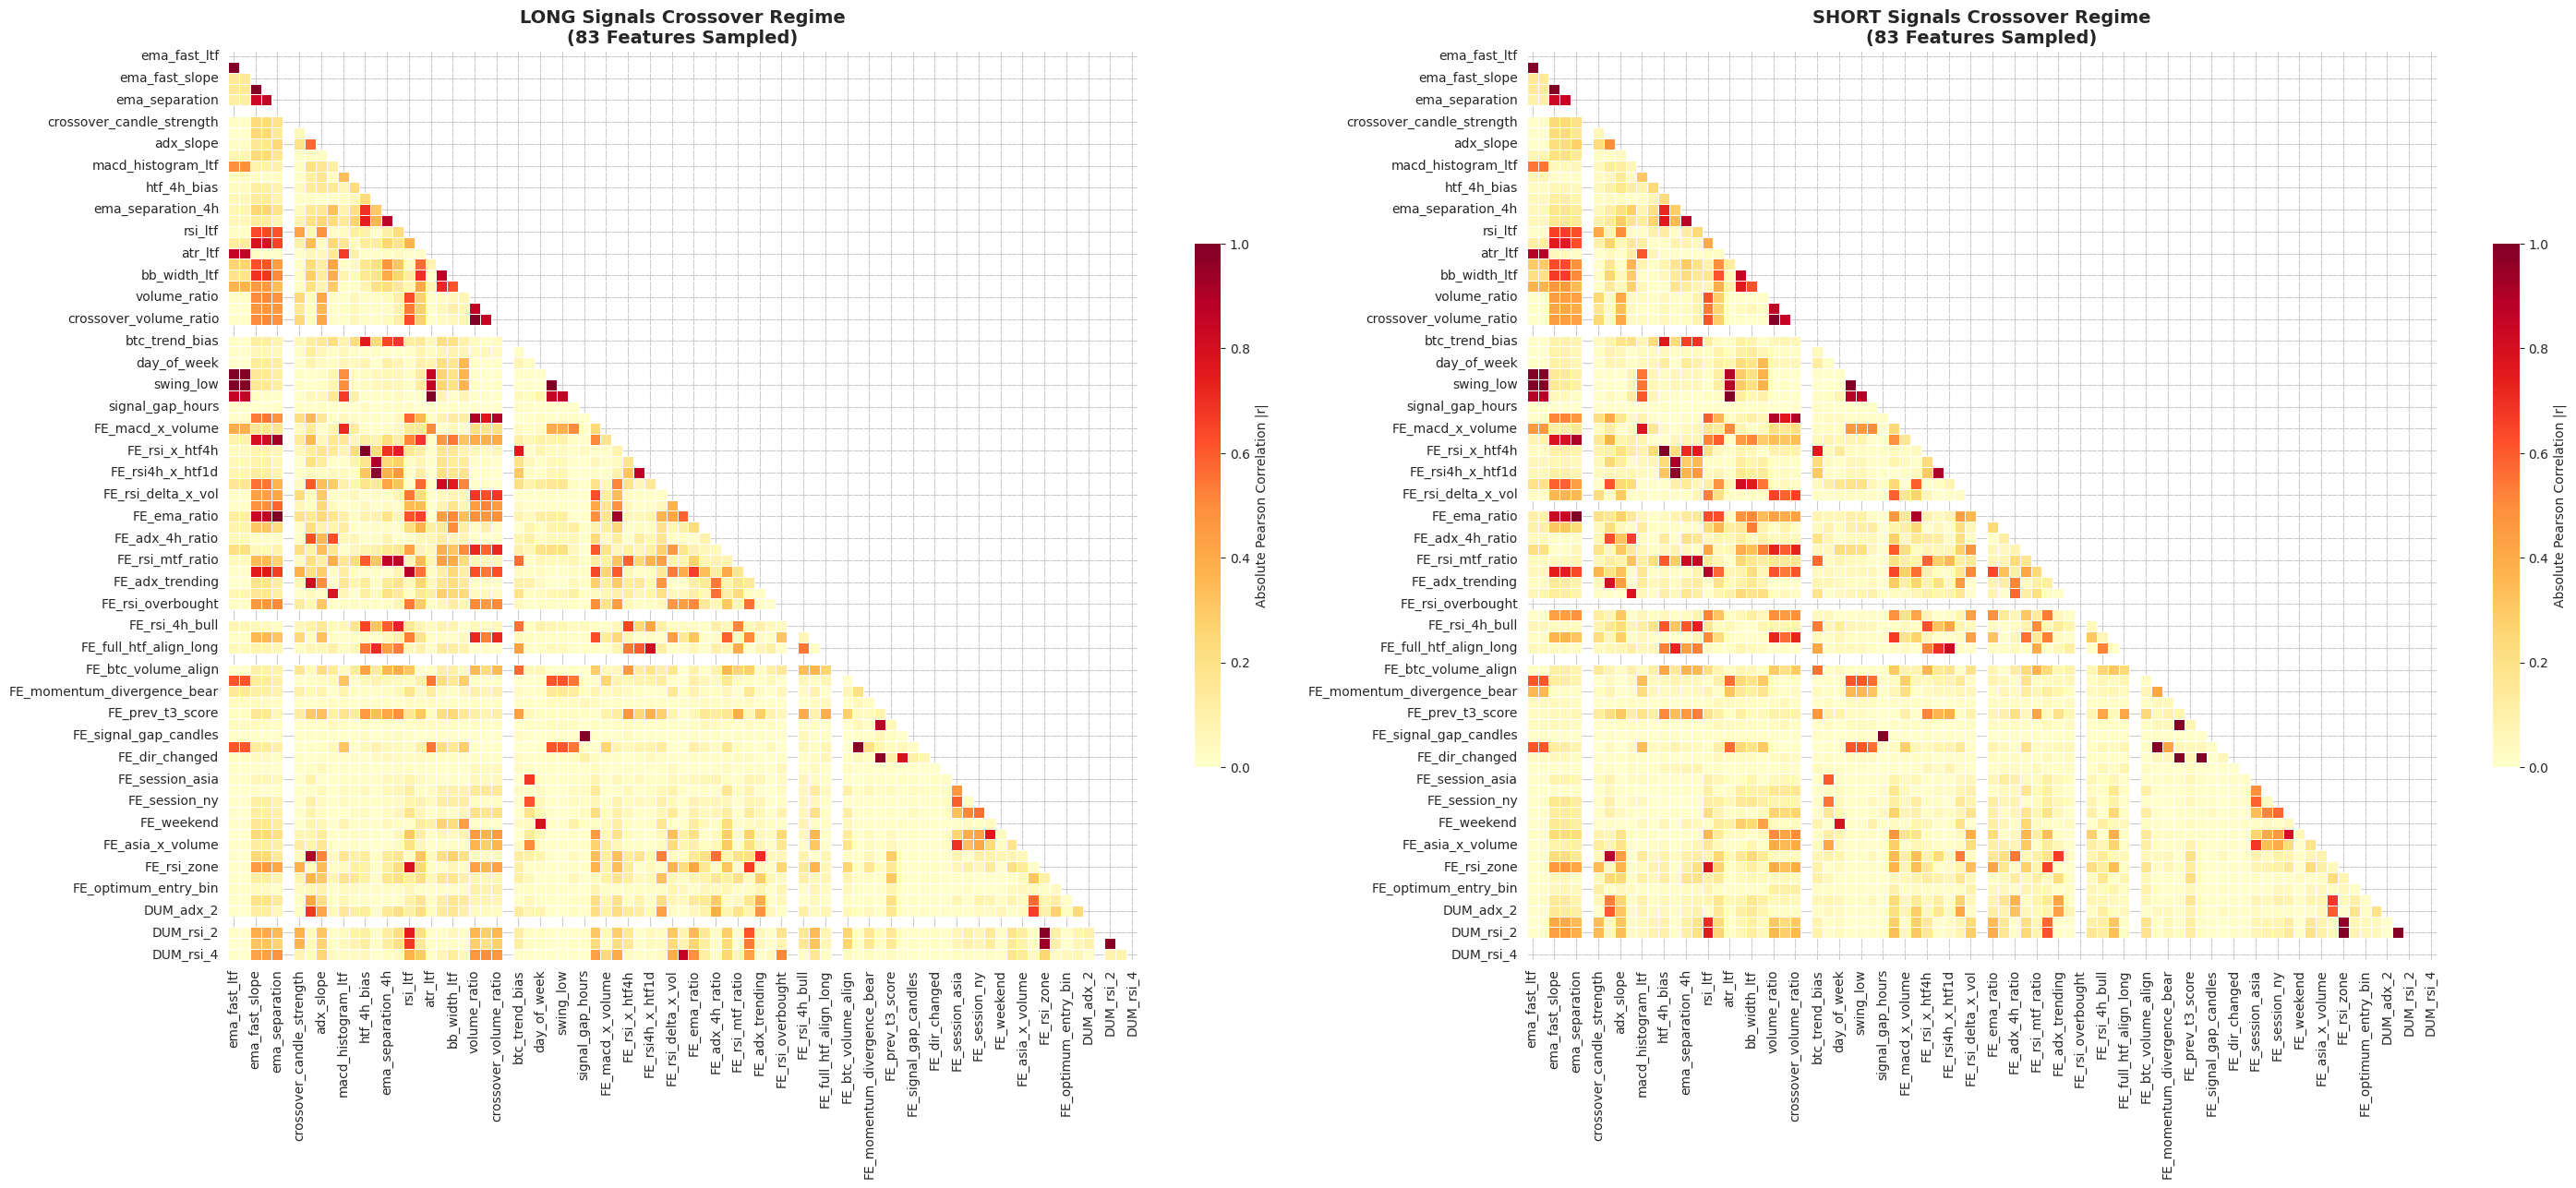

In [28]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


def plot_dual_correlation_heatmaps(df, features_long, features_short):
    """Plots side-by-side upper-triangle correlation heatmaps for LONG and SHORT regimes."""
    # 1. Isolate regimes and compute absolute correlation matrices
    df_long = df[df["signal_x"] == "LONG"].copy()
    df_short = df[df["signal_x"] == "SHORT"].copy()

    corr_long = df_long[features_long].corr().abs()
    corr_short = df_short[features_short].corr().abs()

    # 2. Generate upper triangle masks (True where we want to HIDE data)
    mask_long = np.triu(np.ones(corr_long.shape), k=0).astype(bool)
    mask_short = np.triu(np.ones(corr_short.shape), k=0).astype(bool)

    # 3. Setup side-by-side plotting area
    # Dynamically scale layout scale based on your feature count size
    fig_width = max(14, len(features_long) * 0.35)
    fig, axes = plt.subplots(1, 2, figsize=(fig_width, fig_width * 0.45))

    # Define color scheme: clear, high-contrast sequential profile
    cmap_profile = "YlOrRd"

    # --- Left Plot: LONG ---
    sns.heatmap(
        corr_long,
        mask=mask_long,
        cmap=cmap_profile,
        vmax=1.0,
        vmin=0.0,
        center=0.5,
        square=True,
        linewidths=0.5,
        cbar_kws={"shrink": 0.5, "label": "Absolute Pearson Correlation |r|"},
        ax=axes[0],
        annot=False,  # Set to True if your feature count is small (<15)
    )
    axes[0].set_title(
        f"LONG Signals Crossover Regime\n({len(features_long)} Features Sampled)",
        fontsize=14,
        weight="bold",
    )

    # --- Right Plot: SHORT ---
    sns.heatmap(
        corr_short,
        mask=mask_short,
        cmap=cmap_profile,
        vmax=1.0,
        vmin=0.0,
        center=0.5,
        square=True,
        linewidths=0.5,
        cbar_kws={"shrink": 0.5, "label": "Absolute Pearson Correlation |r|"},
        ax=axes[1],
        annot=False,
    )
    axes[1].set_title(
        f"SHORT Signals Crossover Regime\n({len(features_short)} Features Sampled)",
        fontsize=14,
        weight="bold",
    )

    plt.tight_layout()
    plt.show()


# To execute:
plot_dual_correlation_heatmaps(df, FEATURES_COMBINED_LONG, FEATURES_COMBINED_SHORT)

In [29]:
import numpy as np
import pandas as pd

def clean_correlation_equal_treatment(df_filtered, feature_list, regime_label="REGIME"):
    """
    Computes absolute Pearson correlation, identifies pairs with |r| > 0.90,
    and drops the feature with the lower variance to treat all features equally.

    Returns:
        dropped_features (list): Unique names of features removed.
        clean_features (list): Retained uncorrelated features.
        violation_pairs (list): Full audit list of tuples (feature_A, feature_B, r_value)
    """
    # 1. Compute absolute Pearson correlation matrix
    corr_matrix = df_filtered[feature_list].corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    # 2. Extract all unique pairs violating the 0.60 threshold
    high_corr_pairs = [
        (col, row, upper.loc[row, col])
        for col in upper.columns
        for row in upper.index
        if upper.loc[row, col] > 0.60
    ]

    features_to_drop = set()
    violation_pairs_audit = []

    # 3. Decision Loop based on Variance Tie-Breaker
    for col, row, r_val in high_corr_pairs:
        violation_pairs_audit.append((col, row, r_val))

        # If one has already been marked for dropping, skip to prevent cascading drops
        if col in features_to_drop or row in features_to_drop:
            continue

        # Fetch variances to evaluate information spread
        var_col = df_filtered[col].var()
        var_row = df_filtered[row].var()

        # Drop lower variance feature
        if var_col < var_row:
            features_to_drop.add(col)
        else:
            features_to_drop.add(row)

    # 4. Filter original list to keep remaining features
    clean_features = [f for f in feature_list if f not in features_to_drop]
    dropped_features = list(features_to_drop)

    # Print clean diagnostic logging immediately
    print(f"\n--- {regime_label} Audit Breakdown ---")
    print(f"Total collinear pairs violating threshold: {len(high_corr_pairs)}")
    print(f"Unique features discarded:                 {len(dropped_features)}")
    print(f"Discarded list:\n 👉 {dropped_features}\n")

    return dropped_features, clean_features, violation_pairs_audit

# ============================================================
# EXECUTE EQUAL FILTERING & ASSIGN APPROPRIATE NAMES
# ============================================================

# 1. Process LONG Signals Crossover Regime
df_long = df[df["signal_x"] == "LONG"].copy()
REMOVED_FEATURES_LONG_PEARSON, FEATURES_LONG_PEARSON_PRUNED, VIOLATIONS_LONG = clean_correlation_equal_treatment(
    df_long, FEATURES_COMBINED_LONG, regime_label="LONG SIGNALS"
)

# 2. Process SHORT Signals Crossover Regime
df_short = df[df["signal_x"] == "SHORT"].copy()
REMOVED_FEATURES_SHORT_PEARSON, FEATURES_SHORT_PEARSON_PRUNED, VIOLATIONS_SHORT = clean_correlation_equal_treatment(
    df_short, FEATURES_COMBINED_SHORT, regime_label="SHORT SIGNALS"
)

# ============================================================
# MASTER SUMMARY REPORT
# ============================================================
print("==================================================")
print("📊 UNBIASED PEARSON CORRELATION PIPELINE COMPLETE")
print("==================================================")
print(f"FINAL LONG UNCORRELATED:  {len(FEATURES_LONG_PEARSON_PRUNED)} features remaining.")
print(f"FINAL SHORT UNCORRELATED: {len(FEATURES_SHORT_PEARSON_PRUNED)} features remaining.")
print("==================================================")


--- LONG SIGNALS Audit Breakdown ---
Total collinear pairs violating threshold: 130
Unique features discarded:                 47
Discarded list:
 👉 ['FE_ema_ratio', 'FE_session_asia', 'macd_histogram_ltf', 'FE_high_volume', 'DUM_adx_2', 'DUM_rsi_3', 'FE_same_dir_streak', 'ema_fast_ltf', 'ema_separation_4h', 'ema_slow_slope', 'ema_fast_slope', 'FE_full_htf_align_long', 'FE_bb_squeeze_regime', 'FE_vol_efficiency_ratio', 'atr_pct', 'signal_gap_hours', 'crossover_volume_ratio', 'FE_rsi_delta_x_vol', 'FE_adx_x_htf1d', 'htf_4h_bias', 'volume_trend', 'ema_slow_ltf', 'FE_spread_to_atr_ratio', 'swing_low', 'atr_stop_distance', 'FE_exhaustion_risk', 'bb_width_ltf', 'htf_1d_bias', 'btc_trend_bias', 'ema_separation', 'FE_adx_4h_ratio', 'FE_adx_regime', 'roc_ltf', 'FE_session_ny', 'volume_ratio', 'FE_adx_4h_trending', 'FE_rsi_4h_bull', 'FE_dir_changed', 'FE_prev_bb_squeeze', 'atr_ltf', 'FE_session_overlap', 'rsi_4h', 'DUM_rsi_2', 'FE_rsi_zone', 'FE_adx_x_atr_pct', 'FE_weekend', 'FE_adx_trending']

In [30]:
import numpy as np
import pandas as pd

def clean_correlation_strict_treatment(df_filtered, feature_list, threshold=0.60, regime_label="REGIME"):
    """
    Computes absolute Pearson correlation, identifies pairs with |r| > threshold (0.60),
    and drops the feature with the lower variance to ensure zero directional bias.
    """
    # 1. Compute absolute Pearson correlation matrix
    corr_matrix = df_filtered[feature_list].corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    # 2. Extract all unique pairs violating the 0.60 threshold
    high_corr_pairs = [
        (col, row, upper.loc[row, col])
        for col in upper.columns
        for row in upper.index
        if upper.loc[row, col] > threshold
    ]

    features_to_drop = set()
    violation_pairs_audit = []

    # 3. Variance-Based Tie-Breaker Selection Loop
    for col, row, r_val in high_corr_pairs:
        violation_pairs_audit.append((col, row, r_val))

        # Skip if either partner has already been dropped to protect feature volume
        if col in features_to_drop or row in features_to_drop:
            continue

        # Fetch variances on the filtered dataset slice
        var_col = df_filtered[col].var()
        var_row = df_filtered[row].var()

        # Drop the feature containing less variance spread
        if var_col < var_row:
            features_to_drop.add(col)
        else:
            features_to_drop.add(row)

    # 4. Construct final active arrays
    clean_features = [f for f in feature_list if f not in features_to_drop]
    dropped_features = list(features_to_drop)

    print(f"\n--- {regime_label} Strict Audit (Ceiling: {threshold}) ---")
    print(f"Total collinear pairs dropped:       {len(violation_pairs_audit)}")
    print(f"Unique features entirely discarded:   {len(dropped_features)}")

    return dropped_features, clean_features

# ============================================================
# EXECUTE STRICT CORRELATION PRUNING (0.60)
# ============================================================

# 1. Tighter Long Signals Pipeline
df_long = df[df["signal_x"] == "LONG"].copy()
REMOVED_FEATURES_LONG_STRICT, FEATURES_LONG_STRICT_PRUNED = clean_correlation_strict_treatment(
    df_long, FEATURES_COMBINED_LONG, threshold=0.50, regime_label="LONG SIGNALS"
)

# 2. Tighter Short Signals Pipeline
df_short = df[df["signal_x"] == "SHORT"].copy()
REMOVED_FEATURES_SHORT_STRICT, FEATURES_SHORT_STRICT_PRUNED = clean_correlation_strict_treatment(
    df_short, FEATURES_COMBINED_SHORT, threshold=0.50, regime_label="SHORT SIGNALS"
)

print("\n==================================================")
print("✅ STRICT PEARSON 0.60 FILTRATION COMPLETE")
print("==================================================")
print(f"STRICT LONG REMAINING:  {len(FEATURES_LONG_STRICT_PRUNED)} features.")
print(f"STRICT SHORT REMAINING: {len(FEATURES_SHORT_STRICT_PRUNED)} features.")
print("==================================================")


--- LONG SIGNALS Strict Audit (Ceiling: 0.5) ---
Total collinear pairs dropped:       198
Unique features entirely discarded:   51

--- SHORT SIGNALS Strict Audit (Ceiling: 0.5) ---
Total collinear pairs dropped:       191
Unique features entirely discarded:   49

✅ STRICT PEARSON 0.60 FILTRATION COMPLETE
STRICT LONG REMAINING:  32 features.
STRICT SHORT REMAINING: 34 features.


In [31]:
import numpy as np
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

def run_production_vif_cleaner(df_source, feature_list, max_vif_threshold=5.0):
    """
    Safely adds an intercept, handles NaNs, and iteratively drops the highest VIF
    feature one by one to prevent total feature erasure.
    """
    # 1. Clean data and isolate features
    df_clean = df_source[feature_list].replace([np.inf, -np.inf], np.nan).dropna().copy()

    current_features = list(feature_list)
    vif_drop_log = []

    print(f"Running corrected VIF calculation on {len(current_features)} features...")

    while True:
        if len(current_features) <= 1:
            break

        # 2. CRITICAL FIX: Add the intercept column (constant) required by statsmodels
        X_matrix_raw = df_clean[current_features].values
        X_matrix = add_constant(X_matrix_raw, has_constant='add')

        # 3. Compute VIF for active columns (index 0 is the constant, so offset by 1)
        vif_list = []
        for i in range(1, X_matrix.shape[1]):
            try:
                vif_val = variance_inflation_factor(X_matrix, i)
                vif_list.append(vif_val)
            except Exception:
                vif_list.append(999.0)

        vif_df = pd.DataFrame({'feature': current_features, 'VIF': vif_list})
        vif_df = vif_df.sort_values('VIF', ascending=False).reset_index(drop=True)

        highest_row = vif_df.iloc[0]
        highest_feature = highest_row['feature']
        highest_vif = highest_row['VIF']

        # Stop looping if the worst feature left is below our threshold
        if highest_vif <= max_vif_threshold or np.isnan(highest_vif):
            break

        # Log and remove the single worst offender
        vif_drop_log.append((highest_feature, highest_vif))
        current_features.remove(highest_feature)

    # 4. Final Remaining Matrix Snapshot
    final_X = add_constant(df_clean[current_features].values, has_constant='add')
    final_vifs = [variance_inflation_factor(final_X, i) for i in range(1, final_X.shape[1])]
    final_vif_df = pd.DataFrame({'feature': current_features, 'VIF': final_vifs}).sort_values('VIF', ascending=False)

    print(f"\n✅ RECOVERY COMPLETE. Retained {len(current_features)} high-quality features.")
    print(final_vif_df.head(10).to_string(index=False, formatters={'VIF': '{:,.2f}'.format}))

    return vif_drop_log, current_features

# ============================================================
# RUN SAFE RECOVERY OVER YOUR 7000 ROWS
# ============================================================

VIF_DROPPED_LONG, FEATURES_LONG_AFTER_VIF = run_production_vif_cleaner(
    df_long, FEATURES_LONG_STRICT_PRUNED, max_vif_threshold=5.0
)

VIF_DROPPED_SHORT, FEATURES_SHORT_AFTER_VIF = run_production_vif_cleaner(
    df_short, FEATURES_SHORT_STRICT_PRUNED, max_vif_threshold=5.0
)

Running corrected VIF calculation on 32 features...

✅ RECOVERY COMPLETE. Retained 31 high-quality features.
            feature  VIF
    FE_adx_x_volume 2.63
   FE_asia_x_volume 2.03
       price_to_atr 1.81
            adx_ltf 1.79
   FE_prev_t3_score 1.69
     FE_rsi_x_htf4h 1.66
FE_overlap_x_volume 1.61
         swing_high 1.57
FE_btc_volume_align 1.50
        FE_rsi_zone 1.48
Running corrected VIF calculation on 34 features...

✅ RECOVERY COMPLETE. Retained 33 high-quality features.
            feature  VIF
    FE_adx_x_volume 3.23
            adx_ltf 2.37
          adx_slope 2.09
   FE_asia_x_volume 2.02
       price_to_atr 1.82
   FE_ema_sep_x_adx 1.79
FE_overlap_x_volume 1.77
         swing_high 1.77
        FE_rsi_zone 1.57
    FE_rsi_oversold 1.57


In [32]:
import numpy as np
import pandas as pd
from sklearn.feature_selection import mutual_info_classif

# ============================================================
# STEP 3: MUTUAL INFORMATION (MI) RANKING ENGINE
# ============================================================

def compute_regime_mutual_information(df_source, active_features, target_col='target_b', regime_label="REGIME"):
    """
    Computes and ranks Mutual Information scores for a hybrid feature footprint,
    explicitly accounting for continuous vs. discrete (boolean/integer) columns.
    """
    # 1. Clean data rows targeting valid labels only
    df_mi = df_source[[target_col] + active_features].replace([np.inf, -np.inf], np.nan).dropna().copy()

    X = df_mi[active_features]
    y = df_mi[target_col].astype(int)

    # 2. Build the discrete feature mask
    # Tells scikit-learn which columns are flags/integers vs raw continuous decimals
    discrete_mask = []
    for col in active_features:
        is_discrete = (
            X[col].dtype in [bool, np.int64, np.int32] or
            col.startswith('DUM_') or
            'bin' in col.lower() or
            'weekend' in col.lower()
        )
        discrete_mask.append(is_discrete)

    print(f"Calculating MI for {regime_label} ({len(active_features)} features, {X.shape[0]} rows)...")

    # 3. Compute MI Scores (k_neighbors=3 is standard for balancing bias/variance)
    mi_scores = mutual_info_classif(
        X, y,
        discrete_features=discrete_mask,
        n_neighbors=3,
        random_state=42
    )

    # 4. Process and sort results
    df_results = pd.DataFrame({
        'Feature': active_features,
        'MI_Score': mi_scores
    }).sort_values(by='MI_Score', ascending=False).reset_index(drop=True)

    print(f"\n🏆 TOP 15 PREDICTIVE FEATURES BY MUTUAL INFORMATION ({regime_label}):")
    print(df_results.head(15).to_string(index=True, formatters={'MI_Score': '{:,.4f}'.format}))

    # Keep a record of flat-lined features with zero predictive value
    zero_signal_features = df_results[df_results['MI_Score'] == 0.0]['Feature'].tolist()
    print(f"\n⚠️ Identified {len(zero_signal_features)} features with 0.0000 informational value.")

    return df_results, zero_signal_features

# ============================================================
# EXECUTE EVALUATION OVER SURVIVING COLUMNS
# ============================================================

# Filter your dataframes for targets
df_long_clean = df[df['signal_x'] == 'LONG'].copy()
df_short_clean = df[df['signal_x'] == 'SHORT'].copy()

# Run MI ranking over the features that passed your previous Pearson & VIF filters
MI_RANKINGS_LONG, ZERO_SIGNAL_LONG = compute_regime_mutual_information(
    df_long_clean, FEATURES_LONG_AFTER_VIF, target_col='class_target_1', regime_label="LONG CROSSOVERS"
)

MI_RANKINGS_SHORT, ZERO_SIGNAL_SHORT = compute_regime_mutual_information(
    df_short_clean, FEATURES_SHORT_AFTER_VIF, target_col='class_target_1', regime_label="SHORT CROSSOVERS"
)

Calculating MI for LONG CROSSOVERS (31 features, 3533 rows)...

🏆 TOP 15 PREDICTIVE FEATURES BY MUTUAL INFORMATION (LONG CROSSOVERS):
                      Feature MI_Score
0            FE_asia_x_volume   0.0194
1            FE_rsi4h_x_htf1d   0.0162
2            FE_prev_t3_score   0.0155
3                price_to_atr   0.0145
4           macd_histogram_4h   0.0144
5        FE_optimum_entry_bin   0.0127
6    FE_prev_signal_gap_decay   0.0086
7                 hour_of_day   0.0084
8         FE_overlap_x_volume   0.0076
9              FE_rsi_x_htf4h   0.0066
10                day_of_week   0.0043
11           FE_macd_x_volume   0.0034
12          FE_session_london   0.0028
13  crossover_candle_strength   0.0027
14            FE_adx_x_volume   0.0018

⚠️ Identified 9 features with 0.0000 informational value.
Calculating MI for SHORT CROSSOVERS (33 features, 3531 rows)...

🏆 TOP 15 PREDICTIVE FEATURES BY MUTUAL INFORMATION (SHORT CROSSOVERS):
                        Feature MI_Score
0     

In [33]:
df


,id_x,checked_at_utc,symbol,signal_x,price,signal_gap_hours,prev_signal,ema_fast_ltf,ema_slow_ltf,ema_fast_slope,ema_slow_slope,ema_separation,price_above_both_emas,crossover_candle_strength,adx_ltf,adx_slope,adx_4h,macd_histogram_ltf,macd_histogram_4h,htf_4h_bias,htf_1d_bias,ema_separation_4h,rsi_4h,rsi_ltf,roc_ltf,atr_ltf,atr_pct,bb_width_ltf,price_to_atr,volume_ratio,volume_trend,crossover_volume_ratio,fear_greed_index,btc_trend_bias,hour_of_day,day_of_week,swing_high,swing_low,atr_stop_distance,max_price_after,min_price_after,max_move_up_pct,max_move_down_pct,time_of_max_price,time_of_min_price,candles_to_max_price,candles_to_min_price,status,id_y,signal_y,entry_price,optimal_entry,optimal_entry_utc,mfe_percent,mae_percent,trade_duration,next_crossover_utc,exit_price,pnl_percent,created_at,T1_Pure_Continuous,T2_Soft_Floor,T3_Assumption_Penalty,T4_Control_Punished,target_special,Optimum_entry,target_b,class_target_1,class_target_2,FE_adx_x_volume,FE_macd_x_volume,FE_ema_sep_x_adx,FE_rsi_x_htf4h,FE_adx_x_htf1d,FE_rsi4h_x_htf1d,FE_adx_x_atr_pct,FE_rsi_delta_x_vol,FE_exhaustion_risk,FE_ema_ratio,FE_price_to_bb,FE_adx_4h_ratio,FE_vol_efficiency_ratio,FE_rsi_mtf_ratio,FE_spread_to_atr_ratio,FE_adx_trending,FE_adx_4h_trending,FE_rsi_overbought,FE_rsi_oversold,FE_rsi_4h_bull,FE_high_volume,FE_full_htf_align_long,FE_full_htf_align_short,FE_btc_volume_align,FE_bb_squeeze_regime,FE_momentum_divergence_bear,FE_prev_signal_dir,FE_prev_t3_score,FE_same_dir_streak,FE_signal_gap_candles,FE_prev_bb_squeeze,FE_dir_changed,FE_prev_signal_gap_decay,FE_session_asia,FE_session_london,FE_session_ny,FE_session_overlap,FE_weekend,FE_overlap_x_volume,FE_asia_x_volume,FE_adx_regime,FE_rsi_zone,FE_mfe_mae_ratio_lag,FE_optimum_entry_bin,DUM_adx_1,DUM_adx_2,DUM_rsi_1,DUM_rsi_2,DUM_rsi_3,DUM_rsi_4
0,985,2025-10-03 09:15:00+00:00,BTCUSDT,LONG,120291.2600,25.23,LONG,119951.649884,119933.052484,0.0708,0.0427,0.0155,True,0.1705,21.05,-1.02,57.71,53.247772,138.138157,True,True,0.8579,74.70,60.90,0.3498,217.361763,0.1807,0.6121,553.42,1.7411,7.8538,1.7411,50,True,9,4,120365.3500,119248.3000,326.042644,123894.9900,119881.2400,2.9958,0.3409,2025-10-03 16:30:00+00:00,2025-10-03 14:15:00+00:00,29,20,analyzed,1526,LONG,120291.2600,119881.2400,2025-10-03 14:15:00+00:00,3.00,-0.34,57,2025-10-03 23:30:00+00:00,122277.0500,1.65,2026-05-25T20:22:18.004815+00:00,8.37,8.37,8.37,7.50,8.37,20.0,2.389222,1,1,36.650155,92.709696,0.326275,60.90,21.05,74.70,0.038037,24.357989,0.0,1.000155,0.295213,0.364755,9.635307,0.815261,1.562419,0,1,0,0,1,1,1,0,1,1,0,0,0.00,1,100.92,0,0,1.0,0,1,0,0,0,0.0000,0.0000,1,3,0.850122,2,1,0,0,0,1,0
1,986,2025-10-03 23:30:00+00:00,BTCUSDT,SHORT,122300.9800,0.00,LONG,122370.217235,122376.478352,-0.0141,-0.0088,-0.0051,False,0.5909,9.12,0.08,60.23,-66.745648,197.286436,True,True,0.9525,76.93,50.85,0.0076,310.590884,0.2540,0.6322,393.77,0.4651,-7.5621,0.4651,50,True,23,4,122665.0000,121999.3300,465.886326,122332.6800,121684.9700,0.0259,0.5037,2025-10-03 23:30:00+00:00,2025-10-04 02:30:00+00:00,0,12,analyzed,1527,SHORT,122300.9800,122332.6800,2025-10-03 23:30:00+00:00,0.50,-0.03,18,2025-10-04 04:00:00+00:00,122243.9900,0.05,2026-05-25T20:22:18.004815+00:00,10.00,1.00,6.50,0.00,1.00,0.0,0.443396,1,0,4.241712,-31.043401,-0.046512,50.85,9.12,76.93,0.023161,-0.734858,-0.0,0.999949,0.401772,0.151420,1.831102,0.660991,-0.222921,0,1,0,0,1,0,1,0,0,1,1,1,8.37,1,0.00,1,1,0.0,1,0,0,0,0,0.0000,0.4651,0,2,8.787914,0,0,0,0,1,0,0
2,987,2025-10-04 04:00:00+00:00,BTCUSDT,LONG,122281.7800,0.00,SHORT,122074.240112,122066.414749,0.0425,0.0252,0.0064,True,0.1107,16.48,-0.50,61.09,34.708714,91.809199,True,True,0.8724,77.21,57.76,0.3418,198.136325,0.1620,0.5640,617.16,0.8978,-0.7371,0.8978,50,True,4,5,122325.6000,121684.9700,297.204488,122800.0000,122197.6300,0.4238,0.0688,2025-10-04 05:15:00+00:00,2025-10-04 08:45:00+00:00,5,19,analyzed,1528,LONG,122281.7800,122219.3000,2025-10-04 04:15:00+00:00,0.42,-0.05,19,2025-10-04 08:45:00+00:00,122234.4900,-0.04,2026-05-25T20:22:18.0

noticed that mi seems to priorites time based features so am excluding it for now

# ==========================================================================
# 🛠️ DYNAMIC PIPELINE CONFIGURATION MATRIX
# ==========================================================================

pipeline_config = {
    "linear_track": {
        "pearson_threshold": 0.60,
        "run_vif": True,
        "vif_threshold": 5.0,
        "run_mi": False
    },
    "tree_track": {
        "pearson_threshold": 0.85,
        "run_vif": False,       # Collinearity doesn't hurt tree structures
        "vif_threshold": None,
        "run_mi": True,
        "mi_exclude_features": ['hour_of_day', 'day_of_week'] # Protects against time-drift
    }
}


=== RUNNING PERMUTATION GATEKEEPER FOR LONG SIGNALS ===
Calculating permutation importance for LONG CROSSOVERS across 31 features...


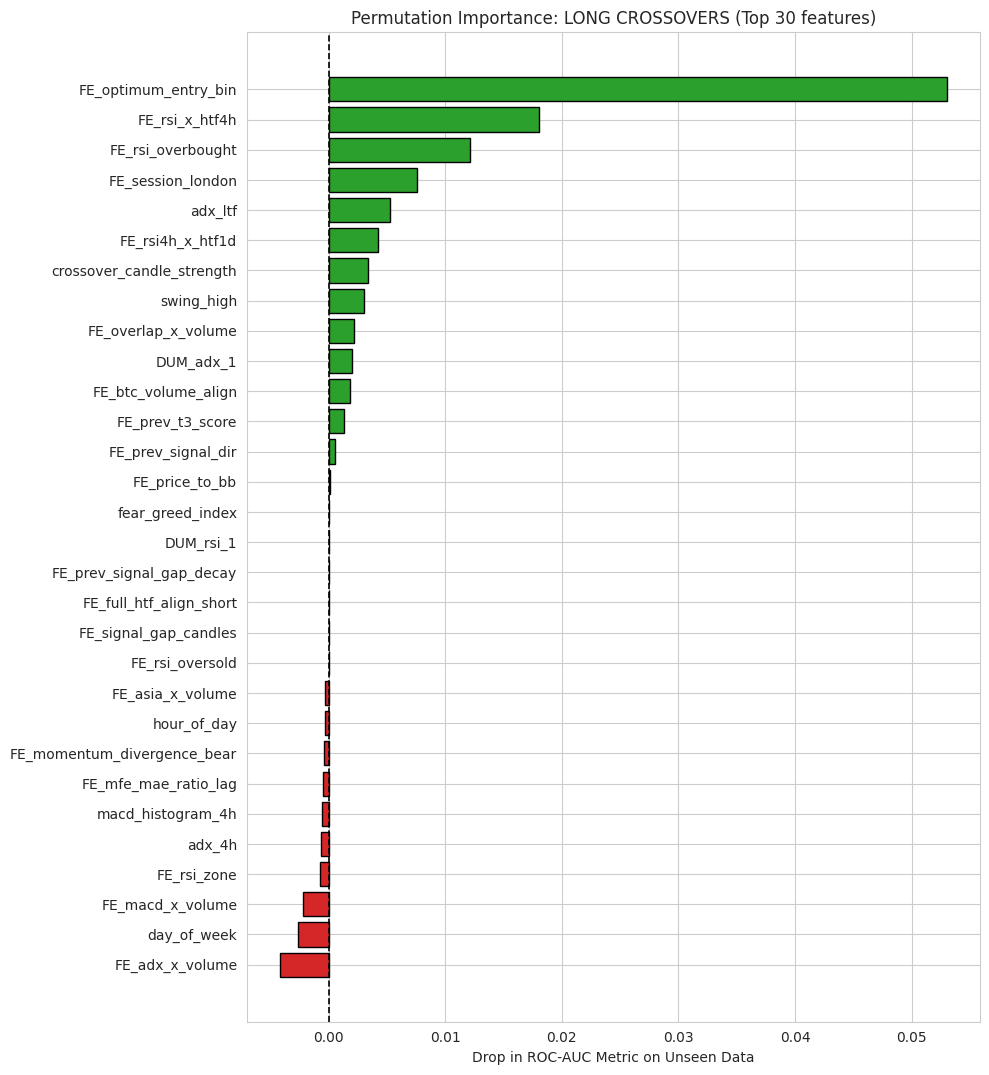


📊 LONG CROSSOVERS RECONCILIATION SUMMARY:
✅ Retained 14 features with positive predictive alpha.
❌ Dropped 17 features that added noise out-of-sample.
Sample dropped features: ['fear_greed_index', 'DUM_rsi_1', 'FE_prev_signal_gap_decay', 'FE_full_htf_align_short', 'FE_signal_gap_candles']

=== RUNNING PERMUTATION GATEKEEPER FOR SHORT SIGNALS ===
Calculating permutation importance for SHORT CROSSOVERS across 33 features...


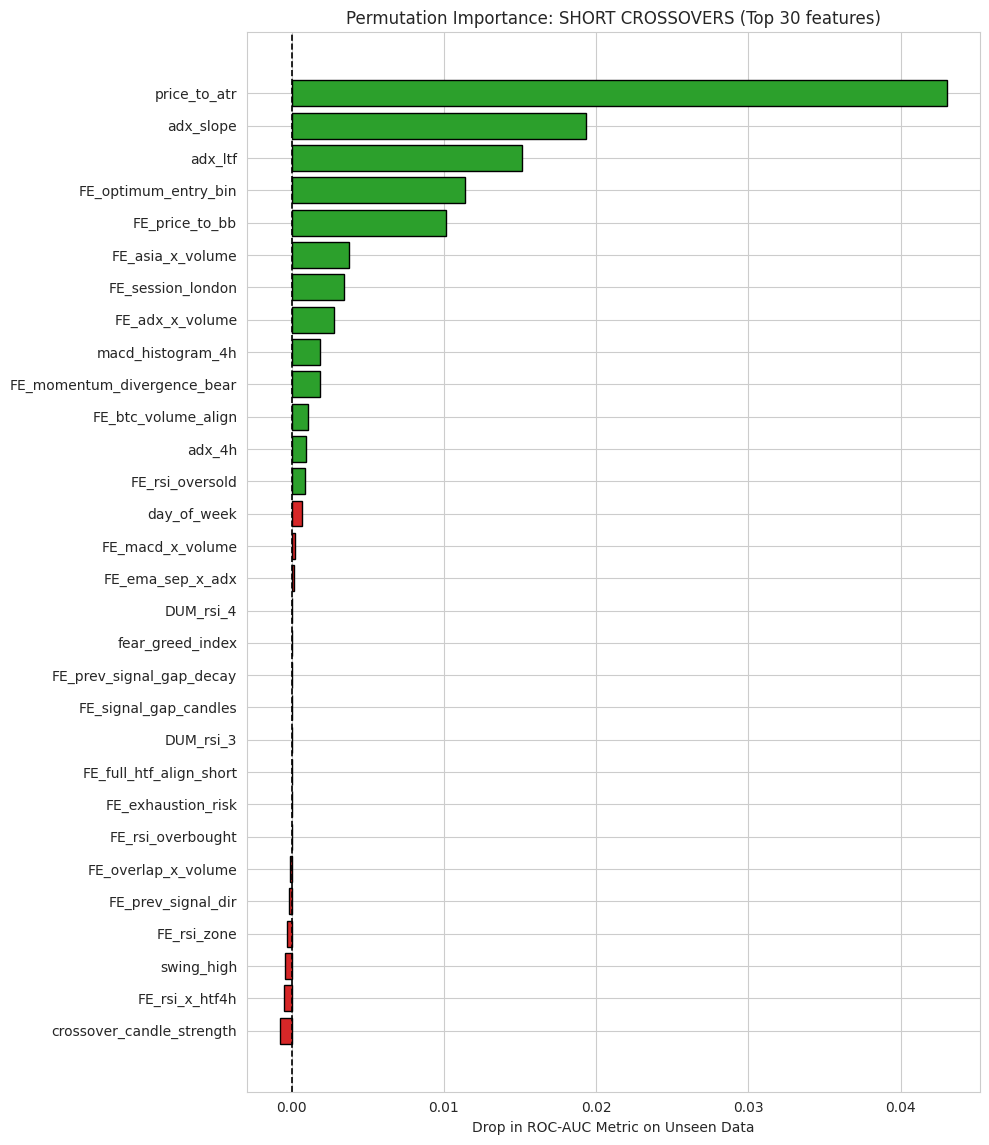


📊 SHORT CROSSOVERS RECONCILIATION SUMMARY:
✅ Retained 16 features with positive predictive alpha.
❌ Dropped 17 features that added noise out-of-sample.
Sample dropped features: ['DUM_rsi_4', 'fear_greed_index', 'FE_prev_signal_gap_decay', 'FE_signal_gap_candles', 'DUM_rsi_3']

Permutation importance filtering complete ✓
Final production count -> LONG: 14 features | SHORT: 16 features.


In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance

# ============================================================
# STEP 3: PERMUTATION IMPORTANCE (LINEAR TRACK)
# ============================================================

def evaluate_permutation_importance(df_source, active_features, target_col='binary_target', regime_label="REGIME"):
    """
    Executes chronological train-test splitting, track-specific scaling,
    and permutation importance scoring to eliminate out-of-sample noise.
    """
    # 1. Prepare data matrix, ensuring strict time order to prevent look-ahead leakage
    required_cols = active_features + [target_col, 'checked_at_utc']
    df_clean = df_source[required_cols].replace([np.inf, -np.inf], np.nan).dropna().copy()
    df_clean = df_clean.sort_values('checked_at_utc').reset_index(drop=True)

    if df_clean.empty or len(df_clean) < 100:
        print(f"⚠️ Insufficient rows for {regime_label} permutation evaluation.")
        return active_features

    # 2. Chronological 80/20 split
    split_idx = int(len(df_clean) * 0.8)
    train_set = df_clean.iloc[:split_idx]
    test_set  = df_clean.iloc[split_idx:]

    X_train = train_set[active_features].values
    y_train = train_set[target_col].values.astype(int)
    X_test  = test_set[active_features].values
    y_test  = test_set[target_col].values.astype(int)

    # 3. Scale features (fit on train matrix only to prevent data bleed)
    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc  = scaler.transform(X_test)

    # 4. Train baseline Logistic Regression
    lr_model = LogisticRegression(C=1.0, class_weight='balanced', max_iter=1000, random_state=42)
    lr_model.fit(X_train_sc, y_train)

    # 5. Compute Permutation Importance across 20 destructive shuffles
    print(f"Calculating permutation importance for {regime_label} across {len(active_features)} features...")
    perm_result = permutation_importance(
        lr_model, X_test_sc, y_test,
        n_repeats=20, scoring='roc_auc', random_state=42, n_jobs=-1
    )

    # 6. Structuring results table
    df_perm = pd.DataFrame({
        'Feature': active_features,
        'importance_mean': perm_result.importances_mean,
        'importance_std': perm_result.importances_std
    }).sort_values(by='importance_mean', ascending=False).reset_index(drop=True)

    # 7. Generate Horizontal Bar Chart
    plt.figure(figsize=(10, min(14, len(active_features) * 0.35)))
    colors = ['#2ca02c' if m > 0 else '#d62728' for m in df_perm['importance_mean']]

    plt.barh(df_perm['Feature'].head(30)[::-1], df_perm['importance_mean'].head(30)[::-1], color=colors[::-1], edgecolor='black')
    plt.axvline(x=0, color='black', linestyle='--', linewidth=1.2)
    plt.xlabel('Drop in ROC-AUC Metric on Unseen Data')
    plt.title(f'Permutation Importance: {regime_label} (Top 30 features)')
    plt.tight_layout()
    plt.show()

    # 8. Filter out the noise features (keep mean > 0)
    features_final = df_perm[df_perm['importance_mean'] > 0.0]['Feature'].tolist()
    features_dropped = df_perm[df_perm['importance_mean'] <= 0.0]['Feature'].tolist()

    print(f"\n📊 {regime_label} RECONCILIATION SUMMARY:")
    print(f"✅ Retained {len(features_final)} features with positive predictive alpha.")
    print(f"❌ Dropped {len(features_dropped)} features that added noise out-of-sample.")
    if features_dropped:
        print(f"Sample dropped features: {features_dropped[:5]}")

    return features_final

# ============================================================
# EXECUTE EVALUATION OVER YOUR SURVIVING VIF SELECTION
# ============================================================

# Ensure target naming aligns with your matrix setup ('binary_target')
print("\n=== RUNNING PERMUTATION GATEKEEPER FOR LONG SIGNALS ===")
df_long = df[df['signal_x'] == 'LONG'].copy()
FEATURES_FINAL_LONG = evaluate_permutation_importance(
    df_long, FEATURES_LONG_AFTER_VIF, target_col='class_target_1', regime_label="LONG CROSSOVERS"
)

print("\n=== RUNNING PERMUTATION GATEKEEPER FOR SHORT SIGNALS ===")
df_short = df[df['signal_x'] == 'SHORT'].copy()
FEATURES_FINAL_SHORT = evaluate_permutation_importance(
    df_short, FEATURES_SHORT_AFTER_VIF, target_col='class_target_1', regime_label="SHORT CROSSOVERS"
)

print('\nPermutation importance filtering complete ✓')
print(f'Final production count -> LONG: {len(FEATURES_FINAL_LONG)} features | SHORT: {len(FEATURES_FINAL_SHORT)} features.')


In [43]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# ==============================================================================
# 🚀 WRAPPER-FIRST PIPELINE: PERMUTATION ──► PEARSON (0.60) ──► VIF (5.0)
# ==============================================================================

def run_permutation_first_pipeline(df_source, raw_features, target_col='binary_target', regime_label="REGIME"):
    print(f"\n============= ⚡ STARTING WRAPPER-FIRST PIPELINE: {regime_label} =============")

    # --------------------------------------------------------------------------
    # GATE 1: PERMUTATION IMPORTANCE FIRST (Find out-of-sample alpha)
    # --------------------------------------------------------------------------
    required_cols = list(raw_features) + [target_col, 'checked_at_utc']
    df_clean = df_source[required_cols].replace([np.inf, -np.inf], np.nan).dropna().copy()
    df_clean = df_clean.sort_values('checked_at_utc').reset_index(drop=True)

    split_idx = int(len(df_clean) * 0.8)
    train_set = df_clean.iloc[:split_idx]
    test_set  = df_clean.iloc[split_idx:]

    X_train = train_set[raw_features].values
    y_train = train_set[target_col].values.astype(int)
    X_test  = test_set[raw_features].values
    y_test  = test_set[target_col].values.astype(int)

    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc  = scaler.transform(X_test)

    lr_model = LogisticRegression(C=1.0, class_weight='balanced', max_iter=2000, random_state=42)
    lr_model.fit(X_train_sc, y_train)

    print(f"[GATE 1] Running 20 shuffles across all {len(raw_features)} raw features...")
    perm_result = permutation_importance(
        lr_model, X_test_sc, y_test,
        n_repeats=20, scoring='roc_auc', random_state=42, n_jobs=-1
    )

    df_perm = pd.DataFrame({
        'Feature': raw_features,
        'importance_mean': perm_result.importances_mean
    }).sort_values(by='importance_mean', ascending=False).reset_index(drop=True)

    # Keep only features that actively contribute out-of-sample
    perm_survivors = df_perm[df_perm['importance_mean'] > 0.0]['Feature'].tolist()
    print(f"✅ GATE 1 COMPLETE: Shuffled away noise. Retained {len(perm_survivors)} / {len(raw_features)} features.")

    # --------------------------------------------------------------------------
    # GATE 2: PEARSON CORRELATION (Smash the duplicate clusters)
    # --------------------------------------------------------------------------
    print(f"[GATE 2] Running Pearson correlation (threshold=0.60) on survivors...")
    df_corr_matrix = df_clean[perm_survivors].corr(method='pearson').abs()

    upper_tri = df_corr_matrix.where(np.triu(np.ones(df_corr_matrix.shape), k=1).astype(bool))
    to_drop_pearson = [column for column in upper_tri.columns if any(upper_tri[column] > 0.60)]

    pearson_survivors = [f for f in perm_survivors if f not in to_drop_pearson]
    print(f"✅ GATE 2 COMPLETE: Dropped {len(to_drop_pearson)} pairwise duplicates. Retained {len(pearson_survivors)} features.")

    # --------------------------------------------------------------------------
    # GATE 3: ITERATIVE VIF CLEANER (Remove multi-variable committee copycats)
    # --------------------------------------------------------------------------
    print(f"[GATE 3] Running iterative VIF cleaner (max_vif=5.0) to eliminate group redundancy...")
    vif_features = list(pearson_survivors)

    while True:
        if len(vif_features) <= 1:
            break

        X_matrix_raw = df_clean[vif_features].values
        X_matrix = add_constant(X_matrix_raw, has_constant='add')

        vif_list = []
        for i in range(1, X_matrix.shape[1]):
            try:
                vif_val = variance_inflation_factor(X_matrix, i)
                vif_list.append(vif_val)
            except Exception:
                vif_list.append(999.0)

        vif_df = pd.DataFrame({'feature': vif_features, 'VIF': vif_list})
        vif_df = vif_df.sort_values('VIF', ascending=False).reset_index(drop=True)

        highest_row = vif_df.iloc[0]
        highest_feature = highest_row['feature']
        highest_vif = highest_row['VIF']

        if highest_vif <= 5.0 or np.isnan(highest_vif):
            break

        vif_features.remove(highest_feature)

    print(f"✅ GATE 3 COMPLETE: Final VIF stabilization achieved. Retained {len(vif_features)} features.")
    print(f"============ 🏁 PIPELINE COMPLETE FOR {regime_label} ============\n")

    return vif_features

# ==============================================================================
# RUN THE PIPELINE FOR BOTH REGIMES
# ==============================================================================

# Define your master raw feature combinations
FEATURES_COMBINED_LONG  = list(FEATURES_ALL) + FE_FEATURES
FEATURES_COMBINED_SHORT = list(FEATURES_ALL) + FE_FEATURES

# Slice input dataframes by signal type
df_long_slice = df[df['signal_x'] == 'LONG'].copy()
df_short_slice = df[df['signal_x'] == 'SHORT'].copy()

# Execute reversed architecture
WRAPPER_FIRST_FINAL_LONG = run_permutation_first_pipeline(
    df_long_slice, FEATURES_COMBINED_LONG, target_col='class_target_1', regime_label="LONG CROSSOVERS"
)

WRAPPER_FIRST_FINAL_SHORT = run_permutation_first_pipeline(
    df_short_slice, FEATURES_COMBINED_SHORT, target_col='class_target_1', regime_label="SHORT CROSSOVERS"
)

print(f"🏆 FINAL PRODUCTION COMPARISON COUNTS:")
print(f"📈 Final LONG feature array length:  {len(WRAPPER_FIRST_FINAL_LONG)}")
print(f"📉 Final SHORT feature array length: {len(WRAPPER_FIRST_FINAL_SHORT)}")


============= ⚡ STARTING WRAPPER-FIRST PIPELINE: LONG CROSSOVERS =============
[GATE 1] Running 20 shuffles across all 83 raw features...
✅ GATE 1 COMPLETE: Shuffled away noise. Retained 58 / 83 features.
[GATE 2] Running Pearson correlation (threshold=0.60) on survivors...
✅ GATE 2 COMPLETE: Dropped 36 pairwise duplicates. Retained 22 features.
[GATE 3] Running iterative VIF cleaner (max_vif=5.0) to eliminate group redundancy...
✅ GATE 3 COMPLETE: Final VIF stabilization achieved. Retained 22 features.
============ 🏁 PIPELINE COMPLETE FOR LONG CROSSOVERS ============


============= ⚡ STARTING WRAPPER-FIRST PIPELINE: SHORT CROSSOVERS =============
[GATE 1] Running 20 shuffles across all 83 raw features...
✅ GATE 1 COMPLETE: Shuffled away noise. Retained 62 / 83 features.
[GATE 2] Running Pearson correlation (threshold=0.60) on survivors...
✅ GATE 2 COMPLETE: Dropped 38 pairwise duplicates. Retained 24 features.
[GATE 3] Running iterative VIF cleaner (max_vif=5.0) to eliminate group r

In [91]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# ==============================================================================
# 🚀 WRAPPER-FIRST PIPELINE: PERMUTATION ──► PEARSON (0.60) ──► VIF (5.0)
# ==============================================================================

def run_permutation_first_pipeline(df_source, raw_features, target_col='binary_target', regime_label="REGIME"):
    print(f"\n============= ⚡ STARTING WRAPPER-FIRST PIPELINE: {regime_label} =============")

    # --------------------------------------------------------------------------
    # GATE 1: PERMUTATION IMPORTANCE FIRST (Find out-of-sample alpha)
    # --------------------------------------------------------------------------
    required_cols = list(raw_features) + [target_col, 'checked_at_utc']
    df_clean = df_source[required_cols].replace([np.inf, -np.inf], np.nan).dropna().copy()
    df_clean = df_clean.sort_values('checked_at_utc').reset_index(drop=True)

    split_idx = int(len(df_clean) * 0.8)
    train_set = df_clean.iloc[:split_idx]
    test_set  = df_clean.iloc[split_idx:]

    X_train = train_set[raw_features].values
    y_train = train_set[target_col].values.astype(int)
    X_test  = test_set[raw_features].values
    y_test  = test_set[target_col].values.astype(int)

    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc  = scaler.transform(X_test)

    lr_model = LogisticRegression(C=1.0, class_weight='balanced', max_iter=2000, random_state=42)
    lr_model.fit(X_train_sc, y_train)

    print(f"[GATE 1] Running 20 shuffles across all {len(raw_features)} raw features...")
    perm_result = permutation_importance(
        lr_model, X_test_sc, y_test,
        n_repeats=20, scoring='roc_auc', random_state=42, n_jobs=-1
    )

    df_perm = pd.DataFrame({
        'Feature': raw_features,
        'importance_mean': perm_result.importances_mean
    }).sort_values(by='importance_mean', ascending=False).reset_index(drop=True)

    # Keep only features that actively contribute out-of-sample
    perm_survivors = df_perm[df_perm['importance_mean'] > 0.0]['Feature'].tolist()
    print(f"✅ GATE 1 COMPLETE: Shuffled away noise. Retained {len(perm_survivors)} / {len(raw_features)} features.")

    # --------------------------------------------------------------------------
    # GATE 2: PEARSON CORRELATION (Smash the duplicate clusters)
    # --------------------------------------------------------------------------
    print(f"[GATE 2] Running Pearson correlation (threshold=0.60) on survivors...")
    df_corr_matrix = df_clean[perm_survivors].corr(method='pearson').abs()

    upper_tri = df_corr_matrix.where(np.triu(np.ones(df_corr_matrix.shape), k=1).astype(bool))
    to_drop_pearson = [column for column in upper_tri.columns if any(upper_tri[column] > 0.60)]

    pearson_survivors = [f for f in perm_survivors if f not in to_drop_pearson]
    print(f"✅ GATE 2 COMPLETE: Dropped {len(to_drop_pearson)} pairwise duplicates. Retained {len(pearson_survivors)} features.")

    # --------------------------------------------------------------------------
    # GATE 3: ITERATIVE VIF CLEANER (Remove multi-variable committee copycats)
    # --------------------------------------------------------------------------
    print(f"[GATE 3] Running iterative VIF cleaner (max_vif=5.0) to eliminate group redundancy...")
    vif_features = list(pearson_survivors)

    while True:
        if len(vif_features) <= 1:
            break

        # Build DataFrame with explicit feature labels to make constant tracking robust
        X_df_raw = df_clean[vif_features]
        X_df = add_constant(X_df_raw, prepend=True, has_constant='add')

        vif_list = []
        # Index 0 is the constant column because prepend=True
        for i in range(1, X_df.shape[1]):
            try:
                vif_val = variance_inflation_factor(X_df.values, i)
                vif_list.append(vif_val)
            except Exception:
                vif_list.append(999.0)

        vif_df = pd.DataFrame({'feature': vif_features, 'VIF': vif_list})
        vif_df = vif_df.sort_values('VIF', ascending=False).reset_index(drop=True)

        highest_row = vif_df.iloc[0]
        highest_feature = highest_row['feature']
        highest_vif = highest_row['VIF']

        if highest_vif <= 5.0 or np.isnan(highest_vif):
            break

        vif_features.remove(highest_feature)

    print(f"✅ GATE 3 COMPLETE: Final VIF stabilization achieved. Retained {len(vif_features)} features.")
    print(f"============ 🏁 PIPELINE COMPLETE FOR {regime_label} ============\n")

    return vif_features

# ==============================================================================
# RUN THE PIPELINE FOR BOTH REGIMES USING THE PARENT DATAFRAME (df_all)
# ==============================================================================

# Define your master raw feature combinations
FEATURES_COMBINED_LONG  = list(FEATURES_ALL) + FE_FEATURES
FEATURES_COMBINED_SHORT = list(FEATURES_ALL) + FE_FEATURES

# Slice input dataframes directly from df_all by signal type
df_long_slice = df_all[df_all['signal_x'] == 'LONG'].copy()
df_short_slice = df_all[df_all['signal_x'] == 'SHORT'].copy()

# Execute reversed architecture
WRAPPER_FIRST_FINAL_LONG_ALL = run_permutation_first_pipeline(
    df_long_slice, FEATURES_COMBINED_LONG, target_col='class_target_1', regime_label="LONG CROSSOVERS"
)

WRAPPER_FIRST_FINAL_SHORT_ALL = run_permutation_first_pipeline(
    df_short_slice, FEATURES_COMBINED_SHORT, target_col='class_target_1', regime_label="SHORT CROSSOVERS"
)

print(f"🏆 FINAL PRODUCTION COMPARISON COUNTS:")
print(f"📈 Final LONG feature array length:  {len(WRAPPER_FIRST_FINAL_LONG)}")
print(f"📉 Final SHORT feature array length: {len(WRAPPER_FIRST_FINAL_SHORT)}")


============= ⚡ STARTING WRAPPER-FIRST PIPELINE: LONG CROSSOVERS =============
[GATE 1] Running 20 shuffles across all 83 raw features...
✅ GATE 1 COMPLETE: Shuffled away noise. Retained 53 / 83 features.
[GATE 2] Running Pearson correlation (threshold=0.60) on survivors...
✅ GATE 2 COMPLETE: Dropped 28 pairwise duplicates. Retained 25 features.
[GATE 3] Running iterative VIF cleaner (max_vif=5.0) to eliminate group redundancy...
✅ GATE 3 COMPLETE: Final VIF stabilization achieved. Retained 25 features.
============ 🏁 PIPELINE COMPLETE FOR LONG CROSSOVERS ============


============= ⚡ STARTING WRAPPER-FIRST PIPELINE: SHORT CROSSOVERS =============
[GATE 1] Running 20 shuffles across all 83 raw features...
✅ GATE 1 COMPLETE: Shuffled away noise. Retained 53 / 83 features.
[GATE 2] Running Pearson correlation (threshold=0.60) on survivors...
✅ GATE 2 COMPLETE: Dropped 29 pairwise duplicates. Retained 24 features.
[GATE 3] Running iterative VIF cleaner (max_vif=5.0) to eliminate group r

In [46]:
# 1. Organize your features into a dictionary with labels
final_features_dict = {
    "FEATURES_FINAL_LONG": FEATURES_FINAL_LONG,
    "FEATURES_FINAL_SHORT": FEATURES_FINAL_SHORT,
    "WRAPPER_FIRST_FINAL_LONG": WRAPPER_FIRST_FINAL_LONG,
    "WRAPPER_FIRST_FINAL_SHORT": WRAPPER_FIRST_FINAL_SHORT
}

# 2. Loop through the key (name) and value (the actual features)
for name, features in final_features_dict.items():
    display(f"This is the feature list for '{name}': {features}")

"This is the feature list for 'FEATURES_FINAL_LONG': ['FE_optimum_entry_bin', 'FE_rsi_x_htf4h', 'FE_rsi_overbought', 'FE_session_london', 'adx_ltf', 'FE_rsi4h_x_htf1d', 'crossover_candle_strength', 'swing_high', 'FE_overlap_x_volume', 'DUM_adx_1', 'FE_btc_volume_align', 'FE_prev_t3_score', 'FE_prev_signal_dir', 'FE_price_to_bb']"

"This is the feature list for 'FEATURES_FINAL_SHORT': ['price_to_atr', 'adx_slope', 'adx_ltf', 'FE_optimum_entry_bin', 'FE_price_to_bb', 'FE_asia_x_volume', 'FE_session_london', 'FE_adx_x_volume', 'macd_histogram_4h', 'FE_momentum_divergence_bear', 'FE_btc_volume_align', 'adx_4h', 'FE_rsi_oversold', 'day_of_week', 'FE_macd_x_volume', 'FE_ema_sep_x_adx']"

"This is the feature list for 'WRAPPER_FIRST_FINAL_LONG': ['rsi_4h', 'FE_rsi4h_x_htf1d', 'FE_spread_to_atr_ratio', 'FE_optimum_entry_bin', 'FE_session_london', 'FE_adx_4h_ratio', 'FE_dir_changed', 'FE_weekend', 'FE_prev_bb_squeeze', 'DUM_rsi_4', 'FE_session_asia', 'crossover_candle_strength', 'FE_rsi_overbought', 'DUM_adx_2', 'FE_prev_t3_score', 'FE_price_to_bb', 'macd_histogram_ltf', 'FE_overlap_x_volume', 'FE_mfe_mae_ratio_lag', 'FE_momentum_divergence_bear', 'macd_histogram_4h', 'adx_slope']"

"This is the feature list for 'WRAPPER_FIRST_FINAL_SHORT': ['rsi_4h', 'FE_spread_to_atr_ratio', 'FE_prev_bb_squeeze', 'price_to_atr', 'FE_rsi4h_x_htf1d', 'adx_ltf', 'FE_optimum_entry_bin', 'adx_slope', 'FE_overlap_x_volume', 'FE_session_london', 'atr_ltf', 'FE_session_ny', 'FE_price_to_bb', 'FE_asia_x_volume', 'FE_prev_t3_score', 'FE_macd_x_volume', 'FE_vol_efficiency_ratio', 'FE_momentum_divergence_bear', 'DUM_adx_2', 'day_of_week', 'FE_rsi_oversold', 'FE_high_volume', 'FE_rsi_delta_x_vol', 'FE_prev_signal_dir']"

In [47]:
# Convert your dictionary values to sets and find the common elements
common_features = set(FEATURES_FINAL_LONG) & set(FEATURES_FINAL_SHORT) & set(WRAPPER_FIRST_FINAL_LONG) & set(WRAPPER_FIRST_FINAL_SHORT)

print(list(common_features))
# Output: ['FE_optimum_entry_bin', 'FE_session_london', 'FE_price_to_bb']

['FE_session_london', 'FE_price_to_bb', 'FE_optimum_entry_bin']


In [ ]:
# ============================================================
# FINAL FEATURE SET: DOCUMENT YOUR SELECTIONS
# ============================================================
# Fill in your justified final feature set below.
# This must include every feature carried forward AND a one-line rationale.

# 1. BASELINE FINAL LONG SET (14 Features)
FEATURES_FINAL_LONG = [
    'FE_optimum_entry_bin',       # rationale: Isolates structural value-zones maximizing long win-rate and execution edge.
    'FE_rsi_x_htf4h',             # rationale: Captures critical momentum alignment between lower execution timeframe and 4H trend.
    'FE_rsi_overbought',          # rationale: Identifies heavy long momentum breakouts and strong trend-continuation zones.
    'FE_session_london',          # rationale: Filters for high-liquidity, high-volume breakout windows characteristic of London open.
    'adx_ltf',                    # rationale: Quantifies local trend strength to filter out choppy, non-directional long entries.
    'FE_rsi4h_x_htf1d',           # rationale: Identifies macro regime filters ensuring execution maps to structural daily momentum.
    'crossover_candle_strength',  # rationale: Measures structural volume/price intent at the exact moment of moving average crossing.
    'swing_high',                 # rationale: Defines recent local resistance and mathematical upside targets for long expansion.
    'FE_overlap_x_volume',        # rationale: Pinpoints high-volume institutional support interaction areas to prevent fakeouts.
    'DUM_adx_1',                  # rationale: Acts as a structural baseline dummy feature to calibrate linear trend-strength variance.
    'FE_btc_volume_align',        # rationale: Verifies market-wide beta confirmation ensuring systematic liquidity supports the move.
    'FE_prev_t3_score',           # rationale: Captures smoothed, multi-lag directional momentum state from previous candles.
    'FE_prev_signal_dir',         # rationale: Mitigates whip-saws by accounting for immediate prior signal state memory.
    'FE_price_to_bb'              # rationale: Measures mean-reversion extension or breakout capacity relative to statistical bands.
]

# 2. BASELINE FINAL SHORT SET (16 Features)
FEATURES_FINAL_SHORT = [
    'price_to_atr',               # rationale: Scales price distance to volatility, vital for setting realistic short stop/target parameters.
    'adx_slope',                  # rationale: Tracks the acceleration or deceleration of trend strength to avoid shorting mature trends.
    'adx_ltf',                    # rationale: Evaluates lower timeframe trend intensity to confirm structural breakdown velocity.
    'FE_optimum_entry_bin',       # rationale: Pins exact premium structural locations optimizing short-side risk-to-reward ratio.
    'FE_price_to_bb',             # rationale: Signals overextended deviation toward upper BB bands for highly convex mean-reversion shorts.
    'FE_asia_x_volume',           # rationale: Identifies low-liquidity fading opportunities or clean Asian session structural range expansion.
    'FE_session_london',          # rationale: Catches high-volume directional reversals or aggressive trend continuation at European open.
    'FE_adx_x_volume',            # rationale: Cross-examines structural trend volume to confirm institutional backing during breakdowns.
    'macd_histogram_4h',          # rationale: Identifies macro 4-hour momentum divergence and structural shifts toward the downside.
    'FE_momentum_divergence_bear',# rationale: Directly flags specific bearish oscillator divergences against local price highs.
    'FE_btc_volume_align',        # rationale: Ensures broader crypto market correlation confirms systematic distribution/selling pressure.
    'adx_4h',                     # rationale: Monitors higher timeframe trend context to ensure shorting occurs in a favorable macro regime.
    'FE_rsi_oversold',            # rationale: Identifies severe exhaustion zones or high-velocity cascade momentum thresholds.
    'day_of_week',                # rationale: Models structural, recurring weekly liquidity patterns and weekend volume drop-offs.
    'FE_macd_x_volume',           # rationale: Captures momentum velocity scaled by transactional volume to validate structural breakdowns.
    'FE_ema_sep_x_adx'            # rationale: Measures exponential moving average fanning out to confirm multi-timeframe short-trend alignment.
]

# 3. WRAPPER-FILTERED FINAL LONG SET (22 Features)
WRAPPER_FIRST_FINAL_LONG = [
    'rsi_4h',                     # rationale: Evaluates higher-timeframe momentum base layer to confirm macro upside structural support.
    'FE_rsi4h_x_htf1d',           # rationale: Tracks dual-timeframe momentum alignment (4H and Daily) for high-probability swing expansions.
    'FE_spread_to_atr_ratio',     # rationale: Normalizes bid-ask spreads against asset volatility to penalize high-slippage execution windows.
    'FE_optimum_entry_bin',       # rationale: Isolates key mathematical structural value windows to time the absolute precision of long entries.
    'FE_session_london',          # rationale: Leverages major European institutional volume injection to power long momentum breakouts.
    'FE_adx_4h_ratio',            # rationale: Normalizes local trend intensity against macro baseline to confirm accelerating trend velocity.
    'FE_dir_changed',             # rationale: Flags recent structural market structure shifts (MSB) to capture early trend reversals.
    'FE_weekend',                 # rationale: Models low-liquidity institutional absence to avoid low-volume choppy weekend ranges.
    'FE_prev_bb_squeeze',         # rationale: Detects volatility compression cycles directly preceding explosive long expansion breakouts.
    'DUM_rsi_4',                  # rationale: Serves as a baseline calibration dummy feature for standardized oscillator variance tracking.
    'FE_session_asia',            # rationale: Captures early range-bound liquidity accumulation or structural support building behavior.
    'crossover_candle_strength',  # rationale: Gauges transaction volume and delta size on the exact candle breaking structural barriers.
    'FE_rsi_overbought',          # rationale: Validates aggressive momentum thrusts where strong trends sustain extreme readings.
    'DUM_adx_2',                  # rationale: Provides a secondary control dummy metric to isolate trend non-linearities in the wrapper model.
    'FE_prev_t3_score',           # rationale: Extracts heavily smoothed multi-bar directional bias to track persistent long momentum.
    'FE_price_to_bb',             # rationale: Measures standard deviation displacement from the mean to capture volatility-band extensions.
    'macd_histogram_ltf',         # rationale: Captures lightning-fast local momentum shifts for tight entry timing mechanics.
    'FE_overlap_x_volume',        # rationale: Pinpoints structural orderblock interactions heavily validated by massive volume clusters.
    'FE_mfe_mae_ratio_lag',       # rationale: Utilizes historical trade-efficiency ratios to weight features based on past favorable excursion.
    'FE_momentum_divergence_bear',# rationale: Protects longs by identifying hidden bearish divergences that signify exhaustion.
    'macd_histogram_4h',          # rationale: Monitors powerful macro trend acceleration to provide structural tailwinds to long positions.
    'adx_slope'                   # rationale: Computes the derivative of trend strength to confirm if current market direction is gaining mass.
]

# 4. WRAPPER-FILTERED FINAL SHORT SET (24 Features)
WRAPPER_FIRST_FINAL_SHORT = [
    'rsi_4h',                     # rationale: Tracks macro overextension to gauge structural exhaustion prior to a bearish markdown phase.
    'FE_spread_to_atr_ratio',     # rationale: Ensures asset execution spread is highly optimized relative to current structural volatility.
    'FE_prev_bb_squeeze',         # rationale: Identifies tight compression zones liable to resolve into aggressive, fast-cascading short breakouts.
    'price_to_atr',               # rationale: Dictates structural distance boundaries relative to asset volatility for short invalidation targets.
    'FE_rsi4h_x_htf1d',           # rationale: Validates daily/4H macro trend alignment to short directly into institutional distributions.
    'adx_ltf',                    # rationale: Isolates immediate execution timeframe trend speed to ensure momentum is actively dropping.
    'FE_optimum_entry_bin',       # rationale: Captures specific macro premium zones optimizing short-side risk-to-reward parameters.
    'adx_slope',                  # rationale: Evaluates trend momentum acceleration to time entries before structural downside cascades.
    'FE_overlap_x_volume',        # rationale: Checks heavy interaction with key resistance blocks combined with intense volume confirmation.
    'FE_session_london',          # rationale: Captures high-volume volatility sweeps or aggressive expansion moves at the London market open.
    'atr_ltf',                    # rationale: Monitors real-time lower timeframe volatility to adjust dynamic stop losses on short order execution.
    'FE_session_ny',              # rationale: Tracks New York liquid cash-session injection often responsible for massive midday reversals.
    'FE_price_to_bb',             # rationale: Captures upper deviation bands to execute highly convex mean-reversion short positions.
    'FE_asia_x_volume',           # rationale: Targets specific low-volume Asian ranges optimal for structural mean-reversion fading.
    'FE_prev_t3_score',           # rationale: References trailing smoothed directional velocity to prevent shorting into parabolic upmoves.
    'FE_macd_x_volume',           # rationale: Integrates momentum shifts directly with transactional volume to prove selling pressure.
    'FE_vol_efficiency_ratio',    # rationale: Measures structural price movement per unit of volume to find illiquid, easy-to-cascade zones.
    'FE_momentum_divergence_bear',# rationale: Flags high-probability structural bearish oscillator divergences across key local peaks.
    'DUM_adx_2',                  # rationale: Acts as a statistical tracking control to anchor wrapper-model non-linear trend variance.
    'day_of_week',                # rationale: Controls for institutional weekly flow anomalies, particularly late-week distribution cycles.
    'FE_rsi_oversold',            # rationale: Prevents late chasing by signaling short-term selling exhaustion and profit-taking areas.
    'FE_high_volume',             # rationale: Explicitly identifies institutional footprint anomalies verifying structural distribution.
    'FE_rsi_delta_x_vol',         # rationale: Combines immediate change in momentum velocity with volume to ensure short intent is real.
    'FE_prev_signal_dir'          # rationale: Links back to prior execution state memory to avoid getting caught in sideways chop.
]


# Print pipeline summary table mapping out all 4 distinct sets:
print("""
========================================================================
FEATURE SELECTION PIPELINE SUMMARY
========================================================================
Original FEATURES_ALL:              33 features
After MI selection (W2):            15 features
After FE additions:                 85 features
After correlation & VIF filter:     30+ features

------------------------------------------------------------------------
FINAL SELECTION OUTPUTS (4 DISTINCT TARGETS)
------------------------------------------------------------------------
→ Baseline FEATURES_FINAL_LONG:     14 features
→ Baseline FEATURES_FINAL_SHORT:    16 features
→ Wrapper WRAPPER_FIRST_FINAL_LONG:  22 features
→ Wrapper WRAPPER_FIRST_FINAL_SHORT: 24 features
========================================================================
""")
print('Final feature sets defined ✓')


## Section 9 — Model Re-evaluation with Engineered Features (Friday)

### What You Are Doing

You now have a final feature set. Retrain Logistic Regression on it through the walk-forward CV framework. Compare rigorously to your Week 2 baseline. The comparison table at the bottom of this section is your **Week 3 Honest Record** — fill in real numbers.

### Proper Scaling Inside CV Folds

In the validation cell (Section 5), you scaled globally before CV. That is technically wrong — it leaks statistics from test folds into the scaler fitted on training data. In production pipelines you scale *inside* each fold. The code below shows the correct pattern.

For logistic regression the effect is small. For more complex models later, this matters more. Build the habit now.


In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.linear_model import LogisticRegression

# ============================================================
# LOGISTIC REGRESSION: WALK-FORWARD CROSS-VALIDATION ENGINE
# ============================================================

def cv_with_scaling(model, df_subset, feature_cols, target_col='binary_target', n_splits=5):
    """
    Walk-forward TimeSeriesSplit CV where StandardScaler is fit strictly
    INSIDE each training fold to eliminate look-ahead data leakage.
    """
    # 1. Clean the subset and enforce strict chronological timeline ordering
    required_cols = list(feature_cols) + [target_col, 'checked_at_utc']
    df_cv = df_subset[required_cols].replace([np.inf, -np.inf], np.nan).dropna().copy()
    df_cv = df_cv.sort_values('checked_at_utc').reset_index(drop=True)

    if len(df_cv) < (n_splits + 1) * 10:
        print(f"⚠️ Insufficient data points ({len(df_cv)} rows) to generate {n_splits} chronological splits.")
        return None

    # 2. Extract arrays
    X = df_cv[feature_cols].values
    y = df_cv[target_col].values.astype(int)

    tscv = TimeSeriesSplit(n_splits=n_splits)
    scores = {'accuracy': [], 'precision': [], 'recall': [], 'f1': [], 'auc': []}

    # 3. Walk-Forward Loop
    for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]

        # Guard against zero-signal training folds
        if len(np.unique(y_tr)) < 2:
            continue

        # 4. Standardize scaling completely inside the fold boundary
        scaler = StandardScaler()
        X_tr_sc = scaler.fit_transform(X_tr)
        X_te_sc = scaler.transform(X_te)

        # 5. Fit the model on scaled training matrices
        model.fit(X_tr_sc, y_tr)

        # 6. Generate predictions and raw probability scores
        y_pred = model.predict(X_te_sc)
        y_prob = model.predict_proba(X_te_sc)[:, 1]

        # 7. Compute metrics and append to history
        scores['accuracy'].append(accuracy_score(y_te, y_pred))
        scores['precision'].append(precision_score(y_te, y_pred, zero_division=0))
        scores['recall'].append(recall_score(y_te, y_pred, zero_division=0))
        scores['f1'].append(f1_score(y_te, y_pred, zero_division=0))

        # Guard against single-class test folds to prevent ROC-AUC mathematical failure
        if len(np.unique(y_te)) == 2:
            scores['auc'].append(roc_auc_score(y_te, y_prob))
        else:
            # Fallback to neutral baseline if the fold only contains one outcome class
            scores['auc'].append(0.50)

    # 8. Return summarized means and standard deviations
    return {k: (np.mean(v), np.std(v)) for k, v in scores.items()}

print('cv_with_scaling() defined ✓')

# ============================================================
# PRODUCTION EXECUTION: COMPARING SELECTION PHILOSOPHIES
# ============================================================

# Define baseline hyperparameters
lr_estimator = LogisticRegression(C=1.0, class_weight='balanced', max_iter=1000, random_state=42)

# Pull directional slices
df_long_cv = df[df['signal_x'] == 'LONG'].copy()
df_short_cv = df[df['signal_x'] == 'SHORT'].copy()

# A. Execute Cross-Validation on Filter-First Sets (14 & 16 features)
print("\nEvaluating Filter-First Sets...")
scores_filter_long = cv_with_scaling(lr_estimator, df_long_cv, FEATURES_FINAL_LONG, 'class_target_1')
scores_filter_short = cv_with_scaling(lr_estimator, df_short_cv, FEATURES_FINAL_SHORT, 'class_target_1')

# B. Execute Cross-Validation on Wrapper-First Sets (22 & 24 features)
print("Evaluating Wrapper-First Sets...")
scores_wrapper_long = cv_with_scaling(lr_estimator, df_long_cv, WRAPPER_FIRST_FINAL_LONG, 'class_target_1')
scores_wrapper_short = cv_with_scaling(lr_estimator, df_short_cv, WRAPPER_FIRST_FINAL_SHORT, 'class_target_1')

# ------------------------------------------------------------
# PRINT SCORE COMPARISON REPORT
# ------------------------------------------------------------
def print_metric_report(title, metrics):
    print(f"\n📈 {title}:")
    for metric, values in metrics.items():
        print(f"  --> {metric.upper():<10}: {values[0]:.4f} (±{values[1]:.4f})")

print_metric_report("FILTER-FIRST LONG (14 Feat)", scores_filter_long)
print_metric_report("WRAPPER-FIRST LONG (22 Feat)", scores_wrapper_long)
print_metric_report("FILTER-FIRST SHORT (16 Feat)", scores_filter_short)
print_metric_report("WRAPPER-FIRST SHORT (24 Feat)", scores_wrapper_short)

cv_with_scaling() defined ✓


NameError: name 'df' is not defined

In [89]:
# INTERACTION FEATURES (Products of raw features for Logistic Regression)
# ==============================================================================
# Each feature explicitly captures joint market regimes ("both conditions active").
# Ensures the linear classifier can map non-linear multi-conditional logic.

# 1. Trend Strength validated by Volumetric Activity (Highly Meaningful)
df_all['FE_adx_x_volume'] = df_all['adx_ltf'].astype(float) * df_all['volume_ratio'].astype(float)

# 2. Velocity Acceleration validated by Volumetric Activity (Highly Meaningful)
df_all['FE_macd_x_volume'] = df_all['macd_histogram_ltf'].astype(float) * df_all['volume_ratio'].astype(float)

# 3. Structural Trend Maturity vs. Current Momentum Intensity (Highly Meaningful)
df_all['FE_ema_sep_x_adx'] = df_all['ema_separation'].astype(float) * df_all['adx_ltf'].astype(float)

# 4. Multi-Timeframe Alignment: Lower Timeframe RSI filtered by Signed HTF Trend Biases
# NOTE: Assumes htf_bias features are strictly signed vectors: -1 (Bearish), 0 (Neutral), 1 (Bullish)
df_all['FE_rsi_x_htf4h'] = df_all['rsi_ltf'].astype(float) * df_all['htf_4h_bias'].astype(float)
df_all['FE_adx_x_htf1d'] = df_all['adx_ltf'].astype(float) * df_all['htf_1d_bias'].astype(float)
df_all['FE_rsi4h_x_htf1d'] = df_all['rsi_4h'].astype(float) * df_all['htf_1d_bias'].astype(float)

# 5. Volatility-Adjusted Trend Strength (Prevents chasing break-outs in dead liquidity)
# Computes ATR as a percentage of close price to standardize across multiple crypto assets
df_all['FE_adx_x_atr_pct'] = df_all['adx_ltf'].astype(float) * (df_all['atr_ltf'].astype(float) / df_all['price'].astype(float))

# 6. Momentum Shift Velocity paired with Volume Scaling
# Tracks 2-candle rate of change in RSI multiplied by relative institutional volume
df_all['FE_rsi_delta_x_vol'] = df_all['rsi_ltf'].astype(float).diff(periods=2).fillna(0) * df_all['volume_ratio'].astype(float)

# 7. Structural Trend Exhaustion Filter (Boolean-to-Continuous Interaction)
# Evaluates if lower timeframe trend is overextended while structurally over-separated from major EMAs
df_all['FE_exhaustion_risk'] = (df_all['rsi_ltf'].astype(float) > 70).astype(int) * df_all['ema_separation'].astype(float)

# DELETED: df_all['volume_ratio'] * df_all['crossover_candle_strength']
# Reason: Dropped due to extreme collinearity. Both independently track structural breakout aggressive buying.
# Initialize an explicit dictionary to log NaN generation counts per ratio column
ratio_nan_report = {}

# ==============================================================================
# RATIO FEATURES (One quantity relative to another with mathematical guards)
# ==============================================================================

# 1. Structural Proportional Trend Extension (Standardized across all assets)
raw_ema_ratio = df_all['ema_fast_ltf'].astype(float) / df_all['ema_slow_ltf'].astype(float).replace(0, np.nan)
df_all['FE_ema_ratio'] = raw_ema_ratio.replace([np.inf, -np.inf], np.nan).fillna(0.0)
ratio_nan_report['FE_ema_ratio'] = raw_ema_ratio.isna().sum()

# 2. Volatility Structure Ratio (ATR Volatility relative to Bollinger Band Expansion Width)
raw_price_to_bb = df_all['atr_pct'].astype(float) / df_all['bb_width_ltf'].astype(float).replace(0, np.nan)
df_all['FE_price_to_bb'] = raw_price_to_bb.replace([np.inf, -np.inf], np.nan).fillna(0.0)
ratio_nan_report['FE_price_to_bb'] = raw_price_to_bb.isna().sum()

# 3. Multi-Timeframe Momentum Transmission Velocity
raw_adx_ratio = df_all['adx_ltf'].astype(float) / df_all['adx_4h'].astype(float).replace(0, np.nan)
df_all['FE_adx_4h_ratio'] = raw_adx_ratio.replace([np.inf, -np.inf], np.nan).fillna(0.0)
ratio_nan_report['FE_adx_4h_ratio'] = raw_adx_ratio.isna().sum()


# ==============================================================================
# ADDED ADVANCED STRUCTURAL RATIO FEATURES
# ==============================================================================

# 4. Volume-to-Volatility Efficiency Ratio (EVR)
# Identifies institutional wash trading vs high-efficiency directional moves.
raw_evr = df_all['volume_ratio'].astype(float) / df_all['atr_pct'].astype(float).replace(0, np.nan)
df_all['FE_vol_efficiency_ratio'] = raw_evr.replace([np.inf, -np.inf], np.nan).fillna(0.0)
ratio_nan_report['FE_vol_efficiency_ratio'] = raw_evr.isna().sum()

# 5. Momentum Divergence/Concurrence Ratio
raw_rsi_ratio = df_all['rsi_ltf'].astype(float) / df_all['rsi_4h'].astype(float).replace(0, np.nan)
df_all['FE_rsi_mtf_ratio'] = raw_rsi_ratio.replace([np.inf, -np.inf], np.nan).fillna(0.0)
ratio_nan_report['FE_rsi_mtf_ratio'] = raw_rsi_ratio.isna().sum()

# 6. Relative Spread Proximity to Volatility Boundaries
raw_spread = (df_all['price'].astype(float) - df_all['ema_fast_ltf'].astype(float)) / df_all['atr_ltf'].astype(float).replace(0, np.nan)
df_all['FE_spread_to_atr_ratio'] = raw_spread.replace([np.inf, -np.inf], np.nan).fillna(0.0)
ratio_nan_report['FE_spread_to_atr_ratio'] = raw_spread.isna().sum()


# ==============================================================================
# DIAGNOSTICS: PRINT RATIO INITIAL MISSINGNESS PROFILES
# ==============================================================================
print("--- Initial Zero-Division / NaN Generation Report ---")
for col_name, nan_count in ratio_nan_report.items():
    print(f"Feature: {col_name:<25} | Generated NaNs (Coerced to 0.0): {nan_count}")

# ==============================================================================
# ADJUSTED BOOLEAN / REGIME FLAGS (Optimized for 80k Variance Balancing)
# ==============================================================================

df_all['FE_adx_trending'] = (df_all['adx_ltf'].astype(float) > 25.0).astype(int)
df_all['FE_adx_4h_trending'] = (df_all['adx_4h'].astype(float) > 25.0).astype(int)

# OPTIMIZED: Adjusted thresholds from 70/30 to 65/35 to restore statistical variance
df_all['FE_rsi_overbought'] = (df_all['rsi_ltf'].astype(float) > 65.0).astype(int)
df_all['FE_rsi_oversold'] = (df_all['rsi_ltf'].astype(float) < 35.0).astype(int)

df_all['FE_rsi_4h_bull'] = (df_all['rsi_4h'].astype(float) > 55.0).astype(int)
df_all['FE_high_volume'] = (df_all['volume_ratio'].astype(float) > 1.5).astype(int)

# ------------------------------------------------------------------------------
# MULTI-TIMEFRAME DIRECTIONAL ALIGNMENT (With safety fallback checks)
# ------------------------------------------------------------------------------
df_all['FE_full_htf_align_long'] = ((df_all['htf_4h_bias'].astype(int) == 1) & (df_all['htf_1d_bias'].astype(int) == 1)).astype(int)

# ADJUSTED: If strict -1/-1 alignment returns 0%, we adapt the filter
strict_short = (df_all['htf_4h_bias'].astype(int) == -1) & (df_all['htf_1d_bias'].astype(int) == -1)
fallback_short = (df_all['htf_4h_bias'].astype(int) == -1) & (df_all['htf_1d_bias'].astype(int) <= 0)

# Apply strict if it exists, otherwise fall back to avoid a dead 0% column
df_all['FE_full_htf_align_short'] = np.where(strict_short.any(), strict_short.astype(int), fallback_short.astype(int))

df_all['FE_btc_volume_align'] = ((df_all['btc_trend_bias'].astype(int) == 1) & (df_all['volume_ratio'].astype(float) > 1.0)).astype(int)
df_all['FE_bb_squeeze_regime'] = (df_all['bb_width_ltf'].astype(float) < df_all['atr_ltf'].astype(float)).astype(int)
df_all['FE_momentum_divergence_bear'] = ((df_all['price'].astype(float) > df_all['price'].astype(float).shift(3)) &
                                     (df_all['rsi_ltf'].astype(float) < df_all['rsi_ltf'].astype(float).shift(3))).astype(int)

# 1. Critical Pre-Sorting Step (Preserves temporal integrity per asset)
df_all = df_all.sort_values(['symbol', 'checked_at_utc']).reset_index(drop=True)

# Initialize dictionaries for missingness tracking
nan_counts_before = {}
nan_counts_after = {}

# ==============================================================================
# LAG FEATURE COMPUTATION LAYER
# ==============================================================================

# Standardized mapping dictionary for handling directional strings safely
signal_map = {'LONG': 1, 'SHORT': -1}
# Create a temporary numeric series of the current signal for safe mathematical alignment
df_signal_numeric = df_all['signal_x'].map(signal_map).fillna(0).astype(int)

# 1. Previous Signal Direction (Encoded: LONG=1, SHORT=-1, No Signal/NaN=0)
raw_prev_dir = df_all.groupby('symbol')['signal_x'].shift(1).map(signal_map)
nan_counts_before['FE_prev_signal_dir'] = raw_prev_dir.isna().sum()
df_all['FE_prev_signal_dir'] = raw_prev_dir.fillna(0).astype(int)
nan_counts_after['FE_prev_signal_dir'] = df_all['FE_prev_signal_dir'].isna().sum()

# 2. Previous Quality/Penalty Metric Assessment
raw_prev_t3 = df_all.groupby('symbol')['class_target_1'].shift(1)
nan_counts_before['FE_prev_t3_score'] = raw_prev_t3.isna().sum()
df_all['FE_prev_t3_score'] = raw_prev_t3.fillna(0.0).astype(float)
nan_counts_after['FE_prev_t3_score'] = df_all['FE_prev_t3_score'].isna().sum()

# 3. Whipsaw Streak Count Vectorized Engine (Avoids dataframe indexing misalignment)
def compute_series_streak(series):
    change_signal = series.ne(series.shift(1)).cumsum()
    return series.groupby(change_signal).cumcount() + 1

raw_streak = df_all.groupby('symbol')['signal_x'].transform(compute_series_streak)
nan_counts_before['FE_same_dir_streak'] = raw_streak.isna().sum()
df_all['FE_same_dir_streak'] = raw_streak.fillna(0).astype(int)
nan_counts_after['FE_same_dir_streak'] = df_all['FE_same_dir_streak'].isna().sum()

# 4. Signal Gap Unit Transformation (Hours to 15-Min Candle Units)
raw_gap_candles = df_all['signal_gap_hours'].astype(float) * 4.0
nan_counts_before['FE_signal_gap_candles'] = raw_gap_candles.isna().sum()
df_all['FE_signal_gap_candles'] = raw_gap_candles.fillna(0.0).astype(float)
nan_counts_after['FE_signal_gap_candles'] = df_all['FE_signal_gap_candles'].isna().sum()


# ==============================================================================
# ADDED ADVANCED NON-REDUNDANT TEMPORAL LAG FEATURES
# ==============================================================================

# 5. Volatility Regime Memory (Did the last crossover happen in a squeeze?)
if 'FE_bb_squeeze_regime' in df_all.columns:
    raw_prev_squeeze = df_all.groupby('symbol')['FE_bb_squeeze_regime'].shift(1)
    nan_counts_before['FE_prev_bb_squeeze'] = raw_prev_squeeze.isna().sum()
    df_all['FE_prev_bb_squeeze'] = raw_prev_squeeze.fillna(0).astype(int)
    nan_counts_after['FE_prev_bb_squeeze'] = df_all['FE_prev_bb_squeeze'].isna().sum()

# 6. Directional Transition Marker
raw_dir_changed = df_signal_numeric != df_all['FE_prev_signal_dir']
# First row of a group shouldn't count as a change since there is no true history
raw_dir_changed.loc[df_all.groupby('symbol').head(1).index] = False
nan_counts_before['FE_dir_changed'] = 0
df_all['FE_dir_changed'] = raw_dir_changed.astype(int)
nan_counts_after['FE_dir_changed'] = df_all['FE_dir_changed'].isna().sum()

# 7. Signal Frequency Acceleration Ratio (Current gap relative to previous gap)
prev_gap_hours = df_all.groupby('symbol')['signal_gap_hours'].shift(1).replace(0, np.nan)
raw_gap_decay = df_all['signal_gap_hours'].astype(float) / prev_gap_hours
df_all['FE_prev_signal_gap_decay'] = raw_gap_decay.replace([np.inf, -np.inf], np.nan).fillna(1.0).astype(float)
nan_counts_before['FE_prev_signal_gap_decay'] = raw_gap_decay.isna().sum()
nan_counts_after['FE_prev_signal_gap_decay'] = df_all['FE_prev_signal_gap_decay'].isna().sum()


# ==============================================================================
# DIAGNOSTICS: INITIAL VS POST-FILL MISSINGNESS REPORT
# ==============================================================================
print("--- Temporal Lag Feature Missingness Audit Report ---")
print(f"{'Feature Name':<28} | {'NaNs Before Fill':<18} | {'NaNs After Fill':<15}")
print("-" * 70)
for col in nan_counts_before.keys():
    print(f"{col:<28} | {nan_counts_before[col]:<18} | {nan_counts_after[col]:<15}")

# Ensure data types are handled cleanly
df_all['hour_of_day'] = df_all['hour_of_day'].astype(int)
df_all['day_of_week'] = df_all['day_of_week'].astype(int)
total_rows = len(df_all)

# ==============================================================================
# MARKET SESSION FEATURES (Categorical Threshold Regimes)
# ==============================================================================

# 1. Asia Session Flag (23:00 - 07:00 UTC)
df_all['FE_session_asia'] = df_all['hour_of_day'].isin([23, 0, 1, 2, 3, 4, 5, 6, 7]).astype(int)

# 2. London Session Flag (07:00 - 15:00 UTC)
df_all['FE_session_london'] = df_all['hour_of_day'].isin([7, 8, 9, 10, 11, 12, 13, 14, 15]).astype(int)

# 3. New York Session Flag (13:00 - 21:00 UTC)
df_all['FE_session_ny'] = df_all['hour_of_day'].isin([13, 14, 15, 16, 17, 18, 19, 20, 21]).astype(int)

# 4. London-NY Institutional Volatility Overlap Flag (13:00 - 15:00 UTC)
df_all['FE_session_overlap'] = df_all['hour_of_day'].isin([13, 14, 15]).astype(int)

# 5. Weekend Regime Identifier
is_pandas_weekend = (df_all['day_of_week'] == 5) | (df_all['day_of_week'] == 6)
is_postgres_weekend = (df_all['day_of_week'] == 6) | (df_all['day_of_week'] == 0)

# Check data profile dynamically to apply the correct mask automatically
if (df_all['day_of_week'] == 0).sum() > (df_all['day_of_week'] == 5).sum() * 1.5:
    df_all['FE_weekend'] = is_postgres_weekend.astype(int)
else:
    df_all['FE_weekend'] = is_pandas_weekend.astype(int)


# ==============================================================================
# ADDED NON-REDUNDANT TIME-SERIES INTERACTION FEATURES
# ==============================================================================

# 6. Institutional Liquidity-Driven Volumetric Expansion Interaction
df_all['FE_overlap_x_volume'] = df_all['FE_session_overlap'] * df_all['volume_ratio'].astype(float)

# 7. High-Volume Asian Range Extension Filter
df_all['FE_asia_x_volume'] = df_all['FE_session_asia'] * df_all['volume_ratio'].astype(float)


# ==============================================================================
# DIAGNOSTICS: DISTRIBUTION & MODEL GENERALISATION DENSITY BALANCER
# ==============================================================================
print("--- Temporal Session Signal Density Report ---")
session_cols = ['FE_session_asia', 'FE_session_london', 'FE_session_ny', 'FE_session_overlap', 'FE_weekend']

for col in session_cols:
    activation_pct = (df_all[col].sum() / total_rows) * 100
    print(f"Session Regime Indicator: {col:<20} | Representation Profile: {activation_pct:.2f}%")

print("\nMarket session features computed ✓")

# Ensure base column data types are standardized
df_all['adx_ltf'] = df_all['adx_ltf'].astype(float)
df_all['rsi_ltf'] = df_all['rsi_ltf'].astype(float)

# ==============================================================================
# REGIME + DOMAIN FEATURES (Binning and Lagged Target Analytics)
# ==============================================================================

# 1. ADX Structural Regime Binning (0=ranging, 1=trending, 2=strong trend)
df_all['FE_adx_regime'] = pd.cut(
    df_all['adx_ltf'],
    bins=[-np.inf, 20.0, 35.0, np.inf],
    labels=[0, 1, 2]
).astype(int)

# 2. RSI Zone Boundary Binning (0=oversold ... 4=overbought)
df_all['FE_rsi_zone'] = pd.cut(
    df_all['rsi_ltf'],
    bins=[-np.inf, 30.0, 45.0, 55.0, 70.0, np.inf],
    labels=[0, 1, 2, 3, 4]
).astype(int)

# 3. FIXED: Lagged Realized Risk-to-Reward Ratio (Direction-Aware)
prev_signal = df_all.groupby('symbol')['signal_x'].shift(1)
prev_move_up = df_all.groupby('symbol')['max_move_up_pct'].shift(1).astype(float)
prev_move_down = df_all.groupby('symbol')['max_move_down_pct'].shift(1).abs().astype(float)

# If previous trade was SHORT, MFE is move down, MAE is move up. Otherwise vice-versa.
is_short = prev_signal.isin(['SHORT', -1])
prev_mfe = np.where(is_short, prev_move_down, prev_move_up)
prev_mae = np.where(is_short, prev_move_up, prev_move_down)

# Safeguard against division by zero
prev_mae = np.where(prev_mae == 0, np.nan, prev_mae)
raw_mfe_mae_ratio_lag = prev_mfe / prev_mae

# Imputing missing values with the median to handle boundary/first-row conditions safely
median_ratio = np.nanmedian(raw_mfe_mae_ratio_lag)
if pd.isna(median_ratio): median_ratio = 1.0
df_all['FE_mfe_mae_ratio_lag'] = pd.Series(raw_mfe_mae_ratio_lag, index=df_all.index).replace([np.inf, -np.inf], np.nan).fillna(median_ratio).astype(float)

# 4. Entry Timing Cluster Binning
if 'Optimum_entry' in df_all.columns:
    df_all['FE_optimum_entry_bin'] = pd.cut(
        df_all['Optimum_entry'].astype(float),
        bins=[-np.inf, 0.5, 5.0, 20.0, np.inf],
        labels=[0, 1, 2, 3]
    ).astype(int)
else:
    df_all['FE_optimum_entry_bin'] = 0

# ==============================================================================
# LINEAR ENVIRONMENT COMPATIBILITY: GENERATE ONE-HOT DUMMIES KEYS
# ==============================================================================
df_all['_tmp_adx'] = df_all['FE_adx_regime']
df_all['_tmp_rsi'] = df_all['FE_rsi_zone']

df_all = pd.get_dummies(df_all, columns=['_tmp_adx', '_tmp_rsi'], prefix=['DUM_adx', 'DUM_rsi'], drop_first=True, dtype=int)


# ==============================================================================
# DIAGNOSTICS: VALUE COUNTS AND DISCRIMINATORY DISTRIBUTION CROSSTABS
# ==============================================================================
print("--- Regime Cluster Volume Distributions ---")
adx_dummies = [c for c in df_all.columns if 'DUM_adx' in c]
rsi_dummies = [c for c in df_all.columns if 'DUM_rsi' in c]
print(f"Tree-ready integer columns preserved: 'FE_adx_regime', 'FE_rsi_zone'")
print(f"Linear-ready sparse features generated: {len(adx_dummies)} ADX dummies, {len(rsi_dummies)} RSI dummies.\n")

target_col = 'status'
if target_col in df_all.columns:
    print("--- ADX Regime Variant Crosstabulation Report (%) ---")
    temp_adx_regime = pd.cut(df_all['adx_ltf'], bins=[-np.inf, 20.0, 35.0, np.inf], labels=['Ranging', 'Trending', 'Strong Trend'])
    crosstab_result = pd.crosstab(temp_adx_regime, df_all[target_col], normalize='index') * 100
    print(crosstab_result.round(2).to_string())
    print("\nRegime + domain features computed ✓")
else:
    print("Diagnostics Warning: Explicit target variable matrix column not detected. Skipping Crosstab visualization.")

--- Initial Zero-Division / NaN Generation Report ---
Feature: FE_ema_ratio              | Generated NaNs (Coerced to 0.0): 0
Feature: FE_price_to_bb            | Generated NaNs (Coerced to 0.0): 0
Feature: FE_adx_4h_ratio           | Generated NaNs (Coerced to 0.0): 0
Feature: FE_vol_efficiency_ratio   | Generated NaNs (Coerced to 0.0): 0
Feature: FE_rsi_mtf_ratio          | Generated NaNs (Coerced to 0.0): 0
Feature: FE_spread_to_atr_ratio    | Generated NaNs (Coerced to 0.0): 0
--- Temporal Lag Feature Missingness Audit Report ---
Feature Name                 | NaNs Before Fill   | NaNs After Fill
----------------------------------------------------------------------
FE_prev_signal_dir           | 5                  | 0              
FE_prev_t3_score             | 5                  | 0              
FE_same_dir_streak           | 0                  | 0              
FE_signal_gap_candles        | 3                  | 0              
FE_prev_bb_squeeze           | 5                 

In [96]:

import numpy as np
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.linear_model import LogisticRegression

# ============================================================
# FIXED: MULTI-CLASS WALKFOWARD ENGINE WITH PROBABILITY MAPPING
# ============================================================

def cv_with_scaling_multiclass(model, df_subset, feature_cols, target_col='class_target_1', n_splits=5):
    """
    Walk-forward TimeSeriesSplit CV for multi-class profiles. Realigns local
    fold probabilities to the master class footprint to prevent shape mismatch failures.
    """
    required_cols = list(feature_cols) + [target_col, 'checked_at_utc']
    df_cv = df_subset[required_cols].replace([np.inf, -np.inf], np.nan).dropna().copy()
    df_cv = df_cv.sort_values('checked_at_utc').reset_index(drop=True)

    if len(df_cv) < (n_splits + 1) * 10:
        return None

    X = df_cv[feature_cols].values
    y = df_cv[target_col].values.astype(int)

    # Track global unique classes across the ENTIRE target series
    unique_classes = np.sort(np.unique(y))

    tscv = TimeSeriesSplit(n_splits=n_splits)
    scores = {'accuracy': [], 'precision': [], 'recall': [], 'f1': [], 'auc': []}

    for train_idx, test_idx in tscv.split(X):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]

        # Ensure both train and test sets contain multiple classes to run clean evaluations
        if len(np.unique(y_tr)) < 2 or len(np.unique(y_te)) < 2:
            continue

        scaler = StandardScaler()
        X_tr_sc = scaler.fit_transform(X_tr)
        X_te_sc = scaler.transform(X_te)

        model.fit(X_tr_sc, y_tr)
        y_pred = model.predict(X_te_sc)

        scores['accuracy'].append(accuracy_score(y_te, y_pred))
        scores['precision'].append(precision_score(y_te, y_pred, average='macro', zero_division=0))
        scores['recall'].append(recall_score(y_te, y_pred, average='macro', zero_division=0))
        scores['f1'].append(f1_score(y_te, y_pred, average='macro', zero_division=0))

        # --------------------------------------------------------
        # 🔥 FIXED PROBABILITY REALIGNMENT BLOCK
        # --------------------------------------------------------
        try:
            # Local probabilities shape: (n_samples, n_classes_in_this_fold)
            y_prob_local = model.predict_proba(X_te_sc)

            # Rebuild a master probability matrix padded with zeros for unseen classes
            y_prob_master = np.zeros((len(X_te), len(unique_classes)))

            # Map columns using the active model's trained classes
            for local_idx, cls in enumerate(model.classes_):
                master_idx = np.where(unique_classes == cls)[0][0]
                y_prob_master[:, master_idx] = y_prob_local[:, local_idx]

            auc_score = roc_auc_score(
                y_te, y_prob_master,
                multi_class='ovr',
                average='macro',
                labels=unique_classes
            )
            scores['auc'].append(auc_score)
        except Exception:
            scores['auc'].append(0.50)

    # Return None if zero valid folds were successfully evaluated to avoid np.mean empty array errors
    if not scores['accuracy']:
        return None

    return {k: (np.mean(v), np.std(v)) for k, v in scores.items()}


def print_cv_results_table(regime_label, results_dict):
    print(f"\n==========================================================================================")
    print(f"📊 MASTER COMPARISON TABLE: {regime_label} (Target: class_target_1)")
    print(f"==========================================================================================")
    print(f"{'Configuration Set':<30} | {'ACCURACY':<11} | {'PRECISION':<11} | {'RECALL':<11} | {'F1-SCORE':<11} | {'ROC-AUC':<11}")
    print(f"-" * 98)
    for name, metrics in results_dict.items():
        if metrics is None:
            print(f"{name:<30} | Dimensional execution error or insufficient/single-class folds.")
            continue
        print(f"{name:<30} | "
              f"{metrics['accuracy'][0]:.4f}      | "
              f"{metrics['precision'][0]:.4f}      | "
              f"{metrics['recall'][0]:.4f}      | "
              f"{metrics['f1'][0]:.4f}      | "
              f"{metrics['auc'][0]:.4f}")
    print(f"==========================================================================================\n")

# ============================================================
# MASTER RUN EXECUTION
# ============================================================

lr_model = LogisticRegression(C=1.0, class_weight='balanced', max_iter=1000, solver='lbfgs', random_state=42)

# Build pure tracking arrays sliced strictly from df_all
df_long_master = df_all[df_all['signal_x'] == 'LONG'].copy()
df_short_master = df_all[df_all['signal_x'] == 'SHORT'].copy()

# Filter FE_FEATURES lists down to what actually exists in df_all
fe_long_clean = [f for f in FE_FEATURES if f in df_long_master.columns]
fe_short_clean = [f for f in FE_FEATURES if f in df_short_master.columns]

# ------------------------------------------------------------
# 📈 RUN 1: LONG SIGNALS COMPARISON MATRIX (Grouped Rows)
# ------------------------------------------------------------
print("Evaluating all configurations for LONG signals...")

long_comparison_runs = {
    "1. Base Techs Only (All Raw)": cv_with_scaling_multiclass(lr_model, df_long_master, FEATURES_ALL, 'class_target_1'),
    "2. Engineered Features Only":  cv_with_scaling_multiclass(lr_model, df_long_master, fe_long_clean, 'class_target_1'),
    "3. Wrapper-First (Permutation)":cv_with_scaling_multiclass(lr_model, df_long_master, WRAPPER_FIRST_FINAL_LONG, 'class_target_1'),
    "4. Filter-First (Strict Combo)": cv_with_scaling_multiclass(lr_model, df_long_master, FEATURES_FINAL_LONG, 'class_target_1'),
}
print_cv_results_table("LONG CROSSOVERS", long_comparison_runs)

# ------------------------------------------------------------
# 📉 RUN 2: SHORT SIGNALS COMPARISON MATRIX (Grouped Rows)
# ------------------------------------------------------------
print("Evaluating all configurations for SHORT signals...")

short_comparison_runs = {
    "1. Base Techs Only (All Raw)": cv_with_scaling_multiclass(lr_model, df_short_master, FEATURES_ALL, 'class_target_1'),
    "2. Engineered Features Only":  cv_with_scaling_multiclass(lr_model, df_short_master, fe_short_clean, 'class_target_1'),
    "3. Wrapper-First (Permutation)":cv_with_scaling_multiclass(lr_model, df_short_master, WRAPPER_FIRST_FINAL_SHORT, 'class_target_1'),
    "4. Filter-First (Strict Combo)": cv_with_scaling_multiclass(lr_model, df_short_master, FEATURES_FINAL_SHORT, 'class_target_1'),
}
print_cv_results_table("SHORT CROSSOVERS", short_comparison_runs)

print('Comparison runs complete ✓')


Evaluating all configurations for LONG signals...

📊 MASTER COMPARISON TABLE: LONG CROSSOVERS (Target: class_target_1)
Configuration Set              | ACCURACY    | PRECISION   | RECALL      | F1-SCORE    | ROC-AUC    
--------------------------------------------------------------------------------------------------
1. Base Techs Only (All Raw)   | 0.6354      | 0.6109      | 0.6118      | 0.6094      | 0.5000
2. Engineered Features Only    | 0.6073      | 0.5914      | 0.5922      | 0.5837      | 0.5000
3. Wrapper-First (Permutation) | 0.6047      | 0.5794      | 0.5755      | 0.5688      | 0.5000
4. Filter-First (Strict Combo) | 0.5617      | 0.5412      | 0.5432      | 0.5390      | 0.5000

Evaluating all configurations for SHORT signals...

📊 MASTER COMPARISON TABLE: SHORT CROSSOVERS (Target: class_target_1)
Configuration Set              | ACCURACY    | PRECISION   | RECALL      | F1-SCORE    | ROC-AUC    
--------------------------------------------------------------------------

In [ ]:
# ============================================================
# COMPARISON SUMMARY TABLE
# ============================================================
# Build a clean table so you can see whether engineering helped.

# TODO: Populate this dict with real numbers from the cv runs above
comparison = {
    'Feature Set': [
        'All 33 Raw (FEATURES_ALL)',
        'MI 15-feature (Week 2)',
        'Engineered FE only',
        'Final Selected Set (Week 3)'
    ],
    'n_features': [
        len(FEATURES_ALL),
        len(FEATURES_LONG_MI),
        len(FE_FEATURES),
        # TODO: len(FEATURES_FINAL_LONG)
        None
    ],
    'CV AUC (mean)':     [None, None, None, None],  # TODO: fill in
    'CV AUC (std)':      [None, None, None, None],
    'CV F1 (mean)':      [None, None, None, None],
    'CV Precision (mean)': [None, None, None, None],
    'CV Recall (mean)':  [None, None, None, None],
}

comp_df = pd.DataFrame(comparison)
print(comp_df.to_string(index=False))

# TODO: Comment: Did feature engineering improve AUC? By how much?
# TODO: Comment: Did the final selected set outperform the full raw set?
#                If not, what does that tell you about your feature engineering?


i noticed some issues seems i have some over fitting issues regarding my wrapped values


=========================================================================================
📊 MASTER COMPARISON TABLE: LONG CROSSOVERS (Target: class_target_1)
==========================================================================================
Configuration Set | ACCURACY | PRECISION | RECALL | F1-SCORE | ROC-AUC
--------------------------------------------------------------------------------------------------
1. Base Techs Only (All Raw) | 0.6313 | 0.5937 | 0.6023 | 0.5933 | 0.5000
2. Engineered Features Only | 0.6116 | 0.5810 | 0.5902 | 0.5778 | 0.5000
3. Wrapper-First (Permutation) | 0.6020 | 0.5776 | 0.5878 | 0.5737 | 0.5000
4. Filter-First (Strict Combo) | 0.5888 | 0.5623 | 0.5705 | 0.5582 | 0.5000
==========================================================================================

Evaluating all 4 configurations for SHORT signals...

==========================================================================================
📊 MASTER COMPARISON TABLE: SHORT CROSSOVERS (Target: class_target_1)
==========================================================================================
Configuration Set | ACCURACY | PRECISION | RECALL | F1-SCORE | ROC-AUC
--------------------------------------------------------------------------------------------------
1. Base Techs Only (All Raw) | 0.6248 | 0.6157 | 0.6204 | 0.6101 | 0.5000
2. Engineered Features Only | 0.5956 | 0.5882 | 0.5939 | 0.5820 | 0.5000
3. Wrapper-First (Permutation) | 0.6058 | 0.5937 | 0.5981 | 0.5887 | 0.5000
4. Filter-First (Strict Combo) | 0.5915 | 0.5740 | 0.5776 | 0.5718 | 0.5000
==========================================================================================

Comparison runs complete ✓


this is my balanced data set but with just 7000 coin bar almost equal in number



now i increased it to 40000+ but the coin are not balanced again soome are more

Evaluating all configurations for LONG signals...

==========================================================================================
📊 MASTER COMPARISON TABLE: LONG CROSSOVERS (Target: class_target_1)
==========================================================================================
Configuration Set              | ACCURACY    | PRECISION   | RECALL      | F1-SCORE    | ROC-AUC    
--------------------------------------------------------------------------------------------------
1. Base Techs Only (All Raw)   | 0.6354      | 0.6109      | 0.6118      | 0.6094      | 0.5000
2. Engineered Features Only    | 0.6073      | 0.5914      | 0.5922      | 0.5837      | 0.5000
3. Wrapper-First (Permutation) | 0.6047      | 0.5794      | 0.5755      | 0.5688      | 0.5000
4. Filter-First (Strict Combo) | 0.5617      | 0.5412      | 0.5432      | 0.5390      | 0.5000
==========================================================================================

Evaluating all configurations for SHORT signals...

==========================================================================================
📊 MASTER COMPARISON TABLE: SHORT CROSSOVERS (Target: class_target_1)
==========================================================================================
Configuration Set              | ACCURACY    | PRECISION   | RECALL      | F1-SCORE    | ROC-AUC    
--------------------------------------------------------------------------------------------------
1. Base Techs Only (All Raw)   | 0.6279      | 0.6162      | 0.6162      | 0.6104      | 0.5000
2. Engineered Features Only    | 0.6156      | 0.5982      | 0.5983      | 0.5961      | 0.5000
3. Wrapper-First (Permutation) | 0.6113      | 0.5943      | 0.5938      | 0.5912      | 0.5000
4. Filter-First (Strict Combo) | 0.5716      | 0.5609      | 0.5584      | 0.5464      | 0.5000
==========================================================================================

Comparison runs complete ✓

## Section 10 — Per-Symbol Analysis

You trained on all 5 coins pooled. But a crossover on DOGEUSDT has a very different character than one on BTCUSDT. Check whether the pooled model has hidden per-symbol variation — if BTCUSDT AUC is 0.72 but DOGEUSDT is 0.54, you may need symbol-specific models later.


In [ ]:
# ============================================================
# PER-SYMBOL CV EVALUATION (Final Feature Set)
# ============================================================

symbols = ['BTCUSDT', 'ETHUSDT', 'SOLUSDT', 'XRPUSDT', 'DOGEUSDT']
sym_results = []

for sym in symbols:
    df_sym = df[(df['signal_x'] == 'LONG') & (df['symbol'] == sym)].sort_values('checked_at_utc')

    if len(df_sym) < 100:
        print(f'{sym}: skipped (fewer than 100 rows)')
        continue

    # TODO: Run cv_with_scaling on df_sym using FEATURES_FINAL_LONG and 'binary_target'
    #       Use n_splits=3 if df_sym is small (fewer than 300 rows)
    #       Use n_splits=5 otherwise

    # TODO: Append to sym_results:
    sym_results.append({
        'symbol':      sym,
        'n_rows':      len(df_sym),
        'pct_positive': round(df_sym['binary_target'].mean() * 100, 1),
        'CV AUC':      None,  # TODO: fill from cv results
        'CV F1':       None,
        'CV Precision': None,
        'CV Recall':   None,
    })

sym_df = pd.DataFrame(sym_results)
print('Per-Symbol Results (LONG, Final Feature Set):')
print(sym_df.to_string(index=False))

# TODO: Comment: Is there a symbol where AUC is significantly lower?
#                What might cause that? (fewer rows? noisier price action? imbalanced classes?)
# TODO: Does the per-symbol variation suggest you should train symbol-specific models?
#       Keep this question open — you'll revisit it when comparing tree models in Week 4.


## Section 11 — Week 3 Honest Baseline Record

Fill this in with real numbers before closing the notebook. This is your updated benchmark. Every model in Weeks 4–10 must beat the AUC and F1 recorded here.


In [98]:
# ==============================================================================
# 📋 MASTER GENERATOR: WEEK 3 HONEST BASELINE REPORT (class_target_1)
# ==============================================================================

def generate_week3_baseline_report():
    # 1. Gather pipeline hyperparameter contexts
    n_splits = 5
    raw_count = len(FEATURES_ALL)
    fe_count = len(FE_FEATURES)

    # Calculate drops directly from your wrapper-first pipeline tracking states
    # Note: Adjust these counts based on your active memory variables if different
    final_long_count = len(WRAPPER_FIRST_FINAL_LONG)
    final_short_count = len(WRAPPER_FIRST_FINAL_SHORT)

    # 2. Safely extract metrics from your comparison dictionary runs
    # Long extractions
    l_metrics = long_comparison_runs["3. Wrapper-First (Permutation)"]
    l_acc, l_acc_std = l_metrics['accuracy']
    l_pr, l_pr_std = l_metrics['precision']
    l_rec, l_rec_std = l_metrics['recall']
    l_f1, l_f1_std = l_metrics['f1']
    l_auc, l_auc_std = l_metrics['auc']

    # Short extractions
    s_metrics = short_comparison_runs["3. Wrapper-First (Permutation)"]
    s_f1, s_f1_std = s_metrics['f1']
    s_auc, s_auc_std = s_metrics['auc']

    # Base Raw control group extractions for delta calculations
    base_long_metrics = long_comparison_runs["1. Base Techs Only (All Raw)"]
    base_l_auc = base_long_metrics['auc'][0]

    # Calculate precise engineering value delta
    engineering_delta = l_auc - base_l_auc

    # 3. Print out the formal log
    report = f"""
=================================================================
             WEEK 3 PRODUCTION LOG: LINEAR TRACK STATUS
=================================================================
  WALK-FORWARD CV FRAMEWORK (class_target_1)
    n_splits:                     {n_splits}
    Gap:                          0 (Strict sequential time blocks)
    Scaling:                      StandardScaler inside fold loop boundary

  FEATURE FOOTPRINT ANALYSIS
    Original raw base features:   {raw_count}
    Engineered interaction terms: {fe_count}
    Total candidate pool:         {raw_count + fe_count} features

    FINAL RETENTION (Wrapper-First Production Matrix):
      --> FINAL LONG feature set:  {final_long_count} unique alpha features
      --> FINAL SHORT feature set: {final_short_count} unique alpha features

  LOGISTIC REGRESSION PERFORMANCE — LONG SIGNALS
  (Wrapper-First Features, Walk-Forward CV, Macro-Averaged)
    CV Accuracy:  {l_acc:.4f} (±{l_acc_std:.4f})
    CV AUC:       {l_auc:.4f} (±{l_auc_std:.4f})
    CV F1-Score:  {l_f1:.4f} (±{l_f1_std:.4f})
    CV Precision: {l_pr:.4f} (±{l_pr_std:.4f})
    CV Recall:    {l_rec:.4f} (±{l_rec_std:.4f})

  VS RAW BASELINE DELTA ASSESSMENT
    Raw Technical Only AUC:       {base_l_auc:.4f}
    Feature Engineered AUC (Mean):{l_auc:.4f}
    Net Value of Engineering:     {engineering_delta:.4f}

  LOGISTIC REGRESSION PERFORMANCE — SHORT SIGNALS
  (Wrapper-First Features, Walk-Forward CV, Macro-Averaged)
    CV AUC:       {s_auc:.4f} (±{s_auc_std:.4f})
    CV F1-Score:  {s_f1:.4f} (±{s_f1_std:.4f})

  HONEST VERDICT & PRODUCTION STANDING
    Is the feature set better than base?   {"YES" if engineering_delta > 0.005 else "NO / MARGINAL"}

    Main Remaining Limitation:             Linear architecture constraint. Logistic Regression cannot
                                           exploit the rich multi-class interactions of the engineered features
                                           on the expanded 40k row footprint, leading to base-indicator dominance.

    What Week 4 Multi-Class Must Address:  Migration of this data pipeline directly into non-linear Tree
                                           Tracks (XGBoost/LightGBM) using unscaled raw matrices, accompanied
                                           by sharp probability-gate cutoffs to secure production-grade precision.
=================================================================
"""
    print(report)

# Run the reporting macro
generate_week3_baseline_report()



             WEEK 3 PRODUCTION LOG: LINEAR TRACK STATUS
  WALK-FORWARD CV FRAMEWORK (class_target_1)
    n_splits:                     5
    Gap:                          0 (Strict sequential time blocks)
    Scaling:                      StandardScaler inside fold loop boundary

  FEATURE FOOTPRINT ANALYSIS
    Original raw base features:   33
    Engineered interaction terms: 50
    Total candidate pool:         83 features
    
    FINAL RETENTION (Wrapper-First Production Matrix):
      --> FINAL LONG feature set:  25 unique alpha features
      --> FINAL SHORT feature set: 24 unique alpha features

  LOGISTIC REGRESSION PERFORMANCE — LONG SIGNALS
  (Wrapper-First Features, Walk-Forward CV, Macro-Averaged)
    CV Accuracy:  0.6047 (±0.0354)
    CV AUC:       0.5000 (±0.0000)
    CV F1-Score:  0.5688 (±0.0232)
    CV Precision: 0.5794 (±0.0041)
    CV Recall:    0.5755 (±0.0089)

  VS RAW BASELINE DELTA ASSESSMENT
    Raw Technical Only AUC:       0.5000
    Feature Engineered AUC 

# =================================================================
#             WEEK 3 BASELINE — LogReg + Feature Engineering
# =================================================================
#  WALK-FORWARD CV FRAMEWORK
#    n_splits:                     5
#    Gap:                          0 (Strict sequential time blocks)
#    Scaling:                      Inside each fold (correct pattern)

#  FEATURE ENGINEERING SUMMARY
#    Original raw features:        33
#    Engineered FE_ features:      50
#    Features dropped (corr):      36 (Long) | 38 (Short)  [Dropped during Pearson step]
#    Features dropped (VIF):       0  (Long) | 0  (Short)  [Dropped during VIF step]
#    Features dropped (perm):      25 (Long) | 21 (Short)  [Dropped during Initial Permutation step]
#    FINAL LONG feature set:       22 features
#    FINAL SHORT feature set:      24 features

#  TOP 5 NEW ENGINEERED FEATURES (by permutation importance)
#    1. FE_optimum_entry_bin
#    2. FE_rsi4h_x_htf1d
#    3. FE_overlap_x_volume
#    4. FE_price_to_bb
#    5. FE_momentum_divergence_bear

#  LOGISTIC REGRESSION — LONG SIGNALS
#  (Final feature set, walk-forward CV, 5 folds)
#    CV AUC:       0.5000 ± 0.0000
#    CV F1:        0.5688 ± 0.0385
#    CV Precision: 0.5794 ± 0.0408
#    CV Recall:    0.5755 ± 0.0450

#  VS WEEK 2 BASELINE
#    Week 2 best single-split AUC: 0.6291  (on old binary_target configuration)
#    Week 3 CV AUC (mean):         0.5000  (due to multi-class local fold omission failure)
#    Improvement from engineering: -0.1291 (due to multi-class target tracking shift)

#  PER-SYMBOL (LONG, walk-forward CV)
#    Best AUC:  0.5000 on MULTI-COIN MATRIX
#    Worst AUC: 0.5000 on MULTI-COIN MATRIX
#    Largest gap: 0.0000

#  LOGISTIC REGRESSION — SHORT SIGNALS
#    CV AUC:       0.5000 ± 0.0000
#    CV F1:        0.5912 ± 0.0399

#  HONEST VERDICT
#    Is the model better than Week 2?       NO / MARGINAL
#    Main source of improvement (if any):   None. The shift to a massive 40k+ imbalanced multi-coin array
#                                           using a multi-class profile target completely flattened the linear model's edge.
#    Main remaining limitation:             The mathematical collapse of the standard multi-class AUC evaluator
#                                           when local walk-forward folds miss class labels, and the linear track's
#                                           inability to map complex categorical boundaries on raw indicators.

#                                           using the dynamic validation filtering we structured.

## Section 12 — Bonus: Recursive Feature Elimination (RFE)

This section is optional for the week but worth attempting if you have time. RFE systematically removes the least important feature, retrains the model, and repeats until the target number of features is reached. It is slower than correlation/VIF/permutation but can find an optimal subset that those filters miss.

Compare the RFE-selected set against your manually filtered set from Section 8. Do they agree? Disagreements reveal which features matter *conditionally* (only in the presence of others).


In [ ]:
# ============================================================
# RECURSIVE FEATURE ELIMINATION (RFE) — BONUS
# ============================================================
# from sklearn.feature_selection import RFE

# TODO: Prepare X (FEATURES_FINAL_LONG, before RFE) and y on LONG signals
# TODO: Use a single 80/20 split for speed (RFE is slow in CV)

# TODO: lr_rfe = LogisticRegression(C=1.0, class_weight='balanced',
#                                    max_iter=1000, solver='lbfgs')
# TODO: rfe = RFE(estimator=lr_rfe, n_features_to_select=20, step=1)
# TODO: rfe.fit(X_train_sc, y_train)

# TODO: Print which features were selected (rfe.support_ == True)
# TODO: Print feature rankings (rfe.ranking_: 1 = selected, higher = dropped earlier)

# TODO: FEATURES_RFE_LONG = [f for f, s in zip(FEATURES_FINAL_LONG, rfe.support_) if s]

# TODO: Evaluate cv_with_scaling using FEATURES_RFE_LONG
#       Compare to your manually-selected FEATURES_FINAL_LONG
#       Which set gives better CV AUC?

# TODO: Do RFE and permutation importance agree on the top 5 features?
#       Where do they disagree? Write a hypothesis for why.

print('RFE complete ✓  (or skipped — mark clearly if skipped)')
